In [1]:
import sys, pathlib

expected = (pathlib.Path.cwd() / '.venv').resolve()
active = pathlib.Path(sys.prefix).resolve()
assert active == expected, (
  f"Kernel is not the project venv.\n"
  f"  active env: {active}\n"
  f"  expected:   {expected}\n"
  f"  Fix: quit, then launch with `uv run jupyter lab results.ipynb`, "
  f"or pick the 'Python 3 (ipykernel)' kernel."
)
print(f'kernel ok: {sys.executable}')


kernel ok: /Users/bede/Research/git/sars2-midnight-eval/.venv/bin/python


In [2]:
import os
import gzip

from collections import Counter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

import pandas as pd
import altair as alt

from natsort import natsorted
from scipy.stats import pearsonr

from Bio import SeqIO
import zstandard as zstd


rp = '.'
results_rp = f'{rp}/wf-artic-results'

def result_exists(path):
    path = pathlib.Path(path)
    return path.is_file() or pathlib.Path(f'{path}.zst').is_file()

def open_result(path):
    path = pathlib.Path(path)
    if path.is_file():
        return path.open('rt', encoding='utf-8')
    compressed_path = pathlib.Path(f'{path}.zst')
    if compressed_path.is_file():
        return zstd.open(compressed_path, 'rt', encoding='utf-8')
    raise FileNotFoundError(f'neither {path} nor {compressed_path} exists')

results_dir = 'results'
os.makedirs(results_dir, exist_ok=True)

pd.set_option('display.max_rows', 500)
alt.data_transformers.disable_max_rows()

sns.set_style('white')
matplotlib.rcParams['font.family'] = 'Helvetica Neue'
matplotlib.rcParams['pdf.fonttype'] = 42
%config InlineBackend.figure_format='retina'
%matplotlib inline

## Metadata

### Regenerate spreadsheet-derived TSVs

Uncomment and run the following cell if local Excel sheets (with raw sample identifiers) are available

In [3]:
# import hashlib
# import re
#
# sample_aliases = {'1QC': 'IQC'}  # Seq4.mod.xlsx, Midnight barcode 01
#
# def hash_sample(sample):
#     if pd.isna(sample):
#         return sample
#     sample = str(sample).strip()
#     sample = sample_aliases.get(sample.upper(), sample)
#     accession = sample.upper()
#     if re.fullmatch(r'[A-Z][0-9]+', accession):
#         digest = hashlib.sha256(accession.encode()).hexdigest()[:16]
#         return digest
#     return sample
#
# def barcode_series(frame):
#     frame['barcode'] = (frame['barcode'].astype('string')
#                         .str.replace('barcode_', '', regex=False)
#                         .str.replace('barcode', '', regex=False)
#                         .str.zfill(2))
#     return frame.set_index('barcode')['sample']
#
# seq3 = f'{rp}/in/Seq3.Metadata.Correct.mod.xlsx'
# seq4 = f'{rp}/in/Seq4.mod.xlsx'
# seq5 = f'{rp}/in/Seq5.mod.xlsx'
# seq6 = f'{rp}/in/Seq6.mod.xlsx'
#
# artic_seq3 = barcode_series(pd.read_excel(seq3, skiprows=1, sheet_name=1)[['sample_barcode', 'sample_id']].rename(columns={'sample_id': 'sample', 'sample_barcode': 'barcode'}))
# midnight_seq3 = barcode_series(pd.read_excel(seq3, skiprows=1, sheet_name=2)[['sample_barcode', 'sample_id']].rename(columns={'sample_id': 'sample', 'sample_barcode': 'barcode'}))
# midnight_seq4 = barcode_series(pd.read_excel(seq4, sheet_name=1)[['Barcode', 'Sample_Name']].rename(columns={'Sample_Name': 'sample', 'Barcode': 'barcode'}))
# artic_seq4 = barcode_series(pd.read_excel(seq4, sheet_name=2)[['Barcode', 'Sample_Name']].rename(columns={'Sample_Name': 'sample', 'Barcode': 'barcode'}))
# midnight_seq5 = barcode_series(pd.read_excel(seq5, sheet_name=2)[['Barcode', 'Sample_Name']].rename(columns={'Sample_Name': 'sample', 'Barcode': 'barcode'}))
# artic_seq5 = barcode_series(pd.read_excel(seq5, sheet_name=1)[['Barcode', 'Sample_Name']].rename(columns={'Sample_Name': 'sample', 'Barcode': 'barcode'}))
# midnight_seq6 = barcode_series(pd.read_excel(seq6, sheet_name=2, dtype={'barcode': str})[['barcode', 'sample']])
# artic_seq6 = barcode_series(pd.read_excel(seq6, sheet_name=1, dtype={'barcode': str})[['barcode', 'sample']])
#
# barcode_maps = {
#     '20211109_SEQ3_VH_MIDNIGHT_JB_LD': midnight_seq3,
#     'COVID_SEQ3_ARCTIC1_281021': artic_seq3,
#     '20211110_SEQ3_ARTICV4_JB_LD': artic_seq3,
#     '20211124_MIDNIGHT_SEQ4_JB_LD': midnight_seq4,
#     'SEQ_4_ARTIC_221121': artic_seq4,
#     'SEQ_5_MID_2_PT_2': midnight_seq5,
#     'SEQ_5_ARTIC_2_221121': artic_seq5,
#     'SEQ6_MIDNIGHT_OLD_211214_JGJB': midnight_seq6,
#     'SEQ6_MIDNIGHT_NEW_16DEC21': midnight_seq6,
#     '20211221_V4SEQ6_2_JB': artic_seq6,
#     '20211221_V4_1_SEQ6_2_JB': artic_seq6,
# }
# barcodes_df = pd.DataFrame([
#     {'run': run, 'barcode': barcode, 'sample': sample}
#     for run, barcode_map in barcode_maps.items()
#     for barcode, sample in barcode_map.items()
# ])
#
# ct_table_df = pd.concat([
#     pd.read_excel(f'{rp}/in/Seq3.Metadata.Correc.newCTt.mod.xlsx', skiprows=1)[['Sample_id ', 'ORF1 ct']].rename(columns={'Sample_id ': 'sample', 'ORF1 ct': 'orf1_ct'}).assign(plate=1),
#     pd.read_excel(seq4)[['Accession', 'ORF Ct Values ']].rename(columns={'Accession': 'sample', 'ORF Ct Values ': 'orf1_ct'}).assign(plate=2),
#     pd.read_excel(seq5)[['Accession ', 'Orf_CT']].rename(columns={'Accession ': 'sample', 'Orf_CT': 'orf1_ct'}).assign(plate=3),
#     pd.read_excel(seq6, sheet_name=0)[['sample', 'orf1_ct']].assign(plate=4),
# ], ignore_index=True)[['plate', 'sample', 'orf1_ct']]
# ct_table_df['orf1_ct'] = pd.to_numeric(ct_table_df['orf1_ct'], errors='coerce')
#
# samples = pd.concat([barcodes_df['sample'], ct_table_df['sample']]).dropna()
# accessions = {str(sample).strip().upper() for sample in samples if re.fullmatch(r'[A-Z][0-9]+', str(sample).strip().upper())}
# hashes = {hash_sample(accession) for accession in accessions}
# assert len(accessions) == len(hashes), 'truncated SHA-256 collision'
#
# barcodes_df['sample'] = barcodes_df['sample'].map(hash_sample)
# ct_table_df['sample'] = ct_table_df['sample'].map(hash_sample)
# barcodes_df.to_csv(f'{rp}/in/barcodes.tsv', sep='\t', index=False)
# ct_table_df.to_csv(f'{rp}/in/ct.tsv', sep='\t', index=False)
# print(f'{len(accessions)} accessions, {len(hashes)} unique hashes')


In [4]:
runs_df = pd.read_csv(f'{rp}/in/runs.tsv', sep='\t')
barcodes_df = pd.read_csv(f'{rp}/in/barcodes.tsv', sep='\t', dtype={'barcode': str})
ct_table_df = pd.read_csv(f'{rp}/in/ct.tsv', sep='\t')

runs_plates = runs_df.set_index('run')['plate'].to_dict()
plates_lineages = runs_df.drop_duplicates('plate').set_index('plate')['plate_lineage'].to_dict()
runs_protocol_labels = runs_df.set_index('run')['protocol'].to_dict()
runs_scheme_versions = runs_df.set_index('run')['scheme_version'].to_dict()

runs = runs_plates.keys()
# Historical cohort label: plate 4 is SGTF-selected and mostly, not exclusively, Omicron.
runs_plate_lineages = runs_df.set_index('run')['plate_lineage'].to_dict()
runs_primer_classes = {r: 'midnight' if v.startswith('Midnight') else 'artic' for r, v in runs_protocol_labels.items()}


In [5]:
barcodes_samples = {
    run: group.set_index('barcode')['sample'].to_dict()
    for run, group in barcodes_df.groupby('run')
}
ct_df = ct_table_df.set_index('sample')
ct_by_plate_sample = ct_table_df.set_index(['plate', 'sample'])['orf1_ct']

control_samples = {'WHO', 'TWIST', 'NEG', 'NEG1', 'NEG2', 'POS', 'PC', 'PC2', 'NC', 'IQC'}
excluded_samples = {
    'b1da6318c02e644d',
    '773df88e2e8c8412',
}  # failed under ARTIC v4

plates_positive_samples = {
    plate: set(ct_df.query("plate == @plate and index not in @control_samples and orf1_ct > 0 and index not in @excluded_samples").sort_values('orf1_ct', ascending=False).index)
    for plate in sorted(runs_df['plate'].unique())
}

# Complete-case protocol comparisons require an archived depth result for the sample
# in every run belonging to its plate. Biological positivity remains a separate field.
runs_available_samples = {
    run: {sample for barcode, sample in barcodes_samples[run].items()
          if pd.notna(sample) and result_exists(f'{results_rp}/{run}/barcode{barcode}.depth_J.tsv')}
    for run in runs
}
plates_complete_samples = {
    plate: set.intersection(*(runs_available_samples[run] for run in runs_df.query('plate == @plate')['run']))
    for plate in sorted(runs_df['plate'].unique())
}
plates_analysis_samples = {
    plate: plates_positive_samples[plate] & plates_complete_samples[plate]
    for plate in plates_positive_samples
}


In [6]:
truth_samples = {'Victoria-CCL81|P6D2', 'D6146-CCL81|P3D2', 'Bristol-CCL81|P3D2', 'Brazil-P.2-CCL81|P2D2', 'Brazil-CCL81|P2-2D2', 'Beta-CCL81|P4-2D2', 'B.1.525-CCL81|P2D2', 'B.1.214.2-CCL81|P3D2', 'B.1.1.529-CCL81', 'Wuhan-CCL81', 'Alpha-CCL81|P3D2', 'B.1.617.2-A222V-CCL89|P3D2'}
unhashed_samples = set(barcodes_df.loc[~barcodes_df['sample'].fillna('').str.fullmatch(r'[0-9a-f]{16}'), 'sample'].dropna())
unexpected_unhashed_samples = unhashed_samples - control_samples - truth_samples
assert not unexpected_unhashed_samples, f'unexpected unhashed sample labels: {sorted(unexpected_unhashed_samples)}'

In [7]:
samples_df = pd.DataFrame(barcodes_samples).melt(var_name='run', value_name='sample')
samples_df['plate'] = samples_df['run'].map(runs_plates)
samples_df['protocol'] = samples_df['run'].map(runs_protocol_labels)

samples_df.query("plate == 4 and sample in @truth_samples").groupby('sample').count()

,run,plate,protocol
sample,,,
Alpha-CCL81|P3D2,4,4,4
B.1.1.529-CCL81,4,4,4
B.1.214.2-CCL81|P3D2,4,4,4
B.1.525-CCL81|P2D2,4,4,4
B.1.617.2-A222V-CCL89|P3D2,4,4,4
Beta-CCL81|P4-2D2,4,4,4
Brazil-CCL81|P2-2D2,4,4,4
Brazil-P.2-CCL81|P2D2,4,4,4
Bristol-CCL81|P3D2,4,4,4


## Running wf-artic

Fetch the exact dehosted FASTQs submitted to [ENA study PRJEB124656](https://www.ebi.ac.uk/ena/browser/view/PRJEB124656), verify their submitted MD5 values, and reconstruct the workflow input layout `fastq/<run>/barcode<NN>/barcode<NN>.fastq.gz`:

```bash
uv run python scripts/fetch-fastq.py  # ~33GB into fastq/, add --jobs 18 to parallelise
```

- 891 of the 892 sequenced barcodes are public; `COVID_SEQ3_ARCTIC1_281021` barcode 49 was not released
- Re-running resumes: files whose MD5 already matches ENA are skipped, and corrupt or partial files are refetched
- Last reproduced on 2026-08-28 on an `x86_64` machine running Ubuntu
- Uses a [patched wf-artic v0.3.6 branch with per-position depth output, ARTIC v4.1 support, disabled `pangolin --update`, and faster local execution](https://github.com/bede/wf-artic/tree/0.3.6-patched-fast)
- Machine setup
    - Install Docker
    - Install Nextflow 21
        - ```bash
          export NXF_VER=21.10.6
          sudo apt update && sudo apt install -y openjdk-11-jdk curl
          export NXF_JAVA_HOME=/usr/lib/jvm/java-11-openjdk-amd64
          cd /tmp
          curl -s https://get.nextflow.io | bash
          chmod +x nextflow
          sudo mv nextflow /usr/local/bin/
          echo 'export NXF_VER=21.10.6' >> ~/.bashrc
          echo 'export NXF_JAVA_HOME=/usr/lib/jvm/java-11-openjdk-amd64' >> ~/.bashrc
        ```

In [8]:
print("Execute the following commands:\n")
cmds = []
for run, plate in runs_plates.items():
    cmds.append(f"nextflow run bede/wf-artic -r 0.3.6-patched-fast --scheme_version {runs_scheme_versions[run]} --out_dir wf-artic-results/{run} --fastq fastq/{run} --normalise 1000 -profile standard")
print('\n'.join(cmds))

Execute the following commands:

nextflow run bede/wf-artic -r 0.3.6-patched-fast --scheme_version V3 --out_dir wf-artic-results/COVID_SEQ3_ARCTIC1_281021 --fastq fastq/COVID_SEQ3_ARCTIC1_281021 --normalise 1000 -profile standard
nextflow run bede/wf-artic -r 0.3.6-patched-fast --scheme_version V1200 --out_dir wf-artic-results/20211109_SEQ3_VH_MIDNIGHT_JB_LD --fastq fastq/20211109_SEQ3_VH_MIDNIGHT_JB_LD --normalise 1000 -profile standard
nextflow run bede/wf-artic -r 0.3.6-patched-fast --scheme_version V4 --out_dir wf-artic-results/20211110_SEQ3_ARTICV4_JB_LD --fastq fastq/20211110_SEQ3_ARTICV4_JB_LD --normalise 1000 -profile standard
nextflow run bede/wf-artic -r 0.3.6-patched-fast --scheme_version V1200 --out_dir wf-artic-results/20211124_MIDNIGHT_SEQ4_JB_LD --fastq fastq/20211124_MIDNIGHT_SEQ4_JB_LD --normalise 1000 -profile standard
nextflow run bede/wf-artic -r 0.3.6-patched-fast --scheme_version V4 --out_dir wf-artic-results/SEQ_4_ARTIC_221121 --fastq fastq/SEQ_4_ARTIC_221121 --n

In [9]:
# Collect depths
print(f'find {rp}/wf-artic/results/ -name "*.gz" -delete')
print(f'rsync -havzP --delete --include "*/" --exclude="*.bam" --exclude="*.bai" output/ {rp}/wf-artic-results/')

find ./wf-artic/results/ -name "*.gz" -delete
rsync -havzP --delete --include "*/" --exclude="*.bam" --exclude="*.bai" output/ ./wf-artic-results/


In [10]:
def proportion_acgt(record):
    prop = (record.seq.count('A') + record.seq.count('C') + record.seq.count('G') + record.seq.count('T'))/29903
    return round(prop, 3)

items = []
for run in runs:
    run_dir = f'{results_rp}/{run}'
    with open_result(f'{run_dir}/all_consensus.fasta') as consensus_handle:
        records = list(SeqIO.parse(consensus_handle, "fasta"))
    for r in records:
        barcode = r.id[7:]
        sample = barcodes_samples[run].get(barcode)
        if sample:
            items.append({
                'plate': runs_plates[run],
                'run': run,
                'barcode': f'{barcode}', 
                'sample': sample,
                'positive': sample in plates_positive_samples[runs_plates[run]],
                'analysis_eligible': sample in plates_analysis_samples[runs_plates[run]],
                'plate_lineage': runs_plate_lineages[run],
                'orf1_ct': ct_by_plate_sample.get((runs_plates[run], sample)),
                'acgt': proportion_acgt(r)})
acgt_df = pd.DataFrame(items)
acgt_df

,plate,run,barcode,sample,positive,analysis_eligible,plate_lineage,orf1_ct,acgt
0,1,COVID_SEQ3_ARCTIC1_281021,01,7c19a27c938c0d9f,True,True,Delta,22.193434,0.715
1,1,COVID_SEQ3_ARCTIC1_281021,02,f532a4530ba51587,True,True,Delta,21.000000,0.872
2,1,COVID_SEQ3_ARCTIC1_281021,03,b25d33ef3c77e3fb,True,True,Delta,29.000000,0.522
3,1,COVID_SEQ3_ARCTIC1_281021,04,924252cde755ea67,True,True,Delta,15.000000,0.827
4,1,COVID_SEQ3_ARCTIC1_281021,05,c03c9eb43f841ff1,True,True,Delta,16.000000,0.875
...,...,...,...,...,...,...,...,...,...
899,4,20211221_V4_1_SEQ6_2_JB,92,10ffd039117f5de7,True,True,Omicron,13.000000,0.995
900,4,20211221_V4_1_SEQ6_2_JB,93,abe81334ef368de3,True,True,Omicron,12.000000,0.995
901,4,20211221_V4_1_SEQ6_2_JB,94,330c72cbf477025a,True,True,Omicron,24.000000,0.979
902,4,20211221_V4_1_SEQ6_2_JB,95,Brazil-P.2-CCL81|P2D2,False,False,Omicron,NaN,0.996


In [11]:
dfs = []
defect_interval_dfs = []
for run in runs:
    print(run)
    run_dir = f'{results_rp}/{run}'
    barcodes = sorted(barcodes_samples[run].keys())
    for barcode in barcodes:
        depth_fn = f'barcode{barcode}.depth_J.tsv'
        depth_path = f'{run_dir}/{depth_fn}'
        if result_exists(depth_path):            
            with open_result(depth_path) as depth_handle:
                df = pd.read_csv(depth_handle, sep='\t', header=None, usecols=(1,2), names=('pos', 'depth'))
            df['depth'] = df['depth'].astype(int)
            
            defects_df = df.query("depth < 20").copy()
            defects_df['res'] = defects_df['pos'].diff().ne(1).cumsum()
            # defects_df = defects_df.groupby('res').agg({'pos': ['min', 'max']})
            defect_intervals_df = defects_df.groupby('res')['pos'].agg(start_pos='min', end_pos='max')

            df = df.assign(run=run,
                           barcode=f'{barcode}',
                           sample=barcodes_samples[run][barcode],
                           plate=runs_plates[run],
                           protocol=runs_protocol_labels[run],
                           positive=barcodes_samples[run][barcode] in plates_positive_samples[runs_plates[run]],
                           analysis_eligible=barcodes_samples[run][barcode] in plates_analysis_samples[runs_plates[run]],
                           plate_lineage=runs_plate_lineages[run])
            dfs.append(df)
            defect_intervals_df = defect_intervals_df.assign(
                run=run,
                barcode=f'{barcode}',
                sample=barcodes_samples[run][barcode],
                plate=runs_plates[run],
                protocol=runs_protocol_labels[run],
                positive=barcodes_samples[run][barcode] in plates_positive_samples[runs_plates[run]],
                analysis_eligible=barcodes_samples[run][barcode] in plates_analysis_samples[runs_plates[run]],
                plate_lineage=runs_plate_lineages[run])
            defect_interval_dfs.append(defect_intervals_df)
        else:
            print(f'{run_dir}/{depth_fn}')

wf_depth_df = pd.concat(dfs)
defect_intervals_df = pd.concat(defect_interval_dfs)

# wf_depth_df.to_csv(f'{rp}/depth.csv.gz', compression='gzip', index=False)
wf_depth_df

COVID_SEQ3_ARCTIC1_281021


20211109_SEQ3_VH_MIDNIGHT_JB_LD


20211110_SEQ3_ARTICV4_JB_LD


20211124_MIDNIGHT_SEQ4_JB_LD
./wf-artic-results/20211124_MIDNIGHT_SEQ4_JB_LD/barcode01.depth_J.tsv
./wf-artic-results/20211124_MIDNIGHT_SEQ4_JB_LD/barcode02.depth_J.tsv


./wf-artic-results/20211124_MIDNIGHT_SEQ4_JB_LD/barcode22.depth_J.tsv
./wf-artic-results/20211124_MIDNIGHT_SEQ4_JB_LD/barcode51.depth_J.tsv
./wf-artic-results/20211124_MIDNIGHT_SEQ4_JB_LD/barcode54.depth_J.tsv


...

SEQ6_MIDNIGHT_OLD_211214_JGJB


SEQ6_MIDNIGHT_NEW_16DEC21


20211221_V4SEQ6_2_JB


20211221_V4_1_SEQ6_2_JB


,pos,depth,run,barcode,sample,plate,protocol,positive,analysis_eligible,plate_lineage
0,1,0,COVID_SEQ3_ARCTIC1_281021,01,7c19a27c938c0d9f,1,ARTIC v3,True,True,Delta
1,2,0,COVID_SEQ3_ARCTIC1_281021,01,7c19a27c938c0d9f,1,ARTIC v3,True,True,Delta
2,3,0,COVID_SEQ3_ARCTIC1_281021,01,7c19a27c938c0d9f,1,ARTIC v3,True,True,Delta
3,4,0,COVID_SEQ3_ARCTIC1_281021,01,7c19a27c938c0d9f,1,ARTIC v3,True,True,Delta
4,5,0,COVID_SEQ3_ARCTIC1_281021,01,7c19a27c938c0d9f,1,ARTIC v3,True,True,Delta
...,...,...,...,...,...,...,...,...,...,...
29898,29899,0,20211221_V4_1_SEQ6_2_JB,96,PC2,4,ARTIC v4.1,False,False,Omicron
29899,29900,0,20211221_V4_1_SEQ6_2_JB,96,PC2,4,ARTIC v4.1,False,False,Omicron
29900,29901,0,20211221_V4_1_SEQ6_2_JB,96,PC2,4,ARTIC v4.1,False,False,Omicron
29901,29902,0,20211221_V4_1_SEQ6_2_JB,96,PC2,4,ARTIC v4.1,False,False,Omicron


In [12]:
lineage_dfs = []
for run in runs:
    run_dir = f'{results_rp}/{run}'
    with open_result(f'{run_dir}/lineage_report.csv') as lineage_handle:
        lineage_df = pd.read_csv(lineage_handle
            ).rename(columns={'taxon': 'barcode'}
            ).replace('_MN908947.3','', regex=True
            ).replace('barcode','', regex=True
            ).assign(run=run, plate=runs_plates[run])
    lineage_df['lineage'] = lineage_df['lineage'].replace('None', pd.NA)
    lineage_df['sample'] = lineage_df['barcode'].map(barcodes_samples[run])
    lineage_dfs.append(lineage_df)
                      
lineages_df = pd.concat(lineage_dfs)
lineages_df['scorpio'] = lineages_df['scorpio_call'].str.partition(' ')[0]

In [13]:
cov20_df = wf_depth_df.groupby(['plate', 'run', 'barcode', 'sample', 'positive', 'analysis_eligible', 'plate_lineage'])['depth'].apply(lambda x: x[x >= 20].count()).divide(29903).multiply(100).reset_index().rename(columns={'depth': 'cov20'})
cov20_df = pd.merge(cov20_df, ct_table_df, on=['plate', 'sample'], how='left', validate='many_to_one')
cov20_df['protocol'] = cov20_df['run'].map(runs_protocol_labels)
cov20_df = pd.merge(cov20_df, acgt_df[['run', 'barcode', 'acgt']], on=['run', 'barcode'], validate='one_to_one')
cov20_df = pd.merge(cov20_df, lineages_df[['run', 'barcode', 'scorpio_call']], on=['run', 'barcode'], validate='one_to_one')
cov20_df['protocol_order'] = cov20_df['protocol'].map({'Midnight': 0, 'ARTIC v4': 1, 'ARTIC v3': 2, 'Midnight v2': 3, 'ARTIC v4.1': 4}) 
cov20_df.to_csv(f'{results_dir}/cov20.csv', index=False)
cov20_df.to_csv(f'{rp}/cov20.csv', index=False)

# cov20_df['binned'] = pd.cut(cov20_df['orf1_ct'], range(0,50,10), labels=[f'{l}-{l+10}' for l in range(0,40,10)])
# cov20_df['binned'] = pd.cut(cov20_df['orf1_ct'], range(10,40,5), labels=[f'{l}-{l+5}' for l in range(10,35,5)])
cov20_df['binned'] = pd.cut(cov20_df['orf1_ct'], range(8,38,3), labels=[f'{l}-{l+3}' for l in range(8,35,3)])
# cov20_df['binned'] = pd.cut(cov20_df['orf1_ct'], range(8,37,2), labels=[f'{l}-{l+2}' for l in range(8,35,2)])

cov20_positive_df = cov20_df.query("positive == True and analysis_eligible == True").copy()
positive_samples = cov20_positive_df['sample'].unique()

# Canonical Delta complete-case table: one observation per specimen and protocol.
# The sample-set-1 observation takes precedence for the specimen repeated in set 3.
delta_protocols = ['Midnight', 'ARTIC v4']
delta_candidates_df = (cov20_positive_df
    .query("plate_lineage == 'Delta' and protocol in @delta_protocols")
    .sort_values(['plate', 'run', 'barcode'])
    .drop_duplicates(['sample', 'protocol'], keep='first'))
delta_paired_samples = (delta_candidates_df.groupby('sample')['protocol'].nunique()
    .loc[lambda n: n == len(delta_protocols)].index)
delta_paired_df = delta_candidates_df.query("sample in @delta_paired_samples").copy()
assert delta_paired_df.groupby('protocol')['sample'].nunique().eq(193).all()

# ARTIC v3 was evaluated only in sample set 1 and is not part of pair selection.
delta_artic_v3_df = cov20_positive_df.query("plate == 1 and protocol == 'ARTIC v3'").copy()
delta_figure_df = pd.concat([delta_paired_df, delta_artic_v3_df], ignore_index=True)


In [14]:
cov20_positive_df

,plate,run,barcode,sample,positive,analysis_eligible,plate_lineage,cov20,orf1_ct,protocol,acgt,scorpio_call,protocol_order,binned
0,1,20211109_SEQ3_VH_MIDNIGHT_JB_LD,01,7c19a27c938c0d9f,True,True,Delta,99.367956,22.193434,Midnight,0.993,Delta (AY.4.2-like),0,20-23
1,1,20211109_SEQ3_VH_MIDNIGHT_JB_LD,02,43130ae7a64cacdb,True,True,Delta,99.367956,22.770636,Midnight,0.993,Delta (AY.4-like),0,20-23
2,1,20211109_SEQ3_VH_MIDNIGHT_JB_LD,03,1f8c44e88c2980e7,True,True,Delta,92.489048,25.000000,Midnight,0.924,Delta (AY.4-like),0,23-26
3,1,20211109_SEQ3_VH_MIDNIGHT_JB_LD,04,15cbf61c81896884,True,True,Delta,99.367956,14.000000,Midnight,0.993,Delta (AY.4-like),0,11-14
4,1,20211109_SEQ3_VH_MIDNIGHT_JB_LD,05,cea7364d690385d3,True,True,Delta,99.367956,20.000000,Midnight,0.993,Delta (AY.4-like),0,17-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
873,4,SEQ6_MIDNIGHT_OLD_211214_JGJB,76,51ff9752d75817b6,True,True,Omicron,99.367956,14.000000,Midnight,0.993,Delta (B.1.617.2-like),0,11-14
874,4,SEQ6_MIDNIGHT_OLD_211214_JGJB,77,204f88d9ba2e3fe7,True,True,Omicron,99.127178,19.000000,Midnight,0.991,Delta (AY.4-like),0,17-20
875,4,SEQ6_MIDNIGHT_OLD_211214_JGJB,78,1f787f7b224c64ca,True,True,Omicron,99.187373,21.000000,Midnight,0.991,Delta (AY.4-like),0,20-23
876,4,SEQ6_MIDNIGHT_OLD_211214_JGJB,79,a236e59f60a3d460,True,True,Omicron,99.367956,26.000000,Midnight,0.993,Delta (AY.4-like),0,23-26


In [15]:
cov20_df

,plate,run,barcode,sample,positive,analysis_eligible,plate_lineage,cov20,orf1_ct,protocol,acgt,scorpio_call,protocol_order,binned
0,1,20211109_SEQ3_VH_MIDNIGHT_JB_LD,01,7c19a27c938c0d9f,True,True,Delta,99.367956,22.193434,Midnight,0.993,Delta (AY.4.2-like),0,20-23
1,1,20211109_SEQ3_VH_MIDNIGHT_JB_LD,02,43130ae7a64cacdb,True,True,Delta,99.367956,22.770636,Midnight,0.993,Delta (AY.4-like),0,20-23
2,1,20211109_SEQ3_VH_MIDNIGHT_JB_LD,03,1f8c44e88c2980e7,True,True,Delta,92.489048,25.000000,Midnight,0.924,Delta (AY.4-like),0,23-26
3,1,20211109_SEQ3_VH_MIDNIGHT_JB_LD,04,15cbf61c81896884,True,True,Delta,99.367956,14.000000,Midnight,0.993,Delta (AY.4-like),0,11-14
4,1,20211109_SEQ3_VH_MIDNIGHT_JB_LD,05,cea7364d690385d3,True,True,Delta,99.367956,20.000000,Midnight,0.993,Delta (AY.4-like),0,17-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,4,SEQ6_MIDNIGHT_OLD_211214_JGJB,91,B.1.214.2-CCL81|P3D2,False,False,Omicron,99.137210,NaN,Midnight,0.991,NaN,0,NaN
888,4,SEQ6_MIDNIGHT_OLD_211214_JGJB,92,B.1.617.2-A222V-CCL89|P3D2,False,False,Omicron,99.367956,NaN,Midnight,0.993,Delta (B.1.617.2-like),0,NaN
889,4,SEQ6_MIDNIGHT_OLD_211214_JGJB,93,NEG,False,False,Omicron,0.000000,NaN,Midnight,0.000,NaN,0,NaN
890,4,SEQ6_MIDNIGHT_OLD_211214_JGJB,94,POS,False,False,Omicron,99.367956,NaN,Midnight,0.993,NaN,0,NaN


/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 12.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 19.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 37.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 23.7% of the points cannot be placed; you may want to decrease the size of the markers or use s

/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 9.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 14.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 35.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use st

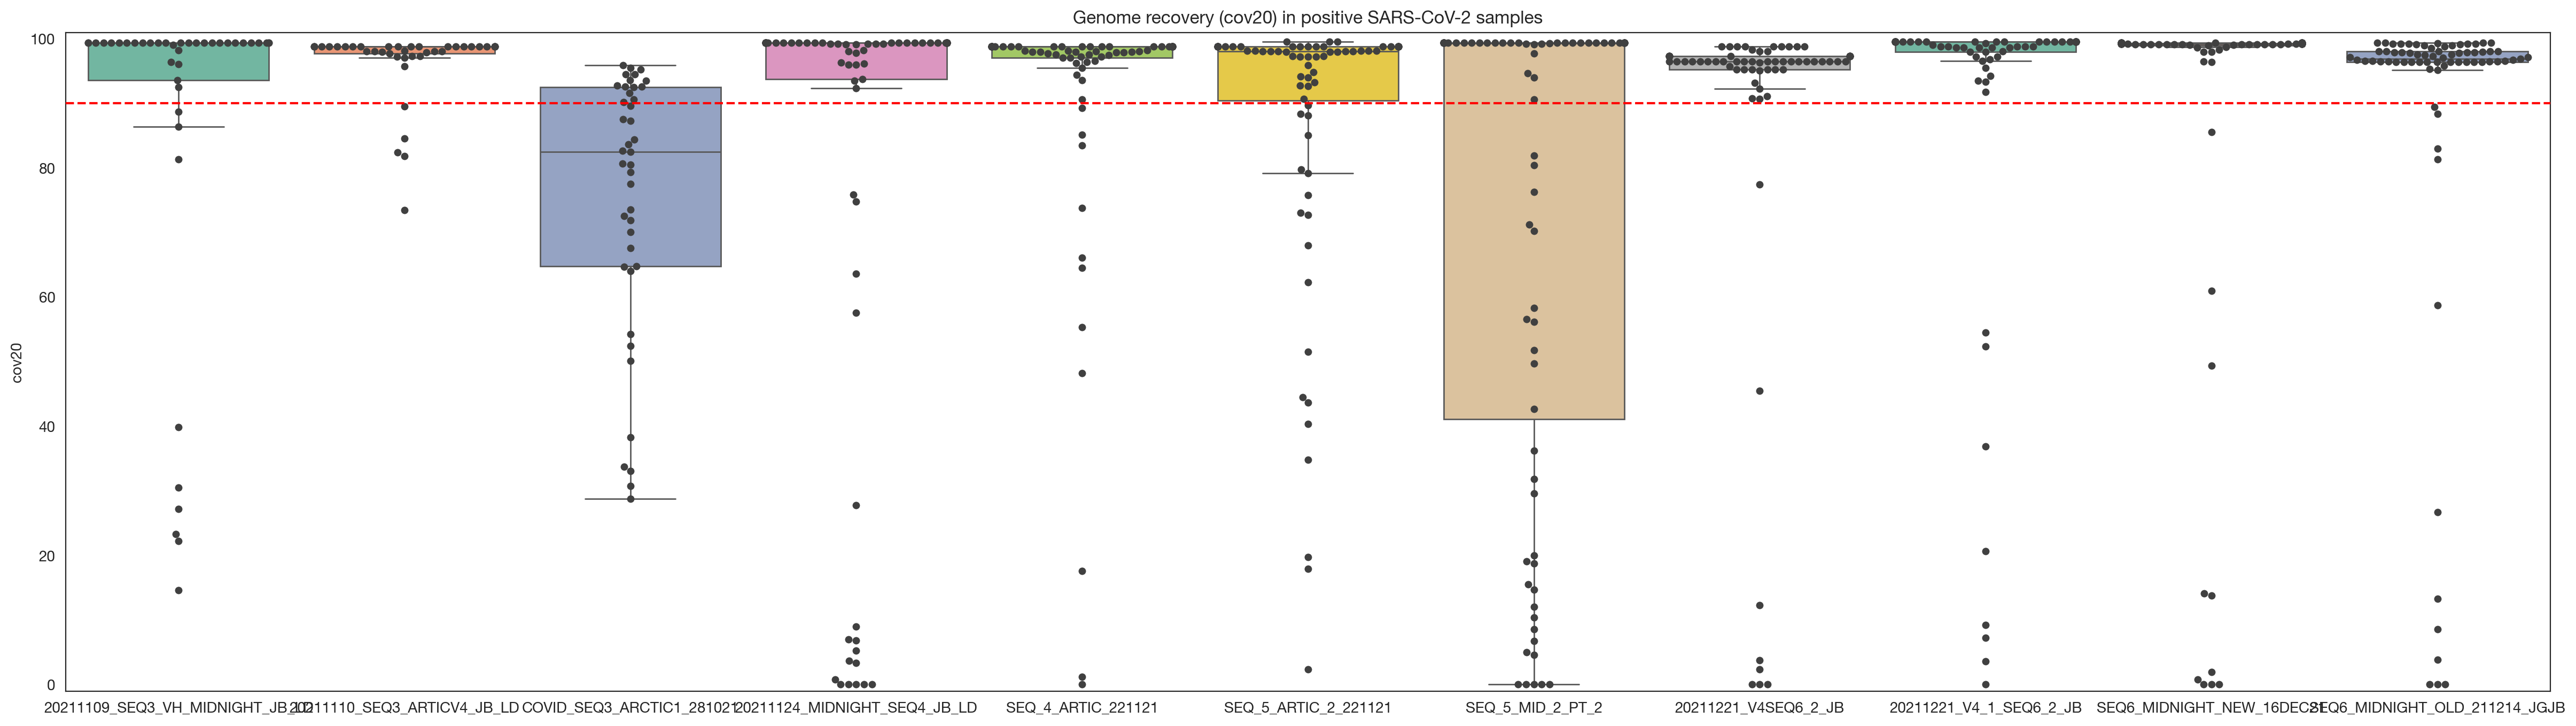

In [16]:
title = 'Genome recovery (cov20) in positive SARS-CoV-2 samples'

df = cov20_positive_df.copy()

plt.figure(figsize=(30,8))
ax1 = sns.boxplot(x='run', hue='run', y='cov20', data=df, palette='Set2', fliersize=0, legend=False)
ax1 = sns.swarmplot(dodge=True, x='run', y='cov20',  color='.25', data=df)
ax1.set(ylim=(-1,101), xlabel='', title=title)
ax1.axhline(90, linestyle='--', color='red', zorder=10)
# plt.savefig(f'{rp}/2021-10-28.cov20_boxes.pdf')

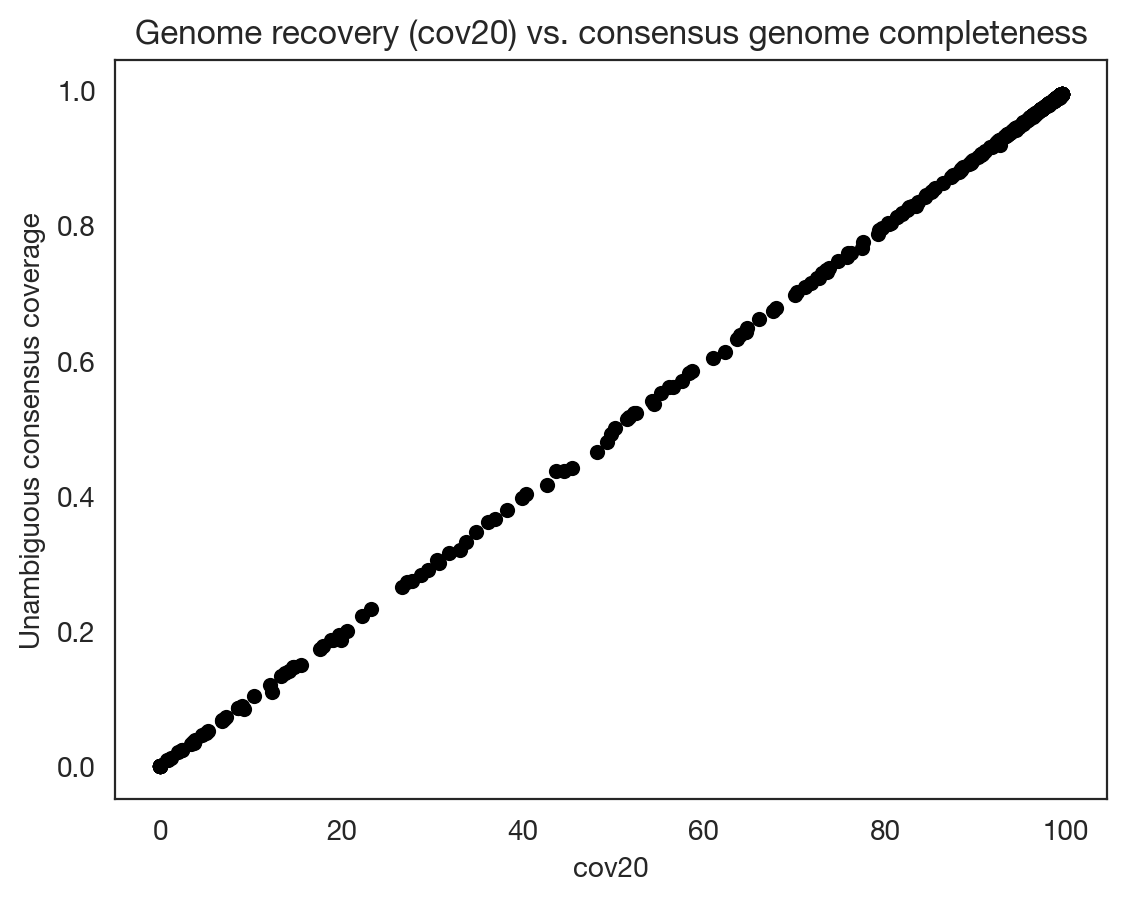

In [17]:
# ax = sns.scatterplot(x='cov20', y='acgt', data=cov20_positive_df, color='black', linewidth=0, s=15, alpha=0.5)
# ax = sns.lmplot(x='cov20', y='acgt', data=cov20_positive_df, scatter_kws={"s": 30, 'linewidth':0, 'color': 'black', 'alpha': 0.5})
ax = sns.scatterplot(x='cov20', y='acgt', data=cov20_positive_df, s=30, linewidth=0, color='black')
ax.set(title='Genome recovery (cov20) vs. consensus genome completeness', ylabel='Unambiguous consensus coverage')
plt.savefig(f'{results_dir}/sfig3.pdf')
plt.savefig(f'{results_dir}/sfig3.png', dpi=200)

In [18]:
df = delta_figure_df.copy()
delta_pair_wide = delta_paired_df.pivot(index='sample', columns='protocol', values='cov20')
delta_pair_summary = delta_paired_df.groupby('protocol')['cov20'].agg(n='size', mean='mean', median='median')
delta_pair_summary['n_cov20_ge_90'] = delta_paired_df.assign(success=lambda x: x['cov20'] >= 90).groupby('protocol')['success'].sum()
delta_pair_summary

,n,mean,median,n_cov20_ge_90
protocol,,,,
ARTIC v4,193,91.382447,98.187473,159
Midnight,193,79.307308,99.367956,138


In [19]:
from math import comb

artic_pass = delta_pair_wide['ARTIC v4'] >= 90
midnight_pass = delta_pair_wide['Midnight'] >= 90
artic_only = (artic_pass & ~midnight_pass).sum()
midnight_only = (midnight_pass & ~artic_pass).sum()
n_discordant = artic_only + midnight_only
p_mcnemar = min(1, 2 * sum(comb(n_discordant, k) for k in range(min(artic_only, midnight_only) + 1)) / 2**n_discordant)

pd.Series({'ARTIC v4 only': artic_only, 'Midnight only': midnight_only, 'exact McNemar p': p_mcnemar})

ARTIC v4 only      22.000000
Midnight only       1.000000
exact McNemar p     0.000006
dtype: float64

In [20]:
pd.Series({
    'Midnight': (delta_pair_wide['Midnight'] > delta_pair_wide['ARTIC v4']).sum(),
    'ARTIC v4': (delta_pair_wide['ARTIC v4'] > delta_pair_wide['Midnight']).sum(),
    'tie': (delta_pair_wide['Midnight'] == delta_pair_wide['ARTIC v4']).sum(),
}, name='higher_cov20')

Midnight    121
ARTIC v4     71
tie           1
Name: higher_cov20, dtype: int64

In [21]:
cov20_positive_df.query("plate_lineage == 'Delta' and plate != 4 and protocol == 'Midnight'").sort_values('cov20', ascending=False).drop_duplicates('sample').shape[0]

193

In [22]:
cov20_positive_df.query("plate_lineage == 'Delta' and protocol == 'ARTIC v3'").sort_values('cov20', ascending=False).cov20.median()

np.float64(82.513460187941)

In [23]:
# use smaller subset for apple to apple comparison
delta_samples_m = cov20_positive_df.query("plate_lineage == 'Delta' and plate != 4 and protocol == 'Midnight'").sort_values('cov20', ascending=False)['sample'].unique()
len(set(delta_samples_m) & set(cov20_positive_df.query("plate_lineage == 'Delta' and plate != 4 and protocol == 'ARTIC v4'").sort_values('cov20', ascending=False)['sample'].unique()))

193

In [24]:
cov20_positive_df.query("plate_lineage == 'Delta' and plate != 4 and protocol == 'ARTIC v4'").sort_values('cov20', ascending=False)[['sample']].nunique()

sample    193
dtype: int64

In [25]:
cov20_positive_df.query("plate_lineage == 'Delta' and cov20 >= 90 and plate != 4 and protocol == 'ARTIC v4' and sample in @delta_samples_m").sort_values('cov20', ascending=False).drop_duplicates('sample').shape[0]

159

In [26]:
(cov20_positive_df.query("plate_lineage == 'Delta' and cov20 >= 90 and plate != 4 and protocol == 'Midnight' and sample in @delta_samples_m").sort_values('cov20', ascending=False).drop_duplicates('sample').shape[0]
 /
cov20_positive_df.query("plate_lineage == 'Delta' and plate != 4 and protocol == 'Midnight'").sort_values('cov20', ascending=False).drop_duplicates('sample').shape[0])

0.7150259067357513

In [27]:
(cov20_positive_df.query("plate_lineage == 'Delta' and cov20 >= 90 and plate != 4 and protocol == 'ARTIC v4' and sample in @delta_samples_m").sort_values('cov20', ascending=False).drop_duplicates('sample').shape[0]
 /
cov20_positive_df.query("plate_lineage == 'Delta' and plate != 4 and protocol == 'ARTIC v4'").sort_values('cov20', ascending=False).drop_duplicates('sample').shape[0])

0.8238341968911918

In [28]:
cov20_positive_df.query("plate_lineage == 'Delta' and cov20 >= 90 and plate != 4 and (protocol == 'Midnight' or protocol == 'ARTIC v4') and sample in @delta_samples_m").groupby('protocol')['cov20'].mean()

protocol
ARTIC v4    98.057030
Midnight    98.803402
Name: cov20, dtype: float64

In [29]:
cov20_positive_df.query("plate == 1 and sample in @delta_samples_m").groupby('protocol')['cov20'].mean()

protocol
ARTIC v3    75.416285
ARTIC v4    96.426821
Midnight    87.159132
Name: cov20, dtype: float64

In [30]:
cov20_positive_df.query("plate == 1 and protocol").groupby('protocol')['cov20'].mean()

protocol
ARTIC v3    75.416285
ARTIC v4    96.426821
Midnight    87.159132
Name: cov20, dtype: float64

In [31]:
cov20_positive_df.query("plate == 1 and sample in @delta_samples_m").groupby('protocol')['cov20'].mean()

protocol
ARTIC v3    75.416285
ARTIC v4    96.426821
Midnight    87.159132
Name: cov20, dtype: float64

In [32]:
cov20_positive_df.query("plate_lineage == 'Delta' and cov20 >= 90 and plate != 4 and (protocol == 'Midnight' or protocol == 'ARTIC v4') and sample in @delta_samples_m").groupby('protocol')['cov20'].median()

protocol
ARTIC v4    98.826205
Midnight    99.367956
Name: cov20, dtype: float64

---

In [33]:
allowed_delta_lineages = {'AY.4', 'AY.4.2', 'AY.6', 'AY.42', 'AY.120', 'AY.43', 'AY.98', 'AY.5', 'B.1.617.2', 'AY.46.5', 'AY.9', 'AY.4.2.1', 'AY.39', 'AY.98.1', 'AY.34', 'AY.118', 'AY.122', 'AY.19', 'AY.52', 'AY.90'}
allowed_omicron_lineages = {'BA.1'}

biological_positive_samples = cov20_df.query("positive == True")['sample'].unique()
delta_samples = lineages_df.query("(plate == 1 or plate == 2 or plate == 3) and sample in @biological_positive_samples")['sample'].unique()
sample_set_4 = lineages_df.query("plate == 4 and sample in @biological_positive_samples")['sample'].unique()

delta_calls = lineages_df.loc[lineages_df['plate'].isin([1, 2, 3]) & lineages_df['sample'].isin(delta_samples) & lineages_df['lineage'].notna()]
sample_set_4_calls = lineages_df.loc[lineages_df['plate'].eq(4) & lineages_df['sample'].isin(sample_set_4) & lineages_df['lineage'].notna()]
non_delta_samples = (~delta_calls['lineage'].isin(allowed_delta_lineages)).sum()
non_omicron_samples = (~sample_set_4_calls['lineage'].isin(allowed_omicron_lineages)).sum()

pangolin_delta = delta_calls.query("lineage in @allowed_delta_lineages")['sample'].nunique()
pangolin_omicron = sample_set_4_calls.query("lineage in @allowed_omicron_lineages")['sample'].nunique()


d = {
    'all-delta': delta_samples.shape[0],
    'all-sample-set-4': sample_set_4.shape[0],
    'pangolin-delta': pangolin_delta,
    'pangolin-omicron': pangolin_omicron
}

pd.Series(d).rename('count').to_frame()

,count
all-delta,196
all-sample-set-4,71
pangolin-delta,179
pangolin-omicron,49


---

In [34]:
pearsonr(cov20_df.query("protocol == 'Midnight'")['cov20'], cov20_df.query("protocol == 'Midnight'")['acgt'])

PearsonRResult(statistic=np.float64(0.9999949196468869), pvalue=np.float64(0.0))

In [35]:
pearsonr(cov20_df.query("protocol == 'ARTIC v4'")['cov20'], cov20_df.query("protocol == 'ARTIC v4'")['acgt'])

PearsonRResult(statistic=np.float64(0.9999755814373531), pvalue=np.float64(0.0))

In [36]:
pearsonr(cov20_df['cov20'], cov20_df['acgt'])

PearsonRResult(statistic=np.float64(0.999986187092488), pvalue=np.float64(0.0))

/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 13.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 40.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 23.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 33.3% of the points cannot be placed; you may want to decrease the size of the markers or use s

[(-1.0, 101.0),
 Text(0.5, 104.72222222222219, 'ORF1 Ct'),
 Text(0.5, 1.0, 'ORF1 Ct vs. genome recovery (cov20) in positive SARS-CoV-2 samples by run')]

/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 13.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 25.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 7.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


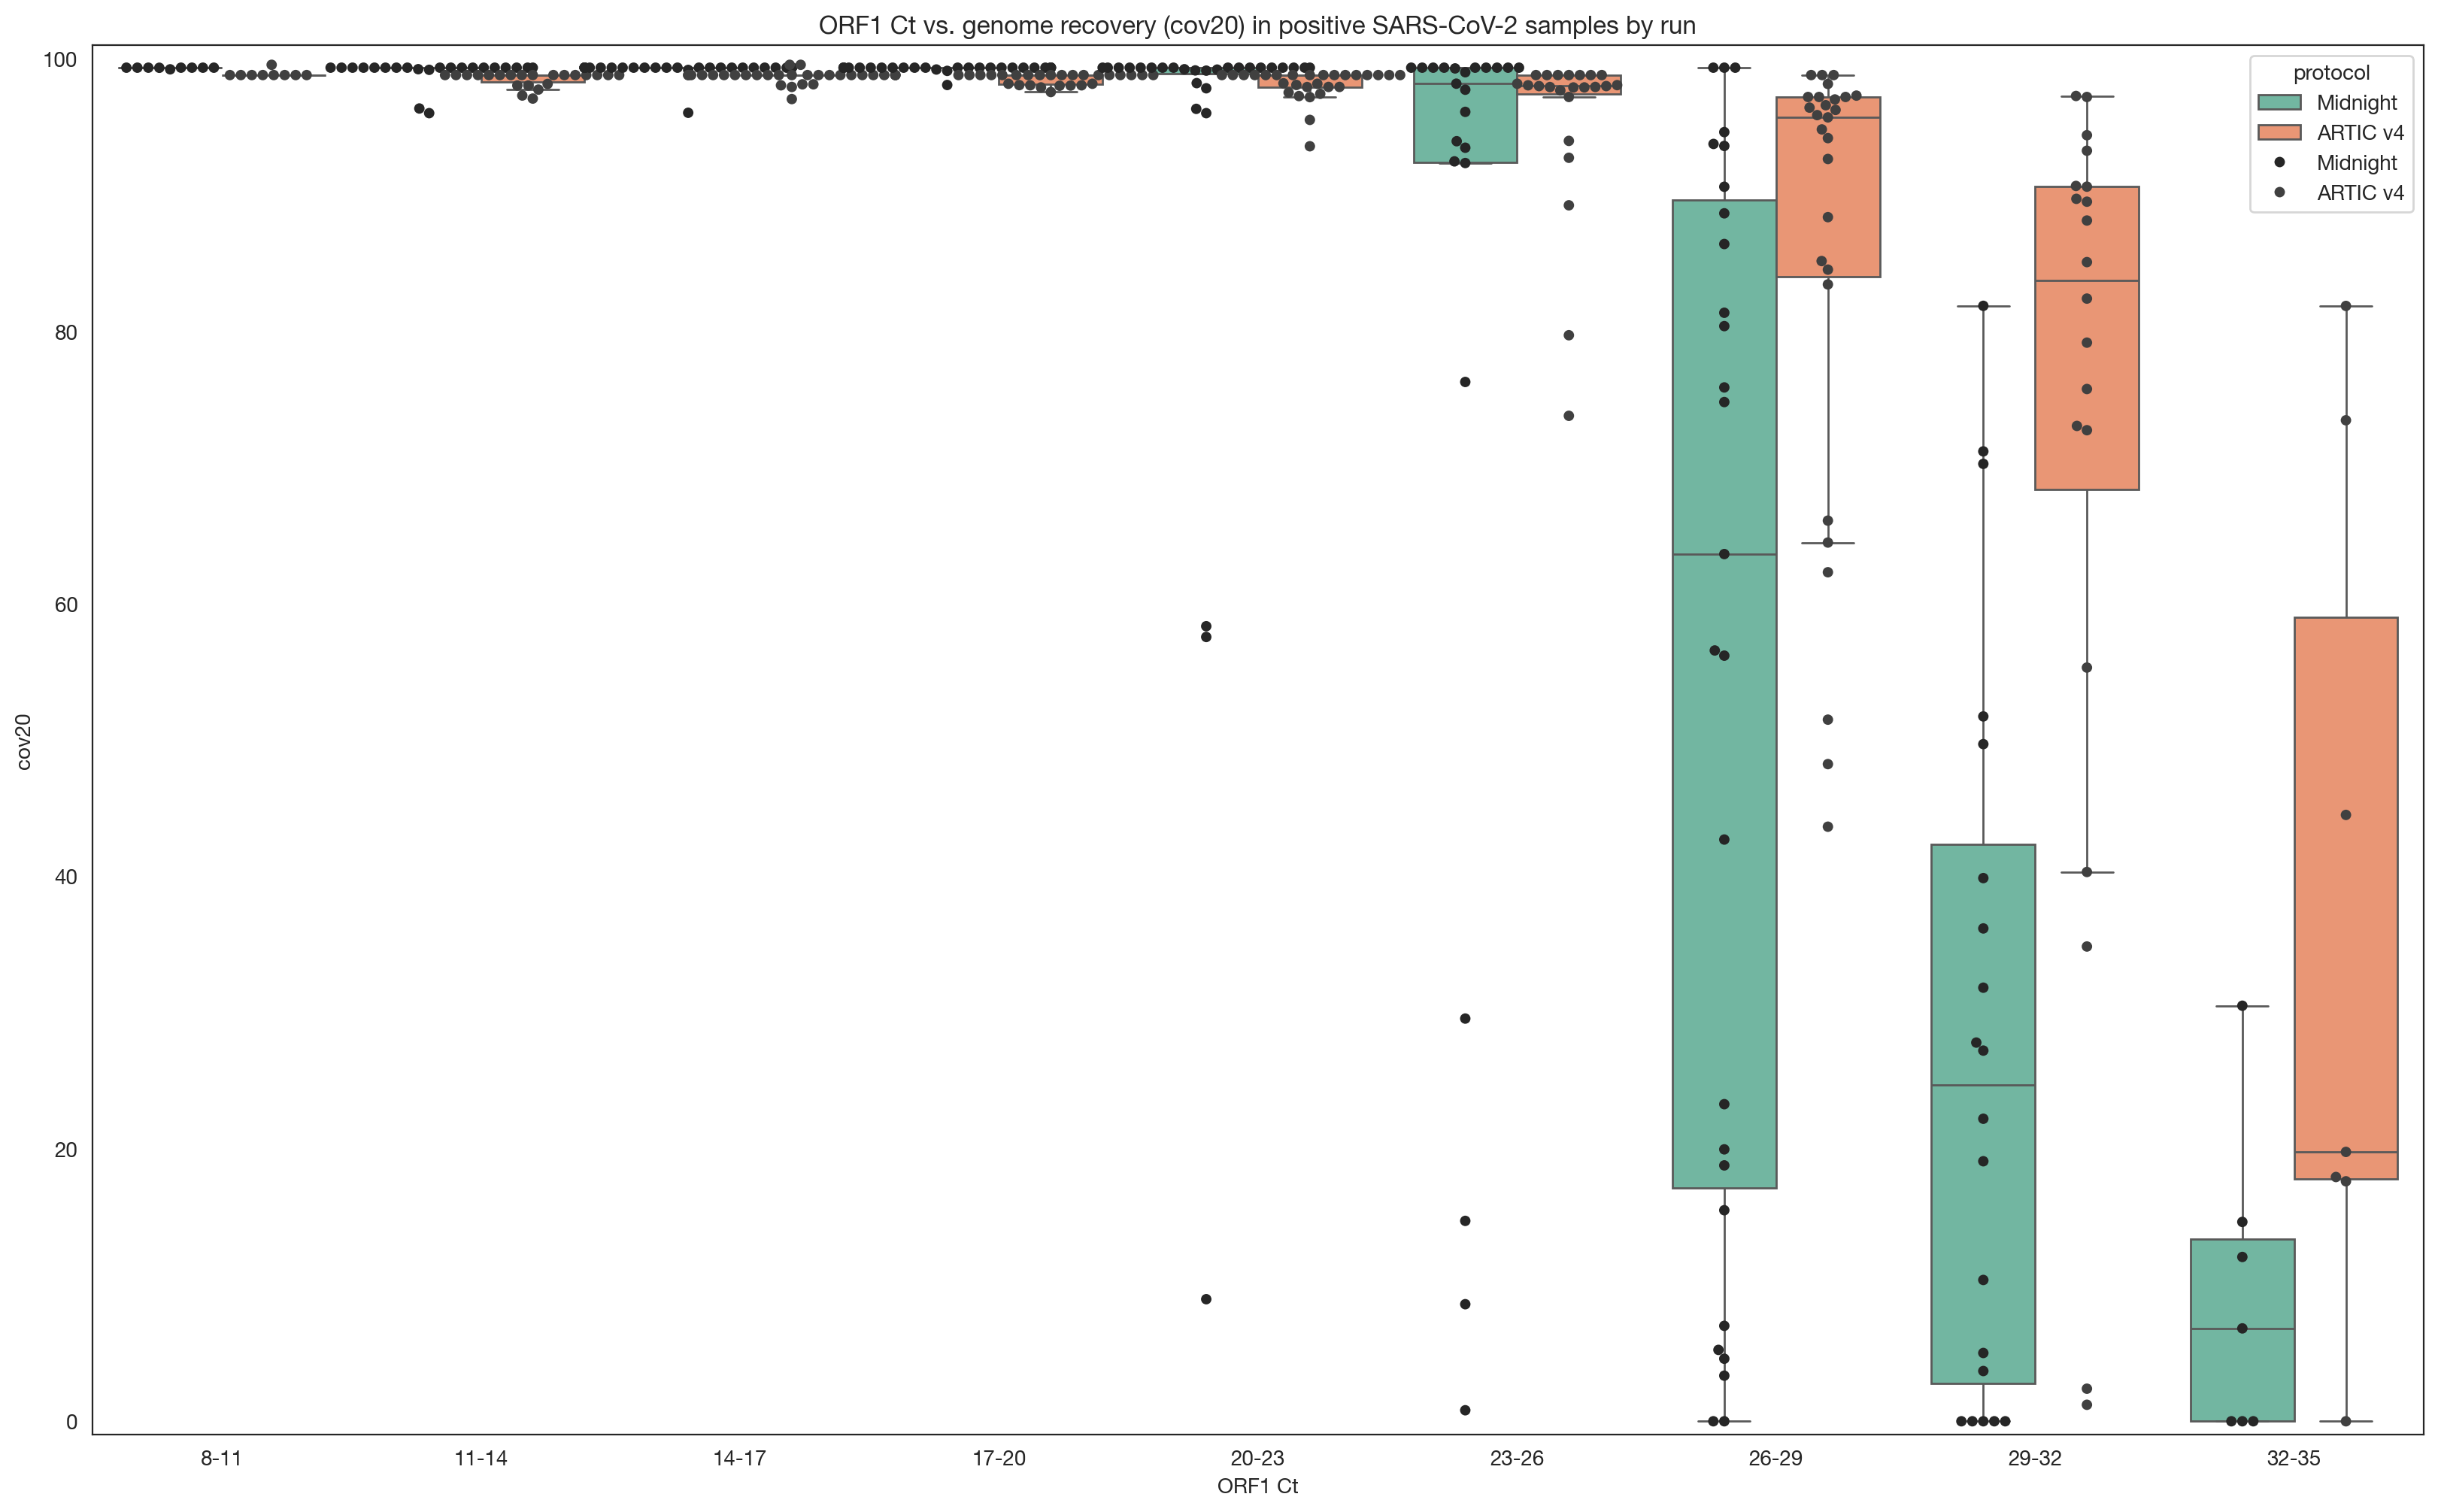

In [37]:
plt.figure(figsize=(20,12))
ax = sns.boxplot(x='binned', y='cov20', hue='protocol', data=df.query("protocol != 'ARTIC v3' and protocol != 'Midnight v2'"), palette=['#66c2a5','#fc8d62'], fliersize=0)
ax = sns.swarmplot(dodge=True, x='binned', y='cov20',  palette='dark:.25', hue='protocol', data=df.query("protocol != 'ARTIC v3' and protocol != 'Midnight v2'")) 
ax.set(ylim=(-1,101), xlabel='ORF1 Ct', title='ORF1 Ct vs. genome recovery (cov20) in positive SARS-CoV-2 samples by run')
# plt.savefig(f'{rp}/plate1.cov20_boxes.png')
# plt.legend(loc='lower left')

In [38]:
from statistics import NormalDist

def confidence_interval(data, confidence=0.95):
  dist = NormalDist.from_samples(data)
  z = NormalDist().inv_cdf((1 + confidence) / 2.)
  h = dist.stdev * z / ((len(data) - 1) ** .5)
  return dist.mean - h, dist.mean + h

confidence_interval([0,1,2,3,4,5,6,7,8,9])

(2.5219714493963252, 6.478028550603675)

In [39]:
df = delta_figure_df.copy()
df['ecdf'] = df.groupby('protocol')['cov20'].transform(lambda x: x.rank(method='first') / len(x))


c1 = alt.Chart(df).mark_circle(size=20, opacity=1).encode(
    alt.X('orf1_ct:Q', scale=alt.Scale(domain=(8, 37)), title='ORF1 cycle threshold'),
    alt.Y('cov20:Q', title='cov20 (%)'),
    alt.Color('protocol', scale=alt.Scale(scheme='set2'), sort=['Midnight', 'ARTIC v4', 'ARTIC v3']),
).properties(
    title='A) Cycle threshold vs. genome recovery (Delta lineage samples)',
    width=400,
    height=400,
)

c1 = c1 + c1.transform_loess('orf1_ct', 'cov20', bandwidth=0.4, groupby=['protocol']).mark_line(size=2, opacity=1)

c2 = alt.Chart(df
    ).mark_line(
        interpolate='step',
        size=2
    ).encode(
        alt.X('cov20:Q', title='cov20 (%)'),
        alt.Y('ecdf:Q', title='proportion'),
        alt.Color('protocol', scale=alt.Scale(scheme='set2'), sort=['Midnight', 'ARTIC v4', 'ARTIC v3'])
    ).properties(
        title='B) Empirical cumulative distribution of genome recovery (Delta lineage samples)',
        width=400,
        height=400,   
    )
fig1 = alt.hconcat(c1, c2)
fig1.save(f'{results_dir}/fig1.svg')
fig1.save(f'{results_dir}/fig1.png', scale_factor=4)

In [40]:
df = cov20_positive_df.query("plate_lineage == 'Omicron' and sample not in @excluded_samples").copy()

df['ecdf'] = df.groupby('protocol')['cov20'].transform(lambda x: x.rank(method='first') / len(x))

c4 = alt.Chart(df
    ).mark_line(
        interpolate='step',
        size=2,
        opacity=1.0
    ).encode(
        alt.X('cov20:Q', title='cov20 (%)'),
        alt.Y('ecdf:Q', title='proportion'),
        color=alt.Color('protocol', scale=alt.Scale(domain=['Midnight', 'Midnight v2', 'ARTIC v4', 'ARTIC v4.1'], range=['#66c2a5', '#e78ac3', '#fc8d62', '#a6d854'])),
    ).properties(
        title='B) Empirical cumulative distribution of genome recovery (SGTF-selected sample set 4)',
        width=400,
        height=400,   
    )

c3 = alt.Chart(df).mark_point(size=40, opacity=1, filled=True).encode(
    alt.X('orf1_ct:Q', scale=alt.Scale(domain=(8, 37)), title='ORF1 cycle threshold'),
    alt.Y('cov20:Q', title='cov20 (%)'),
    alt.Color('protocol', scale=alt.Scale(domain=['Midnight', 'Midnight v2', 'ARTIC v4', 'ARTIC v4.1'], range=['#66c2a5', '#e78ac3', '#fc8d62', '#a6d854'])),
    alt.Shape('protocol', scale=alt.Scale(domain=['Midnight', 'Midnight v2', 'ARTIC v4', 'ARTIC v4.1'])),
).properties(
    title='A) Cycle threshold vs. genome recovery (SGTF-selected sample set 4)',
    width=400,
    height=400,
)

# c3 = c3 + c3.transform_loess('orf1_ct', 'cov20', bandwidth=0.3, groupby=['protocol']).mark_line(size=2, opacity=1)

alt.hconcat(c3, c4)
# alt.hconcat(c3, c4).save(f'{rp}/f4.svg')

alt.HConcatChart(...)

In [41]:
df = cov20_positive_df.query("plate_lineage == 'Omicron' and sample not in @excluded_samples").copy()

df['ecdf'] = df.groupby('protocol')['cov20'].transform(lambda x: x.rank(method='first') / len(x))

c4 = alt.Chart(df
    ).mark_line(
        interpolate='step',
        size=2,
        opacity=1.0
    ).encode(
        alt.X('cov20:Q', title='cov20 (%)'),
        alt.Y('ecdf:Q', title='proportion'),
        color=alt.Color('protocol', scale=alt.Scale(domain=['Midnight', 'Midnight v2', 'ARTIC v4', 'ARTIC v4.1'], range=['#66c2a5', '#e78ac3', '#fc8d62', '#a6d854'])),
    ).properties(
        title='B) Empirical cumulative distribution of genome recovery (SGTF-selected sample set 4)',
        width=400,
        height=400,   
    )

c3 = alt.Chart(df).mark_point(size=40, opacity=1, filled=True).encode(
    alt.X('orf1_ct:Q', scale=alt.Scale(domain=(8, 37)), title='ORF1 cycle threshold'),
    alt.Y('cov20:Q', title='cov20 (%)'),
    alt.Color('protocol', scale=alt.Scale(domain=['Midnight', 'Midnight v2', 'ARTIC v4', 'ARTIC v4.1'], range=['#66c2a5', '#e78ac3', '#fc8d62', '#a6d854'])),
    alt.Shape('protocol', scale=alt.Scale(domain=['Midnight', 'Midnight v2', 'ARTIC v4', 'ARTIC v4.1'])),
).properties(
    title='A) Cycle threshold vs. genome recovery (SGTF-selected sample set 4)',
    width=400,
    height=400,
)

# c3 = c3 + c3.transform_loess('orf1_ct', 'cov20', bandwidth=0.3, groupby=['protocol']).mark_line(size=2, opacity=1)

alt.hconcat(c3, c4)
fig3 = alt.hconcat(c3, c4)
fig3.save(f'{results_dir}/fig3.svg')
fig3.save(f'{results_dir}/fig3.png', scale_factor=4)

In [42]:
cov20_positive_df.query("plate == 4 and cov20 >= 99").groupby('protocol').count()['sample']

protocol
ARTIC v4.1     41
Midnight       13
Midnight v2    53
Name: sample, dtype: int64

In [43]:
cov20_positive_df.query("plate == 4 and protocol == 'ARTIC v4.1' and cov20 >= 99")['sample'].nunique()

41

In [44]:
# x_df = pd.DataFrame([
#     {'sample': 1, 'condition': 'a', 'score': 0.97},
#     {'sample': 1, 'condition': 'b', 'score': 0.96},
#     {'sample': 2, 'condition': 'a', 'score': 0.99},
#     {'sample': 2, 'condition': 'b', 'score': 0.95},
# ])

# samples_winners = {}
# for s in x_df['sample'].unique():
#     q = x_df.query(f"sample == {s}").sort_values('score').head(1).to_dict('records')[0]
#     samples_winners[q['sample']] = q['condition']
# samples_winners

In [45]:
# sns.lmplot(x='orf1_ct', y='cov20', hue='protocol', palette='Set2', hue_order=['Midnight', 'ARTIC v4'], lowess=True,
#             data=df.sort_values('binned', ascending=False))

In [46]:
# sns.relplot(kind='line', x='binned', y='cov20', hue='protocol', style='protocol', col='plate', linewidth=0.3, palette='Set2', hue_order=['Midnight', 'ARTIC v4'], markers=True,
#             data=df.sort_values('binned', ascending=False))

/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 39.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 19.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 38.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 18.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


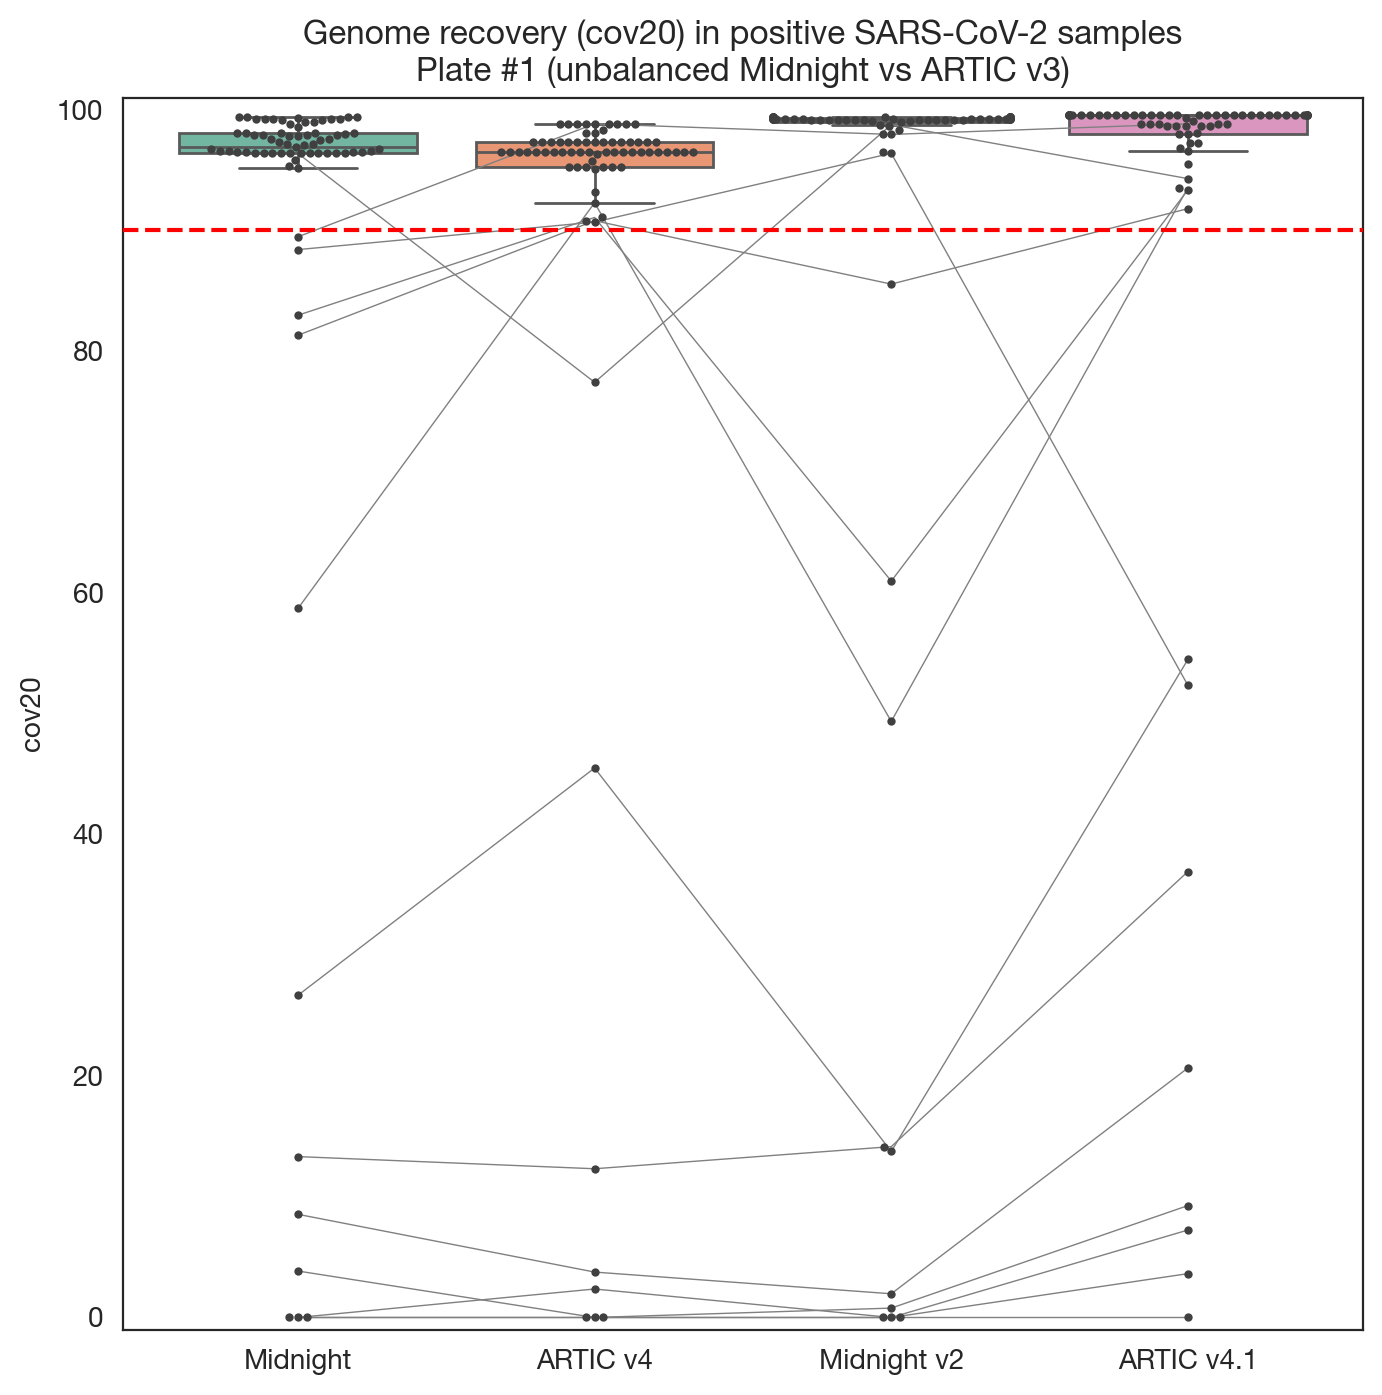

In [47]:
title = 'Genome recovery (cov20) in positive SARS-CoV-2 samples\nPlate #1 (unbalanced Midnight vs ARTIC v3)'

protocol_order = ['Midnight', 'ARTIC v4', 'Midnight v2', 'ARTIC v4.1']
df = cov20_positive_df.copy()

plt.figure(figsize=(8,8))
ax1 = sns.boxplot(x='protocol', hue='protocol', y='cov20', data=df.query("plate_lineage == 'Omicron'"), order=protocol_order, hue_order=protocol_order, palette='Set2', fliersize=0, legend=False)
ax1 = sns.swarmplot(dodge=True, x='protocol', y='cov20', s=3, color='.25', order=protocol_order, data=df.query("plate_lineage == 'Omicron'"))
dfx_low_cov_samples = df.query("cov20 < 90")['sample'].unique()
dfx = df.query("plate_lineage == 'Omicron' and sample in @dfx_low_cov_samples")
ax1 = sns.lineplot(x='protocol', y='cov20', hue='sample', linewidth=0.5, ax=ax1,
                   data=dfx.sort_values('protocol_order'),
                   palette=['grey' for i in range(dfx['sample'].nunique())],
                   legend=False)
ax1.set(ylim=(-1,101), xlabel='', title=title)
ax1.axhline(90, linestyle='--', color='red', zorder=10)
# plt.savefig(f'{rp}/2021-10-28.cov20_boxes.pdf')

In [48]:
cov20_positive_df

,plate,run,barcode,sample,positive,analysis_eligible,plate_lineage,cov20,orf1_ct,protocol,acgt,scorpio_call,protocol_order,binned
0,1,20211109_SEQ3_VH_MIDNIGHT_JB_LD,01,7c19a27c938c0d9f,True,True,Delta,99.367956,22.193434,Midnight,0.993,Delta (AY.4.2-like),0,20-23
1,1,20211109_SEQ3_VH_MIDNIGHT_JB_LD,02,43130ae7a64cacdb,True,True,Delta,99.367956,22.770636,Midnight,0.993,Delta (AY.4-like),0,20-23
2,1,20211109_SEQ3_VH_MIDNIGHT_JB_LD,03,1f8c44e88c2980e7,True,True,Delta,92.489048,25.000000,Midnight,0.924,Delta (AY.4-like),0,23-26
3,1,20211109_SEQ3_VH_MIDNIGHT_JB_LD,04,15cbf61c81896884,True,True,Delta,99.367956,14.000000,Midnight,0.993,Delta (AY.4-like),0,11-14
4,1,20211109_SEQ3_VH_MIDNIGHT_JB_LD,05,cea7364d690385d3,True,True,Delta,99.367956,20.000000,Midnight,0.993,Delta (AY.4-like),0,17-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
873,4,SEQ6_MIDNIGHT_OLD_211214_JGJB,76,51ff9752d75817b6,True,True,Omicron,99.367956,14.000000,Midnight,0.993,Delta (B.1.617.2-like),0,11-14
874,4,SEQ6_MIDNIGHT_OLD_211214_JGJB,77,204f88d9ba2e3fe7,True,True,Omicron,99.127178,19.000000,Midnight,0.991,Delta (AY.4-like),0,17-20
875,4,SEQ6_MIDNIGHT_OLD_211214_JGJB,78,1f787f7b224c64ca,True,True,Omicron,99.187373,21.000000,Midnight,0.991,Delta (AY.4-like),0,20-23
876,4,SEQ6_MIDNIGHT_OLD_211214_JGJB,79,a236e59f60a3d460,True,True,Omicron,99.367956,26.000000,Midnight,0.993,Delta (AY.4-like),0,23-26


[Text(0.5, 1.0, 'cov20 empirical cumulative distribution by protocol')]

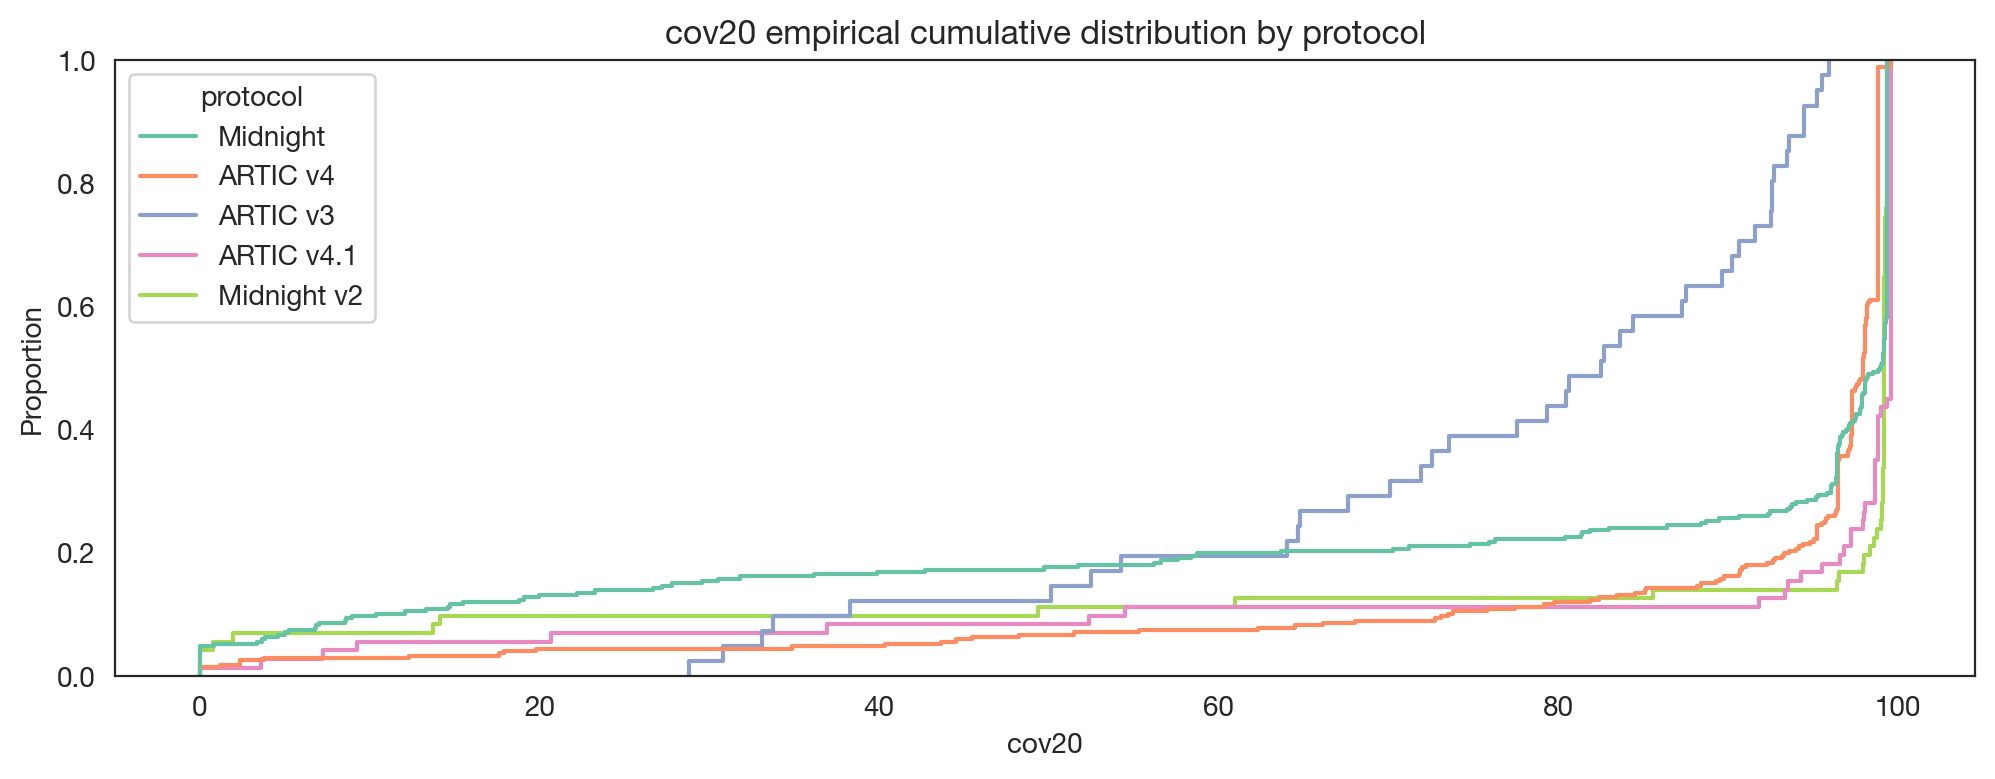

In [49]:
plt.figure(figsize=(12,4))
ax = sns.ecdfplot(df, x='cov20', hue='protocol', palette='Set2')
ax.set(title='cov20 empirical cumulative distribution by protocol')

/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 6.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 32.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 19.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/var/folders/2h/nwzvqfmx3hqcr8vgn6zq1pxc0000gn/T/ipykernel_49145/1179498378.py:47: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  ax[2] = sns.boxplot(x='run', hue='run',

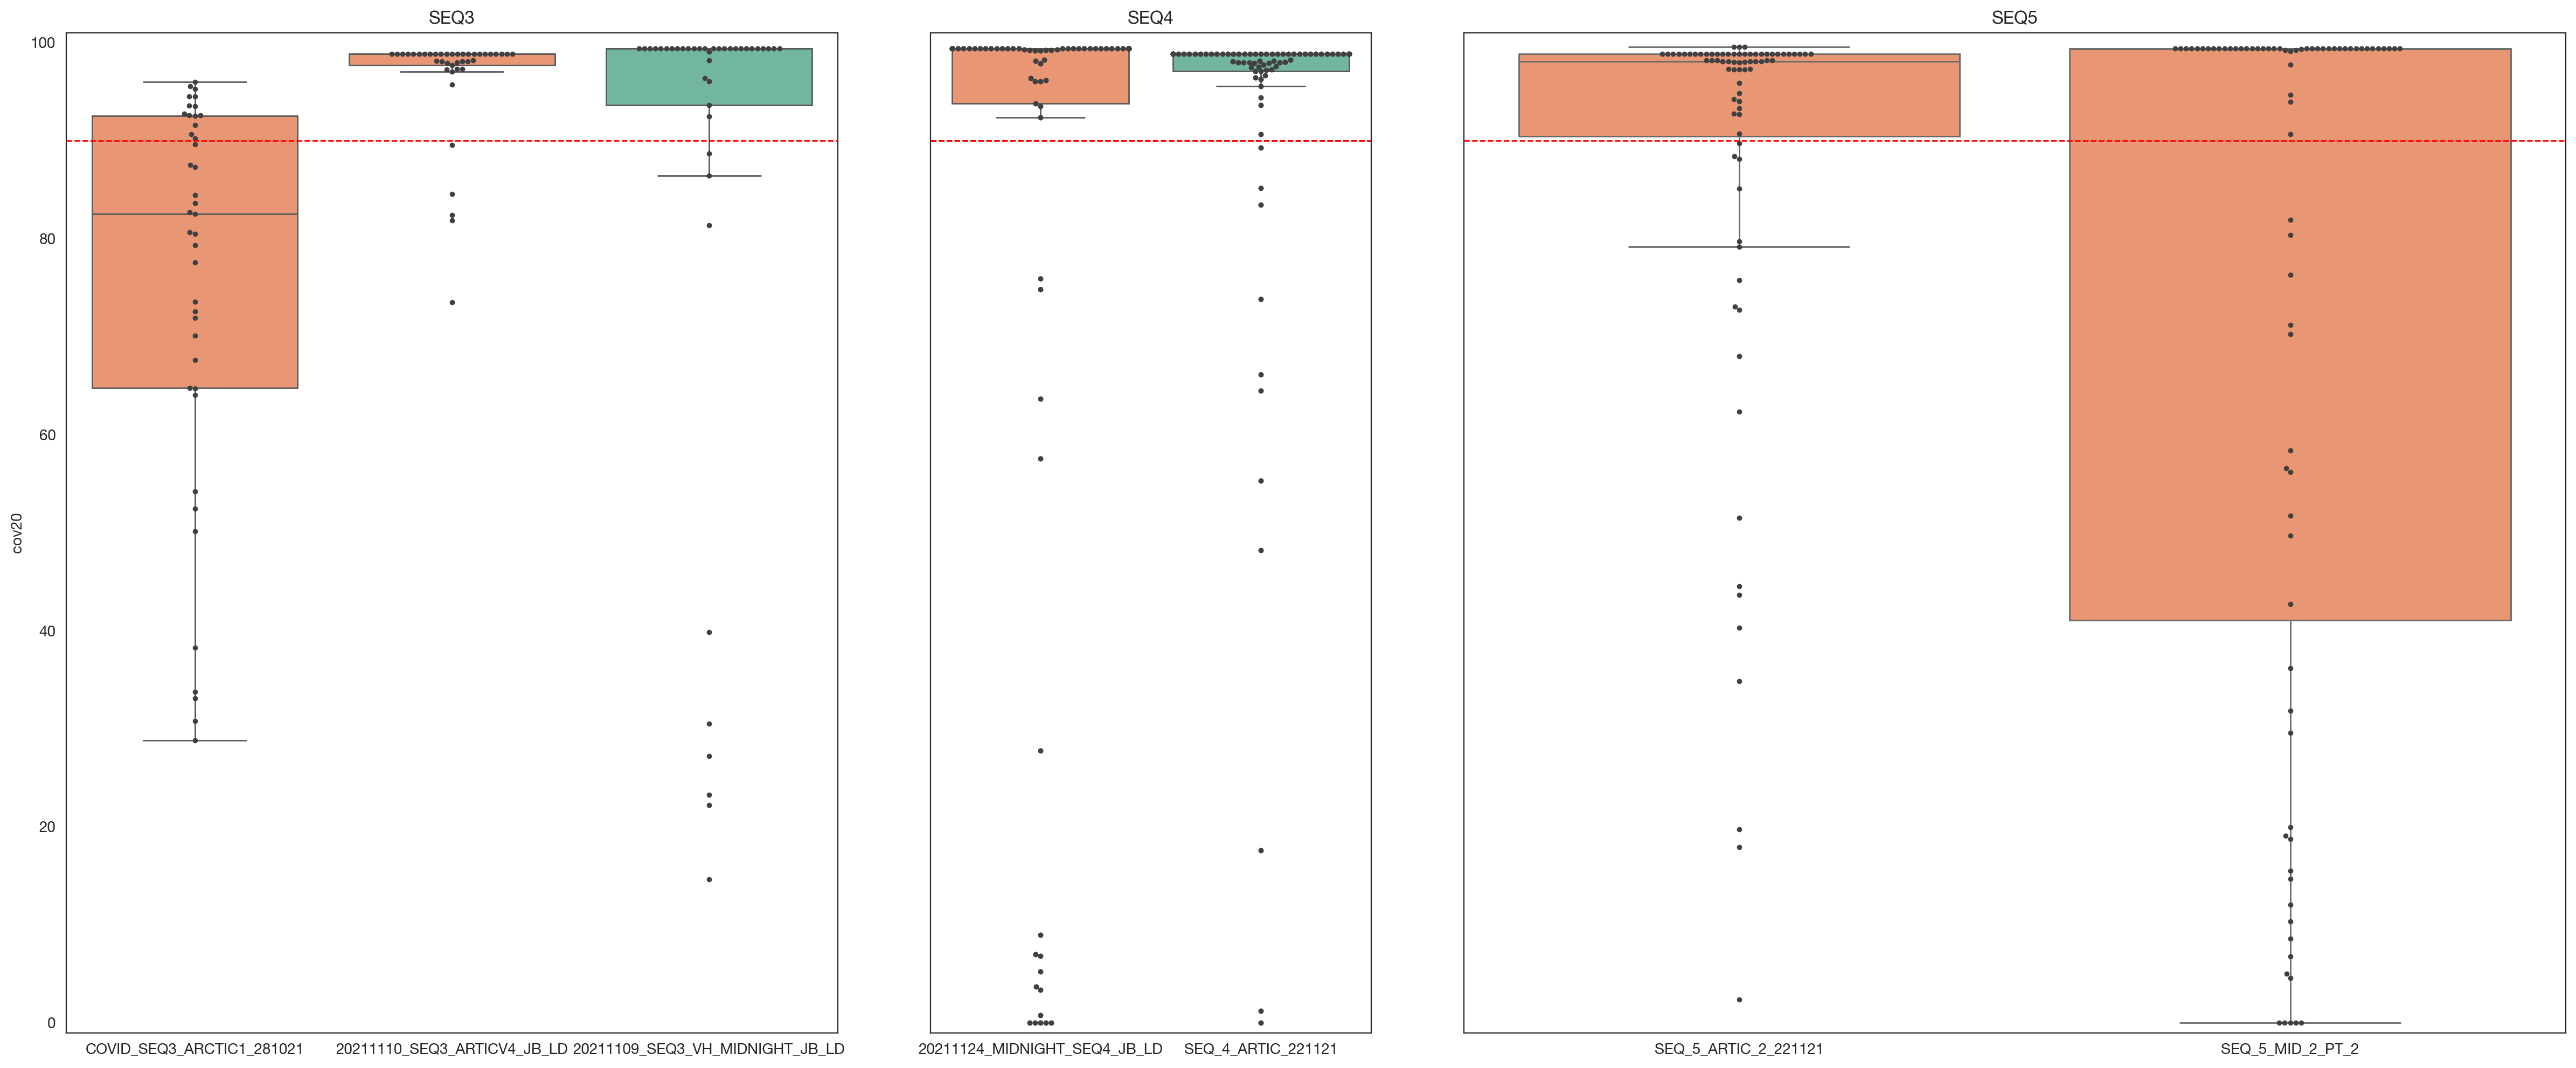

In [50]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(24,10), gridspec_kw={'width_ratios': [3.5, 2, 5]}, sharey=True)

sns.set_style('whitegrid')
run_order = ['COVID_SEQ3_ARCTIC1_281021', '20211110_SEQ3_ARTICV4_JB_LD', '20211109_SEQ3_VH_MIDNIGHT_JB_LD']
protocol_order = ['ARTIC v3', 'ARTIC v4', 'Midnight']
title = 'SEQ3'
df = cov20_positive_df.query("run in @run_order").copy()

ax[0] = sns.boxplot(x='run', hue='run', y='cov20', data=df, order=run_order, hue_order=run_order, palette=['#fc8d62', '#fc8d62', '#66c2a5'], fliersize=0, ax=ax[0], legend=False)
ax[0] = sns.swarmplot(dodge=True, x='run', y='cov20',  color='.25', data=df, order=run_order, s=3.5, ax=ax[0])
# ax[0] = sns.lineplot(x='run', y='cov20', hue='sample', linewidth=0.3, ax=ax[0],
#                   data=df.sort_values('run', ascending=False),
#                   palette=['grey' for i in range(df['sample'].nunique())],
#                   legend=False)
ax[0].set(ylim=(-1,101), xlabel='', title=title)
ax[0].axhline(90, linestyle='--', linewidth=1, color='red', zorder=10)


run_order = ['20211124_MIDNIGHT_SEQ4_JB_LD', 'SEQ_4_ARTIC_221121']
protocol_order = ['ARTIC v4', 'Midnight']
title = 'SEQ4'
df = cov20_positive_df.query("run in @run_order").copy()

ax[1] = sns.swarmplot(dodge=True, x='run', y='cov20',  color='.25', data=df, order=run_order, s=3.5, ax=ax[1])
# ax[1] = sns.lineplot(x='protocol', y='cov20', hue='sample', linewidth=0.3, ax=ax[1],
#                   data=df.sort_values('run', ascending=False),
#                   palette=['grey' for i in range(df['sample'].nunique())],
#                   legend=False)
ax[1].set(ylim=(-1,101), xlabel='', title=title)
ax[1].axhline(90, linestyle='--', linewidth=1, color='red', zorder=10)

ax[1] = sns.boxplot(x='run', hue='run', y='cov20', data=df, order=run_order, hue_order=run_order, palette=['#fc8d62', '#66c2a5'], fliersize=0, ax=ax[1], legend=False)
ax[1] = sns.swarmplot(dodge=True, x='run', y='cov20',  color='.25', data=df, order=run_order, s=3.5, ax=ax[1])
# ax[1] = sns.lineplot(x='protocol', y='cov20', hue='sample', linewidth=0.3, ax=ax[1],
#                   data=df.sort_values('run', ascending=False),
#                   palette=['grey' for i in range(df['sample'].nunique())],
#                   legend=False)
ax[1].set(ylim=(-1,101), xlabel='', title=title)
ax[1].axhline(90, linestyle='--', linewidth=1, color='red', zorder=10)


run_order = ['SEQ_5_ARTIC_2_221121', 'SEQ_5_MID_2_PT_2']
protocol_order = ['ARTIC v4', 'Midnight']
title = 'SEQ5'
df = cov20_positive_df.query("run in @run_order").copy()

ax[2] = sns.boxplot(x='run', hue='run', y='cov20', data=df, order=run_order, hue_order=run_order, palette=['#fc8d62', '#fc8d62', '#66c2a5', '#66c2a5', '#66c2a5'], fliersize=0, ax=ax[2], legend=False)
ax[2] = sns.swarmplot(dodge=True, x='run', y='cov20',  color='.25', data=df, order=run_order, s=3.5, ax=ax[2])
# ax[2] = sns.lineplot(x='run', y='cov20', hue='sample', linewidth=0.3, ax=ax[2],
#                   data=df.sort_values('run', ascending=True),
#                   palette=['grey' for i in range(df['sample'].nunique())],
#                   legend=False)
ax[2].set(ylim=(-1,101), xlabel='', title=title)
ax[2].axhline(90, linestyle='--', linewidth=1, color='red', zorder=10)

# fig.suptitle('Fig. 1: SARS-CoV-2 genome recovery (cov20) by protocol (All SEQ3, SEQ4, SEQ5)')
fig.tight_layout()
# fig.savefig(f'{rp}/eccmid.f1.png')

/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 9.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 9.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 23.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 35.1% of the points cannot be placed; you may want to decrease the size of the markers or use str

/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 35.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 11.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 11.7% of the points cannot be placed; you may want to decrease the size of the markers or use s

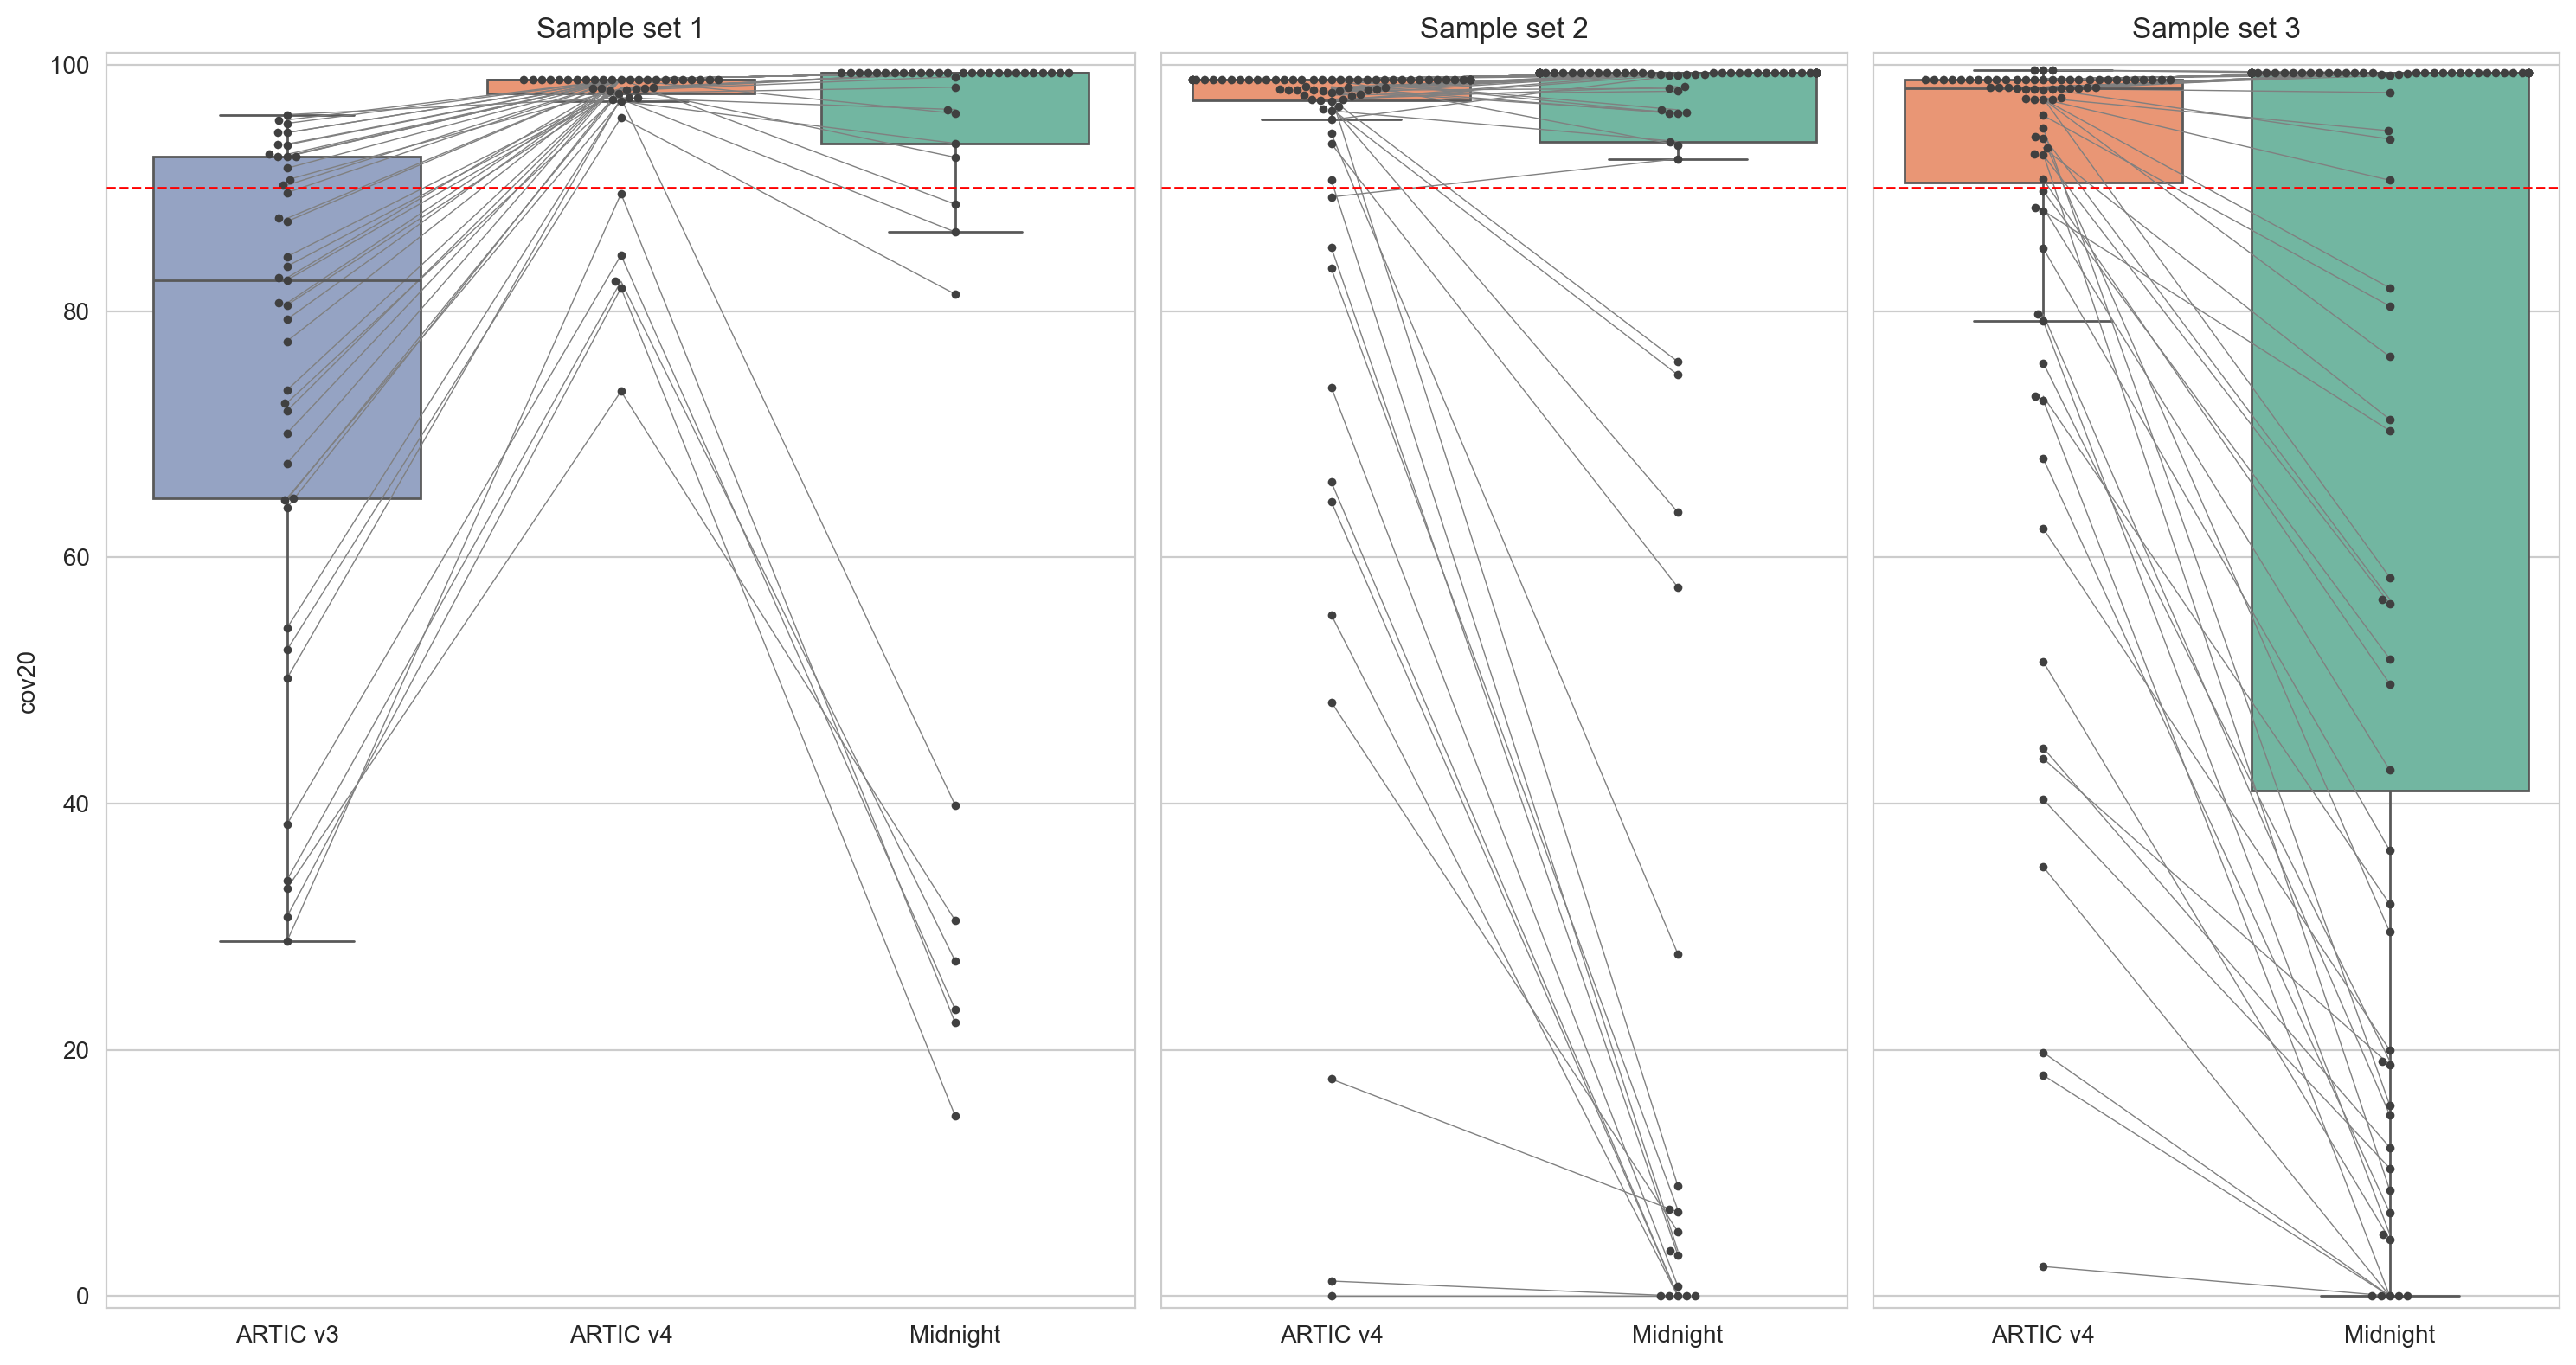

In [51]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15,8), gridspec_kw={'width_ratios': [1.5, 1, 1]}, sharey=True)

sns.set_style('whitegrid')
run_order = ['COVID_SEQ3_ARCTIC1_281021', '20211110_SEQ3_ARTICV4_JB_LD', '20211109_SEQ3_VH_MIDNIGHT_JB_LD']
protocol_order = ['ARTIC v3', 'ARTIC v4', 'Midnight']
title = 'Sample set 1'
df = cov20_positive_df.query("run in @run_order and sample not in @excluded_samples").copy()

ax[0] = sns.boxplot(x='protocol', hue='protocol', y='cov20', data=df, order=protocol_order, hue_order=protocol_order, palette=['#8da0cb', '#fc8d62', '#66c2a5'], fliersize=0, ax=ax[0], legend=False)
ax[0] = sns.swarmplot(dodge=True, x='protocol', y='cov20',  color='.25', data=df, order=protocol_order, s=3.5, ax=ax[0])
ax[0] = sns.lineplot(x='protocol', y='cov20', hue='sample', linewidth=0.5, ax=ax[0],
                  data=df.sort_values('run', ascending=False),
                  palette=['grey' for i in range(df['sample'].nunique())],
                  legend=False)
ax[0].set(ylim=(-1,101), xlabel='', title=title)
ax[0].axhline(90, linestyle='--', linewidth=1, color='red', zorder=10)


run_order = ['20211124_MIDNIGHT_SEQ4_JB_LD', 'SEQ_4_ARTIC_221121']
protocol_order = ['ARTIC v4', 'Midnight']
title = 'Sample set 2'
df = cov20_positive_df.query("run in @run_order and sample not in @excluded_samples").copy()

ax[1] = sns.boxplot(x='protocol', hue='protocol', y='cov20', data=df, order=protocol_order, hue_order=protocol_order, palette=['#fc8d62', '#66c2a5'], fliersize=0, ax=ax[1], legend=False)
ax[1] = sns.swarmplot(dodge=True, x='protocol', y='cov20',  color='.25', data=df, order=protocol_order, s=3.5, ax=ax[1])
ax[1] = sns.lineplot(x='protocol', y='cov20', hue='sample', linewidth=0.5, ax=ax[1],
                  data=df.sort_values('run', ascending=False),
                  palette=['grey' for i in range(df['sample'].nunique())],
                  legend=False)
ax[1].set(ylim=(-1,101), xlabel='', title=title)
ax[1].axhline(90, linestyle='--', linewidth=1, color='red', zorder=10)


run_order = ['SEQ_5_ARTIC_2_221121', 'SEQ_5_MID_2_PT_2']
protocol_order = ['ARTIC v4', 'Midnight']
title = 'Sample set 3'
df = cov20_positive_df.query("run in @run_order and sample not in @excluded_samples").copy()

ax[2] = sns.boxplot(x='protocol', hue='protocol', y='cov20', data=df, order=protocol_order, hue_order=protocol_order, palette=['#fc8d62', '#66c2a5'], fliersize=0, ax=ax[2], legend=False)
ax[2] = sns.swarmplot(dodge=True, x='protocol', y='cov20',  color='.25', data=df, order=protocol_order, s=3.5, ax=ax[2])
ax[2] = sns.lineplot(x='protocol', y='cov20', hue='sample', linewidth=0.5, ax=ax[2],
                  data=df.sort_values('run', ascending=True),
                  palette=['grey' for i in range(df['sample'].nunique())],
                  legend=False)
ax[2].set(ylim=(-1,101), xlabel='', title=title)
ax[2].axhline(90, linestyle='--', linewidth=1, color='red', zorder=10)

# fig.suptitle('Fig. 1: SARS-CoV-2 genome recovery (cov20) by protocol')
# fig.supxlabel('Genome recovered at or above depth 20 in head-to-head sequencing of 195 positive SARS-CoV-2 clinical samples of Delta lineage.\nRed line correspond to a widely used lower bound on genome recovery for lineage assignment (90%).')
fig.tight_layout()
fig.savefig(f'{results_dir}/eccmid.f1.png')

In [52]:
cov20_positive_df.query("plate == 1 and protocol == 'ARTIC v3'  and cov20 >= 90").shape[0]

14

In [53]:
cov20_df.query("(sample == 'NEG2' or sample == 'NEG1' or sample == 'NEG' or orf1_ct == 0 and sample != 'WHO') and cov20 > 0").sort_values('cov20', ascending=False).head(20)

,plate,run,barcode,sample,positive,analysis_eligible,plate_lineage,cov20,orf1_ct,protocol,acgt,scorpio_call,protocol_order,binned
68,1,20211110_SEQ3_ARTICV4_JB_LD,39,c32c5c5524a7ca65,False,False,Delta,58.445641,0.0,ARTIC v4,0.583,NaN,1,NaN
529,4,20211221_V4SEQ6_2_JB,10,72cbeb4f37a16375,False,False,Omicron,37.668461,0.0,ARTIC v4,0.341,NaN,1,NaN
778,4,SEQ6_MIDNIGHT_NEW_16DEC21,73,72cbeb4f37a16375,False,False,Omicron,19.279002,0.0,Midnight v2,0.193,NaN,3,NaN
623,4,20211221_V4_1_SEQ6_2_JB,10,72cbeb4f37a16375,False,False,Omicron,18.198843,0.0,ARTIC v4.1,0.175,NaN,4,NaN
870,4,SEQ6_MIDNIGHT_OLD_211214_JGJB,73,72cbeb4f37a16375,False,False,Omicron,9.203090,0.0,Midnight,0.089,NaN,0,NaN
622,4,20211221_V4_1_SEQ6_2_JB,09,e5006092451e9e99,False,False,Omicron,7.199946,0.0,ARTIC v4.1,0.072,NaN,4,NaN
654,4,20211221_V4_1_SEQ6_2_JB,43,01aec1670f3364b6,False,False,Omicron,2.190416,0.0,ARTIC v4.1,0.022,NaN,4,NaN
136,1,COVID_SEQ3_ARCTIC1_281021,77,cd7ec355a02b2d6d,False,False,Delta,1.708859,0.0,ARTIC v3,0.011,NaN,2,NaN
642,4,20211221_V4_1_SEQ6_2_JB,31,4ee340f4fa68c616,False,False,Omicron,1.223957,0.0,ARTIC v4.1,0.012,NaN,4,NaN
417,3,SEQ_5_ARTIC_2_221121,90,9d51c3cc0f0cb0be,False,False,Delta,1.197204,0.0,ARTIC v4,0.012,NaN,1,NaN


/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 9.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 9.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 35.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 23.4% of the points cannot be placed; you may want to decrease the size of the markers or use str

/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 11.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 9.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 35.1% of the points cannot be placed; you may want to decrease the size of the markers or use st

/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 45.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 22.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 9.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 11.8% of the points cannot be placed; you may want to decrease the size of the markers or use st

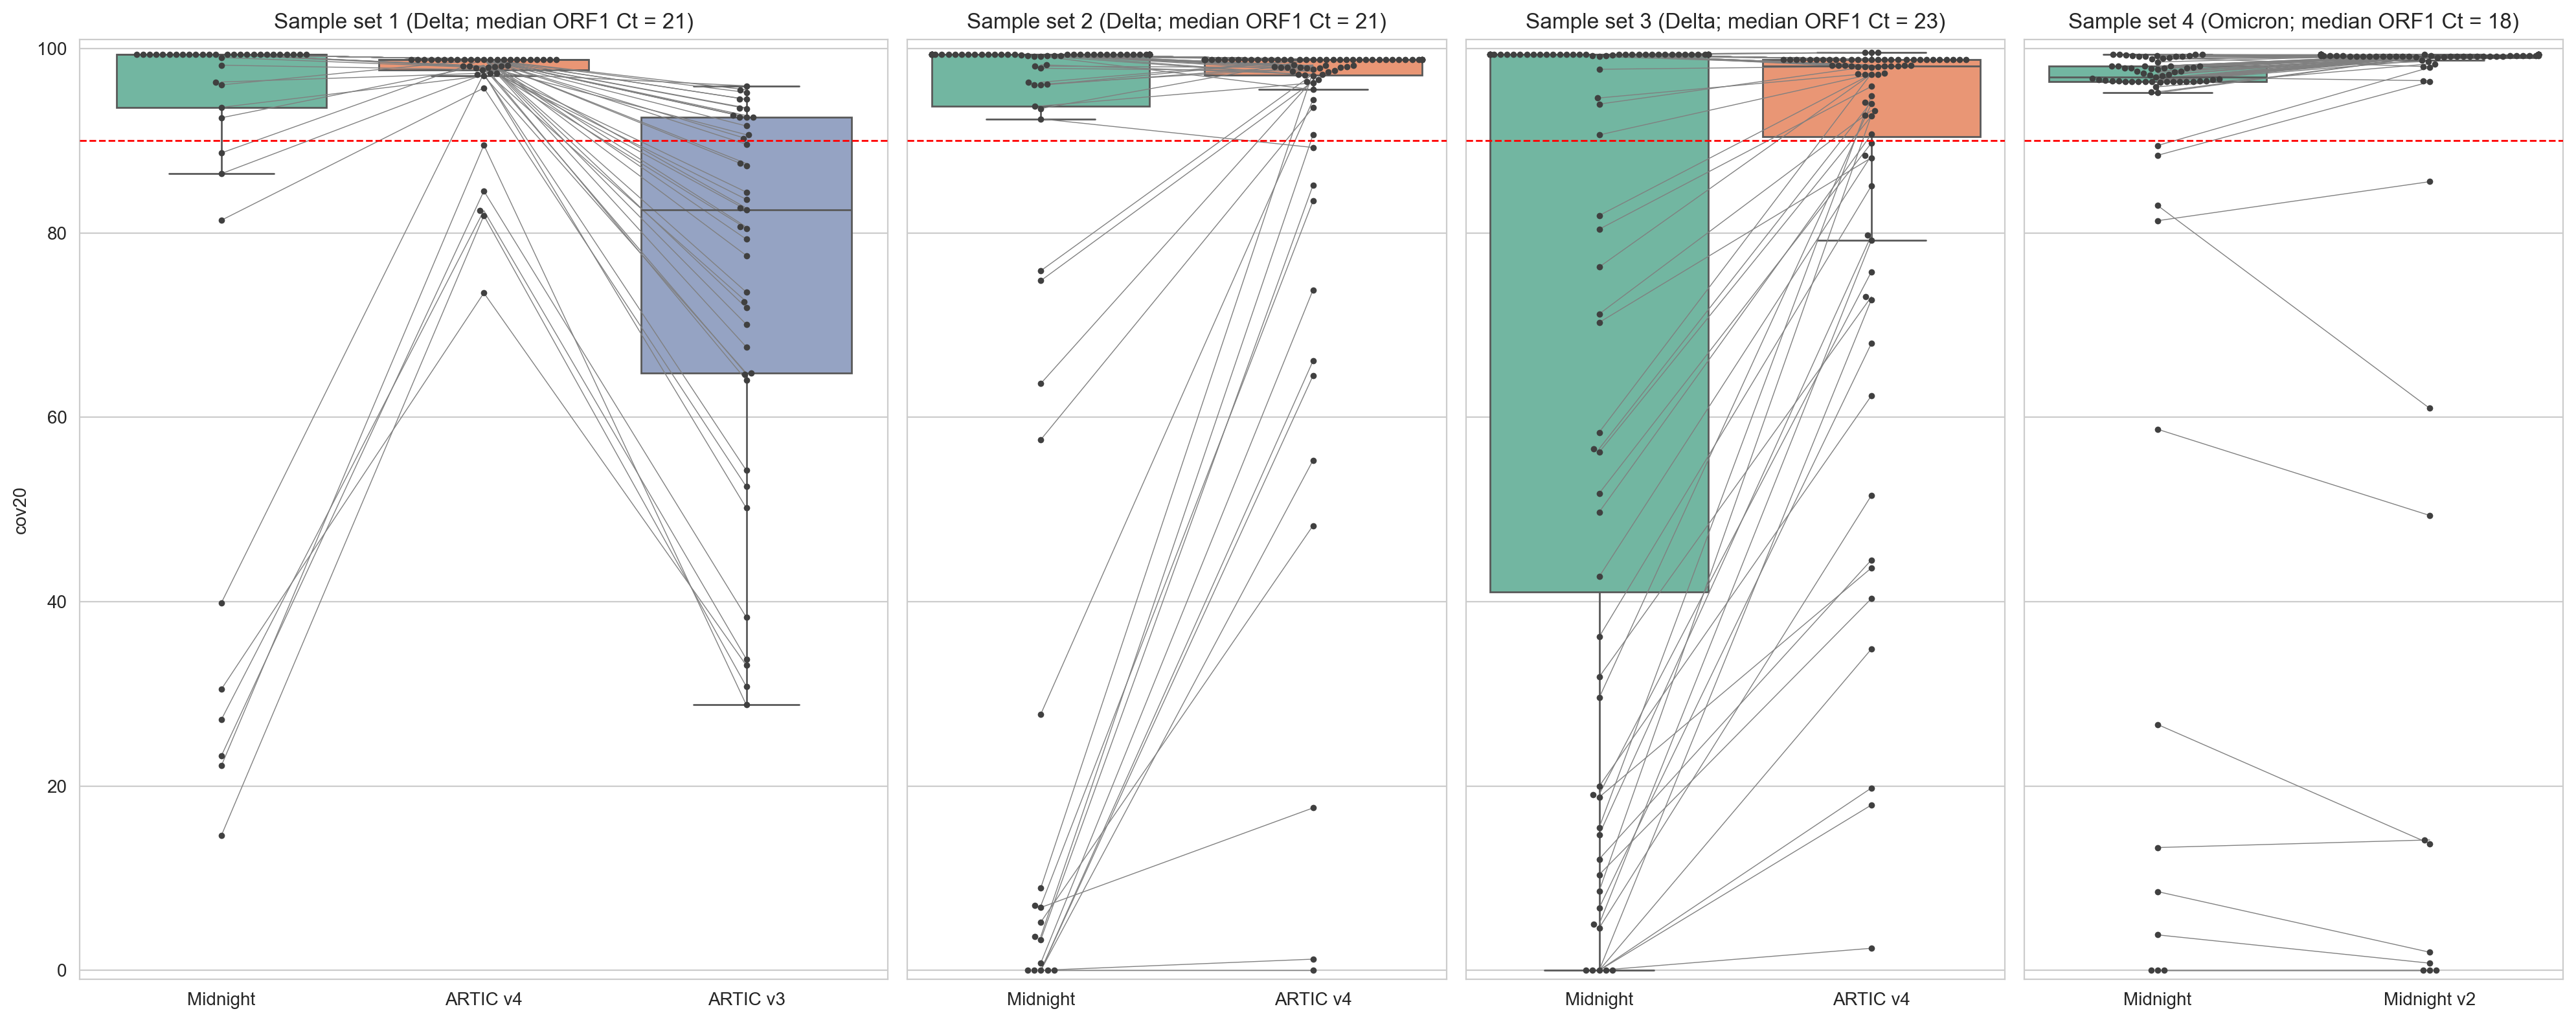

In [54]:
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(20,8), gridspec_kw={'width_ratios': [1.5, 1, 1, 1]}, sharey=True)

sns.set_style('whitegrid')
run_order = ['COVID_SEQ3_ARCTIC1_281021', '20211110_SEQ3_ARTICV4_JB_LD', '20211109_SEQ3_VH_MIDNIGHT_JB_LD']
protocol_order = ['Midnight', 'ARTIC v4', 'ARTIC v3']
title = 'Sample set 1 (Delta; median ORF1 Ct = 21)'
df = cov20_positive_df.query("run in @run_order and sample not in @excluded_samples").copy()
df['protocol_order'] = df['protocol'].map({'Midnight': 0, 'ARTIC v4': 1, 'ARTIC v3': 2}) 

ax[0] = sns.boxplot(x='protocol', hue='protocol', y='cov20', data=df, order=protocol_order, hue_order=protocol_order, palette=['#66c2a5', '#fc8d62', '#8da0cb'], fliersize=0, ax=ax[0], legend=False)
ax[0] = sns.swarmplot(dodge=True, x='protocol', y='cov20',  color='.25', data=df, order=protocol_order, s=3.5, ax=ax[0])
ax[0] = sns.lineplot(x='protocol', y='cov20', hue='sample', linewidth=0.5, ax=ax[0],
                  data=df.sort_values('protocol_order'),
                  palette=['grey' for i in range(df['sample'].nunique())],
                  legend=False)
ax[0].set(ylim=(-1,101), xlabel='', title=title)
ax[0].axhline(90, linestyle='--', linewidth=1, color='red', zorder=10)


run_order = ['20211124_MIDNIGHT_SEQ4_JB_LD', 'SEQ_4_ARTIC_221121']
protocol_order = ['Midnight', 'ARTIC v4']
title = 'Sample set 2 (Delta; median ORF1 Ct = 21)'
df = cov20_positive_df.query("run in @run_order and sample not in @excluded_samples").copy()
df['protocol_order'] = df['protocol'].map({'Midnight': 0, 'ARTIC v4': 1, 'ARTIC v3': 2}) 

ax[1] = sns.boxplot(x='protocol', hue='protocol', y='cov20', data=df, order=protocol_order, hue_order=protocol_order, palette=['#66c2a5', '#fc8d62'], fliersize=0, ax=ax[1], legend=False)
ax[1] = sns.swarmplot(dodge=True, x='protocol', y='cov20',  color='.25', data=df, order=protocol_order, s=3.5, ax=ax[1])
ax[1] = sns.lineplot(x='protocol', y='cov20', hue='sample', linewidth=0.5, ax=ax[1],
                  data=df.sort_values('protocol_order'),
                  palette=['grey' for i in range(df['sample'].nunique())],
                  legend=False)
ax[1].set(ylim=(-1,101), xlabel='', ylabel='', title=title)
ax[1].axhline(90, linestyle='--', linewidth=1, color='red', zorder=10)


run_order = ['SEQ_5_ARTIC_2_221121', 'SEQ_5_MID_2_PT_2']
protocol_order = ['Midnight', 'ARTIC v4']
title = 'Sample set 3 (Delta; median ORF1 Ct = 23)'
df = cov20_positive_df.query("run in @run_order and sample not in @excluded_samples").copy()
df['protocol_order'] = df['protocol'].map({'Midnight': 0, 'ARTIC v4': 1, 'ARTIC v3': 2}) 

ax[2] = sns.boxplot(x='protocol', hue='protocol', y='cov20', data=df, order=protocol_order, hue_order=protocol_order, palette=['#66c2a5', '#fc8d62'], fliersize=0, ax=ax[2], legend=False)
ax[2] = sns.swarmplot(dodge=True, x='protocol', y='cov20',  color='.25', data=df, order=protocol_order, s=3.5, ax=ax[2])
ax[2] = sns.lineplot(x='protocol', y='cov20', hue='sample', linewidth=0.5, ax=ax[2],
                  data=df.sort_values('protocol_order'),
                  palette=['grey' for i in range(df['sample'].nunique())],
                  legend=False)
ax[2].set(ylim=(-1,101), xlabel='', ylabel='', title=title)
ax[2].axhline(90, linestyle='--', linewidth=1, color='red', zorder=10)


run_order = ['SEQ6_MIDNIGHT_OLD_211214_JGJB', 'SEQ6_MIDNIGHT_NEW_16DEC21']
protocol_order = ['Midnight', 'Midnight v2']
title = 'Sample set 4 (Omicron; median ORF1 Ct = 18)'
df = cov20_positive_df.query("run in @run_order and sample not in @excluded_samples").copy()
df['protocol_order'] = df['protocol'].map({'Midnight': 0, 'Midnight v2': 1}) 

ax[3] = sns.boxplot(x='protocol', hue='protocol', y='cov20', data=df, order=protocol_order, hue_order=protocol_order, palette=['#66c2a5', '#e78ac3'], fliersize=0, ax=ax[3], legend=False)
ax[3] = sns.swarmplot(dodge=True, x='protocol', y='cov20',  color='.25', data=df, order=protocol_order, s=3.5, ax=ax[3])
ax[3] = sns.lineplot(x='protocol', y='cov20', hue='sample', linewidth=0.5, ax=ax[3],
                  data=df.sort_values('protocol_order'),
                  palette=['grey' for i in range(df['sample'].nunique())],
                  legend=False)
ax[3].set(ylim=(-1,101), xlabel='', ylabel='', title=title)
ax[3].axhline(90, linestyle='--', linewidth=1, color='red', zorder=10)


# fig.suptitle('Fig. 1: SARS-CoV-2 genome recovery (cov20) by protocol')
# fig.supxlabel('Genome recovered at or above depth 20 in head-to-head sequencing of 195 positive SARS-CoV-2 clinical samples of Delta lineage.\nRed line correspond to a widely used lower bound on genome recovery for lineage assignment (90%).')
fig.tight_layout()
# fig.savefig(f'{rp}/f1.pdf')

/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 14.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 14.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 7.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 46.4% of the points cannot be placed; you may want to decrease the size of the markers or use st

/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 14.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 7.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 46.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 34.0% of the points cannot be placed; you may want to decrease the size of the markers or use st

/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 41.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 25.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 39.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 18.3% of the points cannot be placed; you may want to decrease the size of the markers or use s

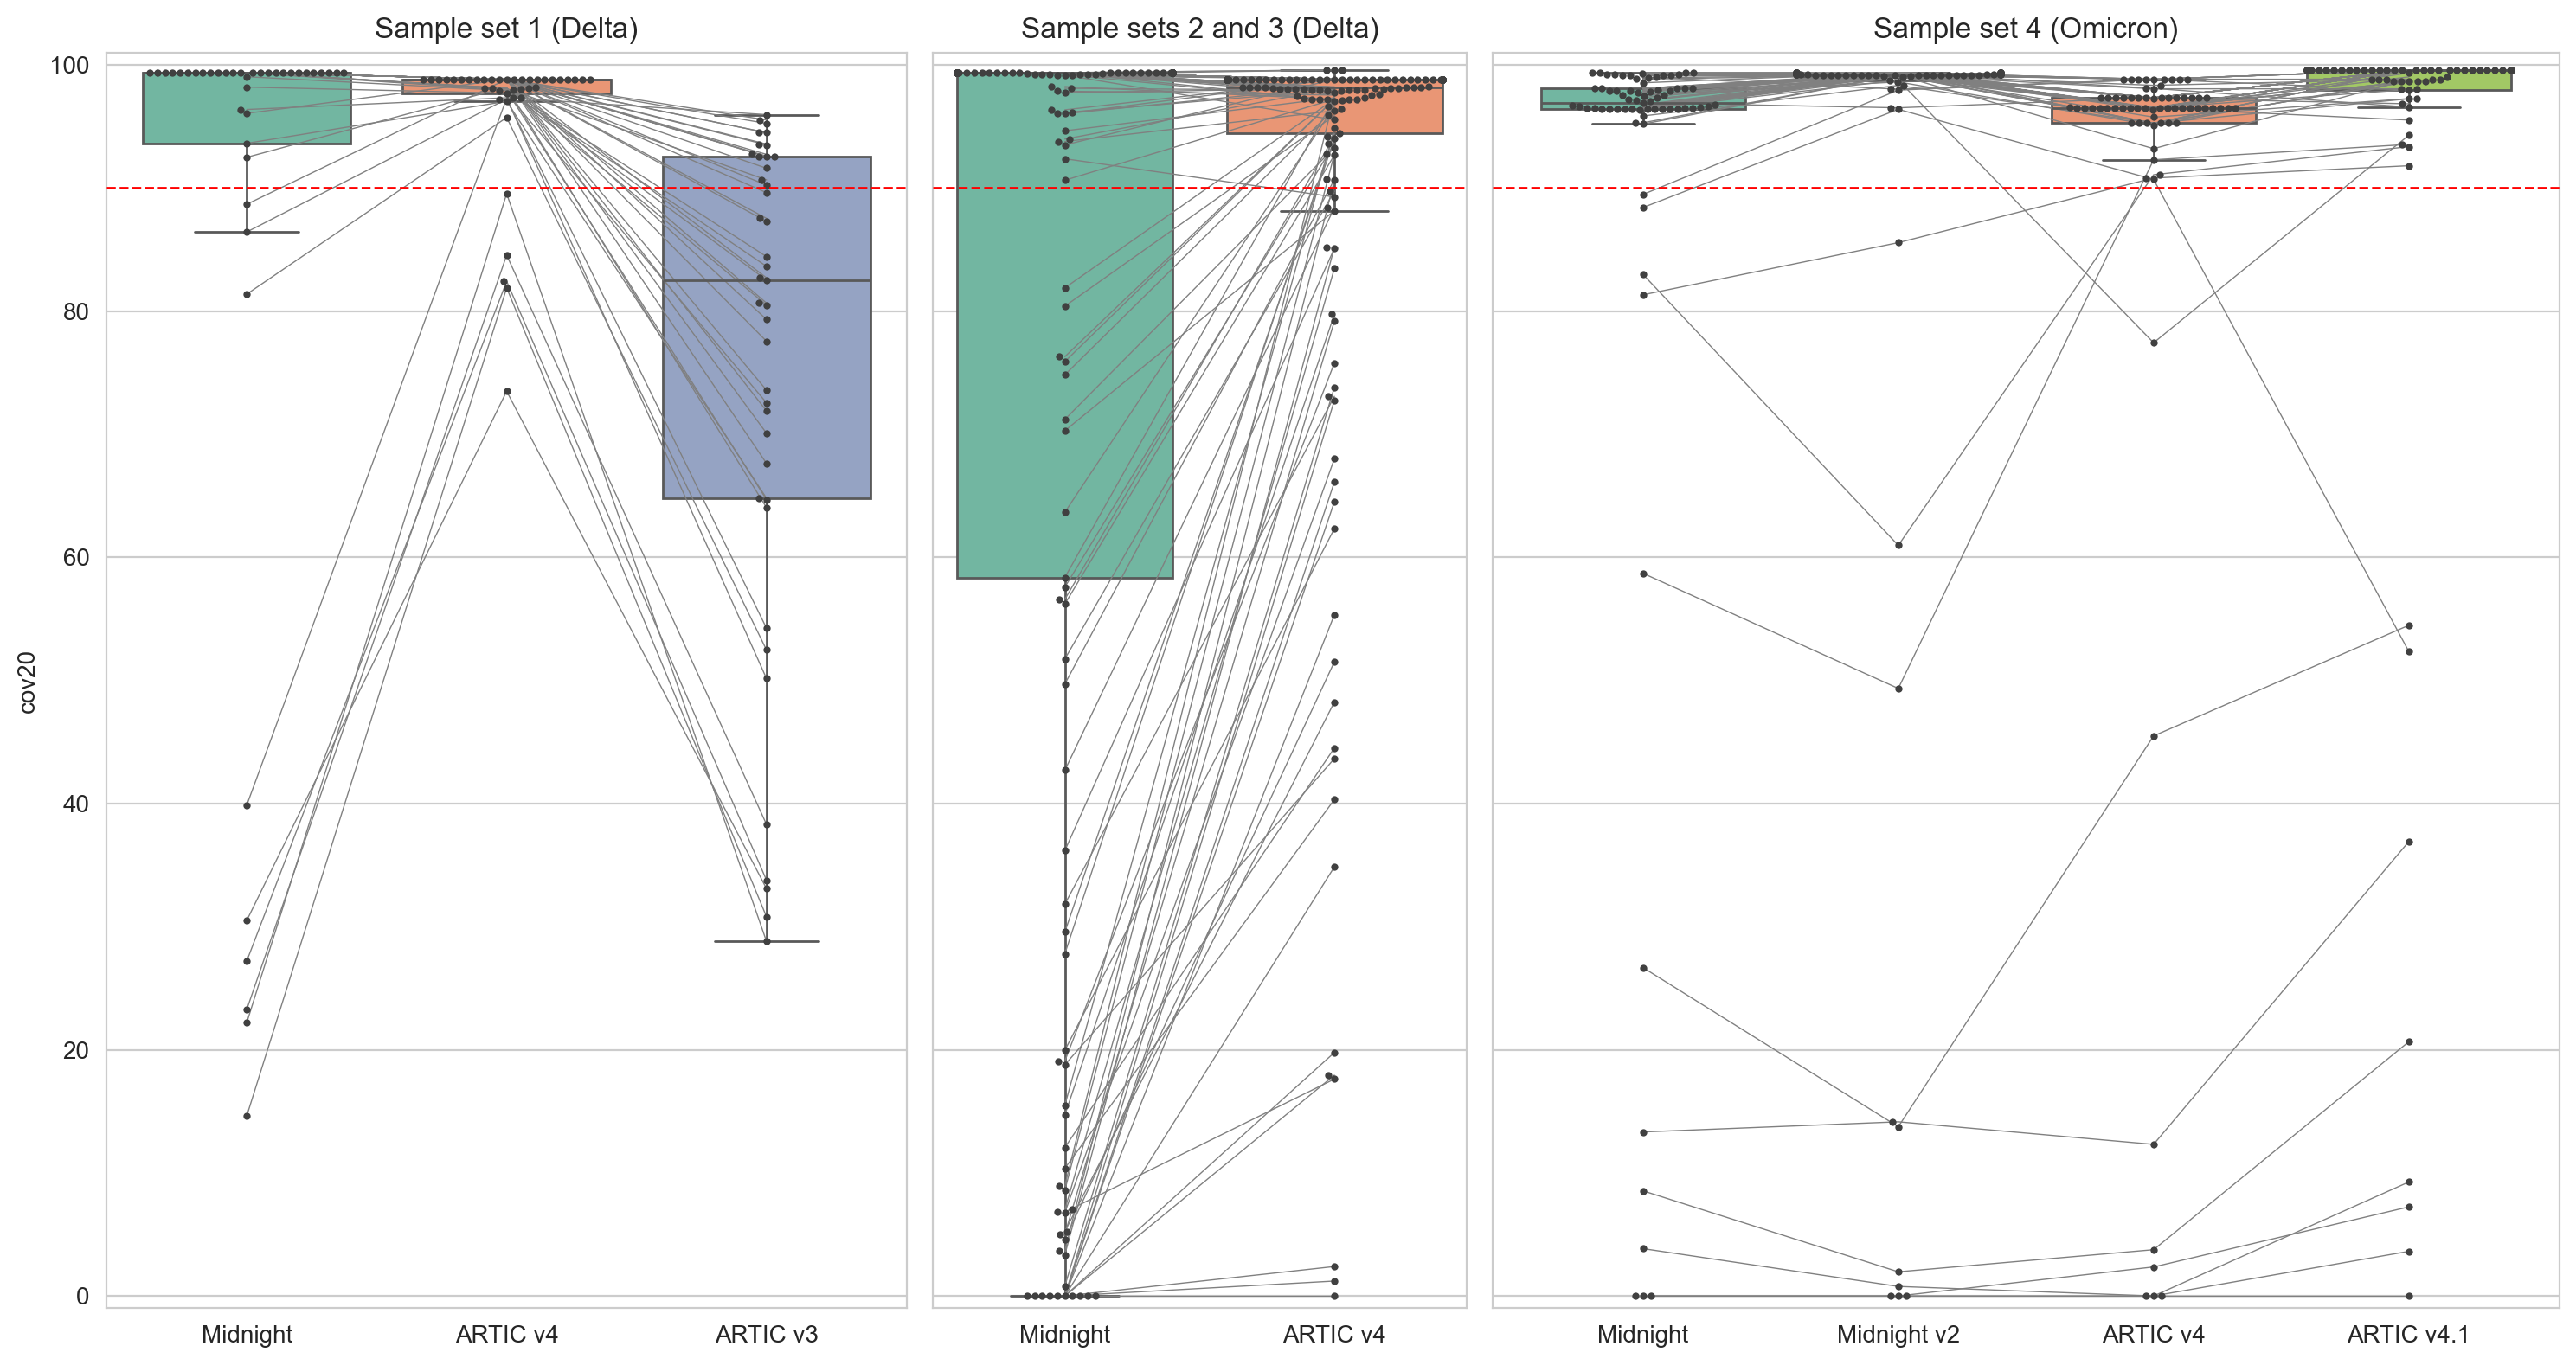

In [55]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15,8), gridspec_kw={'width_ratios': [1.5, 1, 2]}, sharey=True)

sns.set_style('whitegrid')
# protocol_order = ['Midnight', 'ARTIC v4', 'ARTIC v3', 'Midnight v2', 'ARTIC v4.1']
protocol_order = ['Midnight', 'ARTIC v4', 'ARTIC v3']
title = 'Sample set 1 (Delta)'
df = cov20_positive_df.query("plate == 1 and sample not in @excluded_samples").copy()
df['protocol_order'] = df['protocol'].map({'Midnight': 0, 'ARTIC v4': 1, 'ARTIC v3': 2}) 

ax[0] = sns.boxplot(x='protocol', hue='protocol', y='cov20', data=df, order=protocol_order, hue_order=protocol_order, palette=['#66c2a5', '#fc8d62', '#8da0cb'], fliersize=0, ax=ax[0], legend=False)
ax[0] = sns.swarmplot(dodge=True, x='protocol', y='cov20',  color='.25', data=df, order=protocol_order, s=3, ax=ax[0])
ax[0] = sns.lineplot(x='protocol', y='cov20', hue='sample', linewidth=0.5, ax=ax[0],
                  data=df.sort_values('protocol_order'),
                  palette=['grey' for i in range(df['sample'].nunique())],
                  legend=False)
ax[0].set(ylim=(-1,101), xlabel='', title=title)
ax[0].axhline(90, linestyle='--', linewidth=1, color='red', zorder=10)


protocol_order = ['Midnight', 'ARTIC v4']
title = 'Sample sets 2 and 3 (Delta)'
df = cov20_positive_df.query("(plate == 2 or plate == 3) and sample not in @excluded_samples").copy()
df['protocol_order'] = df['protocol'].map({'Midnight': 0, 'ARTIC v4': 1, 'ARTIC v3': 2}) 

ax[1] = sns.boxplot(x='protocol', hue='protocol', y='cov20', data=df, order=protocol_order, hue_order=protocol_order, palette=['#66c2a5', '#fc8d62'], fliersize=0, ax=ax[1], legend=False)
ax[1] = sns.swarmplot(dodge=True, x='protocol', y='cov20',  color='.25', data=df, order=protocol_order, s=3, ax=ax[1])
ax[1] = sns.lineplot(x='protocol', y='cov20', hue='sample', linewidth=0.5, ax=ax[1],
                  data=df.sort_values('protocol_order'),
                  palette=['grey' for i in range(df['sample'].nunique())],
                  legend=False)
ax[1].set(ylim=(-1,101), xlabel='', ylabel='', title=title)
ax[1].axhline(90, linestyle='--', linewidth=1, color='red', zorder=10)


# run_order = ['SEQ_5_ARTIC_2_221121', 'SEQ_5_MID_2_PT_2']
# protocol_order = ['Midnight', 'ARTIC v4']
# title = 'Sample set 3 (Delta; median ORF1 Ct = 23)'
# df = cov20_positive_df.query("run in @run_order and sample not in @excluded_samples").copy()
# df['protocol_order'] = df['protocol'].map({'Midnight': 0, 'ARTIC v4': 1, 'ARTIC v3': 2}) 

# ax[2] = sns.boxplot(x='protocol', y='cov20', data=df, order=protocol_order, palette=['#66c2a5', '#fc8d62'], fliersize=0, ax=ax[2])
# ax[2] = sns.swarmplot(dodge=True, x='protocol', y='cov20',  color='.25', data=df, order=protocol_order, s=3.5, ax=ax[2])
# ax[2] = sns.lineplot(x='protocol', y='cov20', hue='sample', linewidth=0.5, ax=ax[2],
#                   data=df.sort_values('protocol_order'),
#                   palette=['grey' for i in range(df['sample'].nunique())],
#                   legend=False)
# ax[2].set(ylim=(-1,101), xlabel='', ylabel='', title=title)
# ax[2].axhline(90, linestyle='--', linewidth=1, color='red', zorder=10)


protocol_order = ['Midnight', 'Midnight v2','ARTIC v4', 'ARTIC v4.1']
title = 'Sample set 4 (Omicron)'
df = cov20_positive_df.query("plate == 4 and sample not in @excluded_samples").copy()
df['protocol_order'] = df['protocol'].map({'Midnight': 0, 'ARTIC v4': 2, 'Midnight v2': 1, 'ARTIC v4.1': 3}) 

ax[2] = sns.boxplot(x='protocol', hue='protocol', y='cov20', data=df, order=protocol_order, hue_order=protocol_order, palette=['#66c2a5', '#e78ac3', '#fc8d62', '#a6d854'], fliersize=0, ax=ax[2], legend=False)
ax[2] = sns.swarmplot(dodge=True, x='protocol', y='cov20',  color='.25', data=df, order=protocol_order, s=3, ax=ax[2])
ax[2] = sns.lineplot(x='protocol', y='cov20', hue='sample', linewidth=0.5, ax=ax[2],
                  data=df.sort_values('protocol_order'),
                  palette=['grey' for i in range(df['sample'].nunique())],
                  legend=False)
ax[2].set(ylim=(-1,101), xlabel='', ylabel='', title=title)
ax[2].axhline(90, linestyle='--', linewidth=1, color='red', zorder=10)


# fig.suptitle('Fig. 1: SARS-CoV-2 genome recovery (cov20) by protocol')
# fig.supxlabel('Genome recovered at or above depth 20 in head-to-head sequencing of 195 positive SARS-CoV-2 clinical samples of Delta lineage.\nRed line correspond to a widely used lower bound on genome recovery for lineage assignment (90%).')
fig.tight_layout()
fig.savefig(f'{results_dir}/sfig1.pdf')
fig.savefig(f'{results_dir}/sfig1.png', dpi=200)

/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 22.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 17.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 22.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/bede/Research/git/sars2-midnight-eval/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 8.5% of the points cannot be placed; you may want to decrease the size of the markers or use st

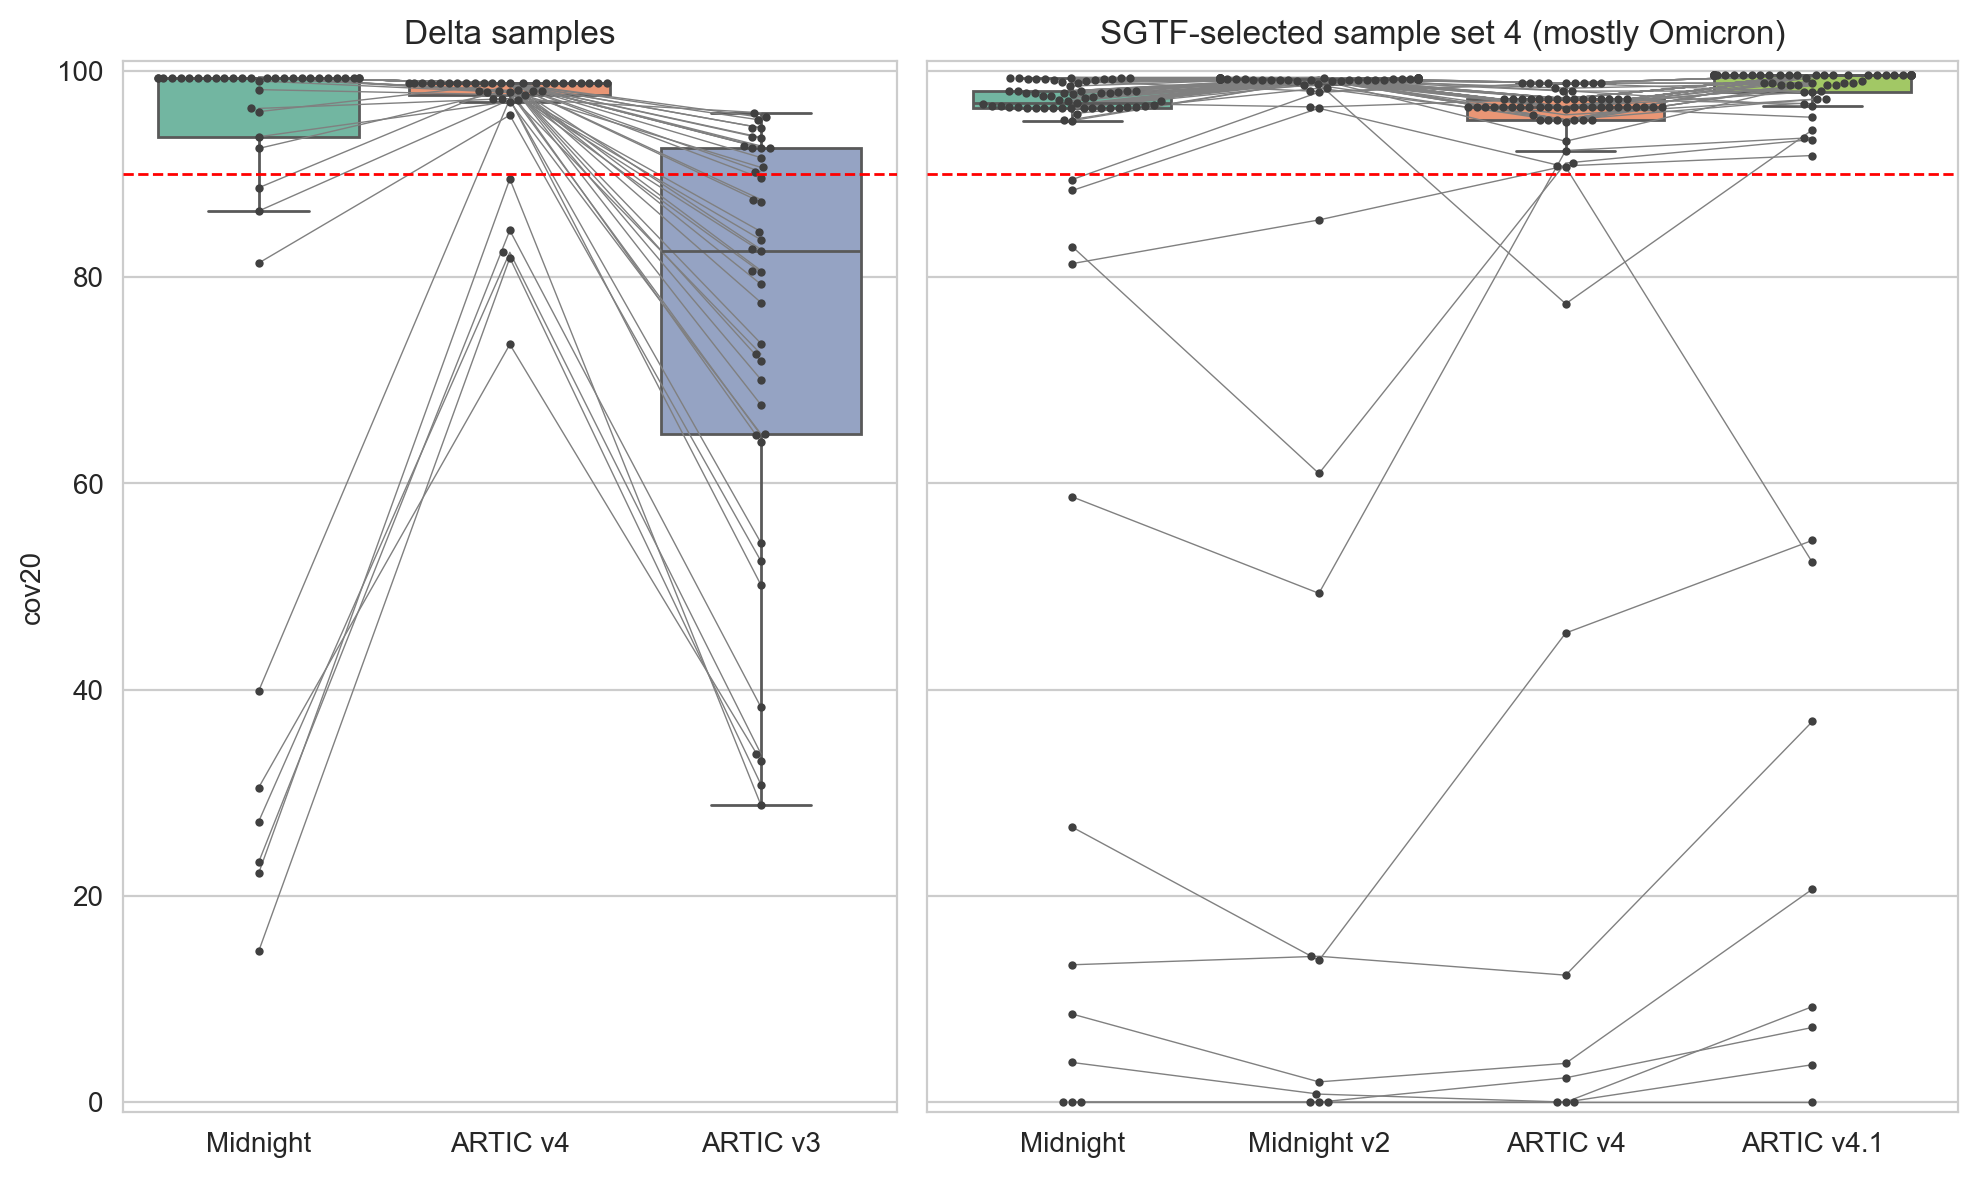

In [56]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,6), gridspec_kw={'width_ratios': [1.5, 2]}, sharey=True)

sns.set_style('whitegrid')
# protocol_order = ['Midnight', 'ARTIC v4', 'ARTIC v3', 'Midnight v2', 'ARTIC v4.1']
protocol_order = ['Midnight', 'ARTIC v4', 'ARTIC v3']
title = 'Delta samples'
df = cov20_positive_df.query("plate == 1 and sample not in @excluded_samples").copy()
df['protocol_order'] = df['protocol'].map({'Midnight': 0, 'ARTIC v4': 1, 'ARTIC v3': 2}) 

ax[0] = sns.boxplot(x='protocol', hue='protocol', y='cov20', data=df, order=protocol_order, hue_order=protocol_order, palette=['#66c2a5', '#fc8d62', '#8da0cb'], fliersize=0, ax=ax[0], legend=False)
ax[0] = sns.swarmplot(dodge=True, x='protocol', y='cov20',  color='.25', data=df, order=protocol_order, s=3, ax=ax[0])
ax[0] = sns.lineplot(x='protocol', y='cov20', hue='sample', linewidth=0.5, ax=ax[0],
                  data=df.sort_values('protocol_order'),
                  palette=['grey' for i in range(df['sample'].nunique())],
                  legend=False)
ax[0].set(ylim=(-1,101), xlabel='', title=title)
ax[0].axhline(90, linestyle='--', linewidth=1, color='red', zorder=10)


# protocol_order = ['Midnight', 'ARTIC v4']
# title = 'Sample sets 2 and 3 (Delta)'
# df = cov20_positive_df.query("(plate == 2 or plate == 3) and sample not in @excluded_samples").copy()
# df['protocol_order'] = df['protocol'].map({'Midnight': 0, 'ARTIC v4': 1, 'ARTIC v3': 2}) 

# ax[1] = sns.boxplot(x='protocol', y='cov20', data=df, order=protocol_order, palette=['#66c2a5', '#fc8d62'], fliersize=0, ax=ax[1])
# ax[1] = sns.swarmplot(dodge=True, x='protocol', y='cov20',  color='.25', data=df, order=protocol_order, s=3, ax=ax[1])
# ax[1] = sns.lineplot(x='protocol', y='cov20', hue='sample', linewidth=0.5, ax=ax[1],
#                   data=df.sort_values('protocol_order'),
#                   palette=['grey' for i in range(df['sample'].nunique())],
#                   legend=False)
# ax[1].set(ylim=(-1,101), xlabel='', ylabel='', title=title)
# ax[1].axhline(90, linestyle='--', linewidth=1, color='red', zorder=10)


# run_order = ['SEQ_5_ARTIC_2_221121', 'SEQ_5_MID_2_PT_2']
# protocol_order = ['Midnight', 'ARTIC v4']
# title = 'Sample set 3 (Delta; median ORF1 Ct = 23)'
# df = cov20_positive_df.query("run in @run_order and sample not in @excluded_samples").copy()
# df['protocol_order'] = df['protocol'].map({'Midnight': 0, 'ARTIC v4': 1, 'ARTIC v3': 2}) 

# ax[2] = sns.boxplot(x='protocol', y='cov20', data=df, order=protocol_order, palette=['#66c2a5', '#fc8d62'], fliersize=0, ax=ax[2])
# ax[2] = sns.swarmplot(dodge=True, x='protocol', y='cov20',  color='.25', data=df, order=protocol_order, s=3.5, ax=ax[2])
# ax[2] = sns.lineplot(x='protocol', y='cov20', hue='sample', linewidth=0.5, ax=ax[2],
#                   data=df.sort_values('protocol_order'),
#                   palette=['grey' for i in range(df['sample'].nunique())],
#                   legend=False)
# ax[2].set(ylim=(-1,101), xlabel='', ylabel='', title=title)
# ax[2].axhline(90, linestyle='--', linewidth=1, color='red', zorder=10)


protocol_order = ['Midnight', 'Midnight v2','ARTIC v4', 'ARTIC v4.1']
title = 'SGTF-selected sample set 4 (mostly Omicron)'
df = cov20_positive_df.query("plate == 4 and sample not in @excluded_samples").copy()
df['protocol_order'] = df['protocol'].map({'Midnight': 0, 'ARTIC v4': 2, 'Midnight v2': 1, 'ARTIC v4.1': 3}) 

ax[1] = sns.boxplot(x='protocol', hue='protocol', y='cov20', data=df, order=protocol_order, hue_order=protocol_order, palette=['#66c2a5', '#e78ac3', '#fc8d62', '#a6d854'], fliersize=0, ax=ax[1], legend=False)
ax[1] = sns.swarmplot(dodge=True, x='protocol', y='cov20',  color='.25', data=df, order=protocol_order, s=3, ax=ax[1])
ax[1] = sns.lineplot(x='protocol', y='cov20', hue='sample', linewidth=0.5, ax=ax[1],
                  data=df.sort_values('protocol_order'),
                  palette=['grey' for i in range(df['sample'].nunique())],
                  legend=False)
ax[1].set(ylim=(-1,101), xlabel='', ylabel='', title=title)
ax[1].axhline(90, linestyle='--', linewidth=1, color='red', zorder=10)


# fig.suptitle('Fig. 1: SARS-CoV-2 genome recovery (cov20) by protocol')
# fig.supxlabel('Genome recovered at or above depth 20 in head-to-head sequencing of 195 positive SARS-CoV-2 clinical samples of Delta lineage.\nRed line correspond to a widely used lower bound on genome recovery for lineage assignment (90%).')
fig.tight_layout()
fig.savefig(f'{results_dir}/f1.1.pdf')

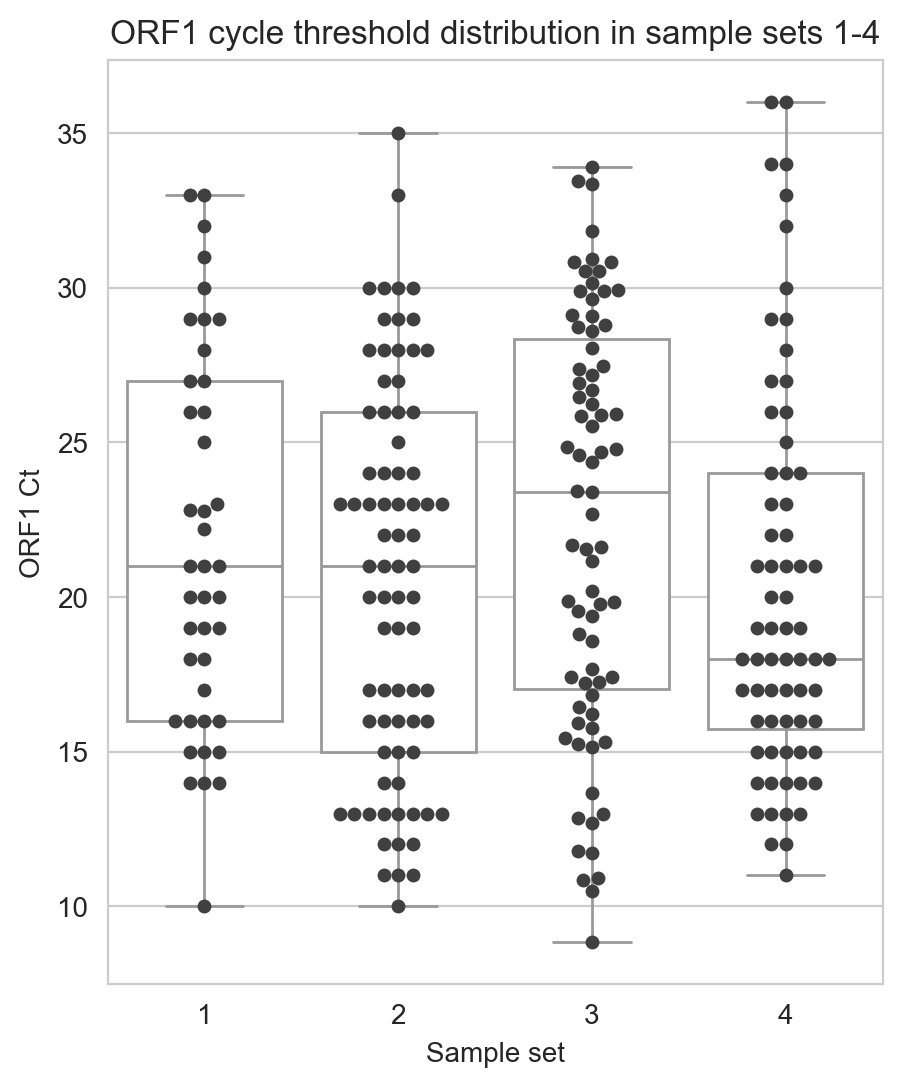

In [57]:
plt.figure(figsize=(5,6))
ax = sns.boxplot(x='plate', hue='plate', y='orf1_ct', data=cov20_positive_df.drop_duplicates('sample'), palette=['white']*4, legend=False)
ax = sns.swarmplot(dodge=True, x='plate', y='orf1_ct',  color='.25', data=cov20_positive_df.drop_duplicates('sample'))
ax.set(xlabel='Sample set', ylabel='ORF1 Ct', title='ORF1 cycle threshold distribution in sample sets 1-4')
plt.savefig(f'{results_dir}/sfig2.pdf')
plt.savefig(f'{results_dir}/sfig2.png', dpi=200)

In [58]:
cov20_positive_df.groupby('plate').median(numeric_only=True)

,positive,analysis_eligible,cov20,orf1_ct,acgt,protocol_order
plate,,,,,,
1,1.0,1.0,97.217670,21.000000,0.972,1.0
2,1.0,1.0,98.826205,21.000000,0.988,0.5
3,1.0,1.0,98.180785,23.420651,0.981,0.5
4,1.0,1.0,98.038658,18.000000,0.980,2.0


In [59]:
annotation_df = pd.read_csv(f'{rp}/in/annotation.gff', sep='\t', skiprows=3
                            ).rename(columns={'attribute': 'gene'}
                            ).replace('gene_name=', '', regex=True
                            ).replace(r"^ +| +$", r"", regex=True
                            ).sort_values('start'
                            )[['start', 'end', 'gene']]
annotation_df['mid'] = annotation_df['start'] + ((annotation_df['end']-annotation_df['start'])/2)
annotation_df

,start,end,gene,mid
3,266,13468,ORF1a,6867.0
4,13468,21555,ORF1b,17511.5
11,21563,25384,S,23473.5
5,25393,26220,ORF3a,25806.5
0,26245,26472,E,26358.5
1,26523,27191,M,26857.0
6,27202,27387,ORF6,27294.5
7,27394,27759,ORF7a,27576.5
8,27756,27887,ORF7b,27821.5
9,27894,28259,ORF8,28076.5


In [60]:
def _gene_track(gutter=True):
    # gutter=True reserves the same left margin as the panels above, so the
    # track lines up; the right-hand copy sits under a facet column that has
    # no y-axis, so it takes no gutter.
    yax = alt.Axis(minExtent=55, labels=False, ticks=False, domain=False) if gutter else None
    rect = alt.Chart(annotation_df).transform_calculate(track='"genes"').mark_rect(
        color='black', strokeWidth=1, strokeOpacity=1, filled=False).encode(
        x=alt.X('start:Q', title=None, scale=alt.Scale(domain=[0, 29903], nice=False, padding=0), axis=None),
        x2='end:Q',
        y=alt.Y('track:N', title=None, axis=yax),
    ).properties(width=350, height=22)
    text = alt.Chart(annotation_df.head(3)).transform_calculate(track='"genes"').mark_text(
        baseline='middle', color='black').encode(
        alt.X('mid:Q', title=None, scale=alt.Scale(domain=[0, 29903], nice=False, padding=0), axis=None),
        y=alt.Y('track:N', title=None, axis=yax),
        text='gene:N',
    ).properties(width=350, height=22)
    return rect + text

annotation = _gene_track()
annotation2 = alt.hconcat(_gene_track(True), _gene_track(False), spacing=30)
annotation

alt.LayerChart(...)

In [61]:
rect = alt.Chart(annotation_df).mark_rect(color='black', strokeWidth=1, strokeOpacity=1, filled=False).encode(
    x=alt.X('start:Q', title='position'),
    x2='end:Q',
    # color=alt.Color('gene:N', scale=alt.Scale(domain=annotation_df['gene'].tolist(), scheme='Set3'), legend=None)
    # color=alt.Color('gene:N', scale=alt.Scale(domain=annotation_df['gene'].tolist(), range=['black']*annotation_df['gene'].shape[0]), legend=None)
).properties(
    width=250,
)

text = alt.Chart(annotation_df.head(3)).mark_text(baseline='middle', color='black').encode(
    alt.X('mid:Q', title=None, scale=alt.Scale(domain=[1000, 29000]), axis=None),
    text='gene:N'
).properties(
    width=250,
)

annotation = rect + text
annotation250 = annotation | annotation

In [62]:
lineages_df.query("plate == 4")['sample'].unique()

array(['D6146-CCL81|P3D2', '3a2fd017b7137653', '666b780c76d463e7',
       'b86299406728ffc1', '10263e540345bfbb', '9fbc7191a57ffc55',
       '8a521f6f326937da', '182f63d231a3a1bf', '396cb14054d9c0f3',
       '3c6259c0ffba4f04', '66e85807a4680923', '1357aeecade5f126',
       'af55853acb42221e', '393cbb07b1663dc0', 'ecd348488356db1e',
       'b6b69d6bdf2f74bb', 'dc970558f1300f32', '846b7fcd57b5a6e2',
       'cc60fcba20cea963', '10d35ed880c92611', '5c5d17966a64ade5',
       'bba172ce7f083069', 'cdc9e9479983953f', 'ee3417c03a337034',
       'b10bfaca6f60cbe8', 'cf995fc2dde26525', '1ec4cd60faff94b4',
       'f1c075c8bc61e36b', 'a48539abdd0b42f1', '773db6a4564d5d7b',
       '33ed61f32b15ab2b', 'fb080e620e8c1194', 'c778a84861b2d480',
       '70e7ebef94f4a207', 'a4734ca896248b17', 'f5da5a14105d415b',
       'e0c044286c6bcef1', '2a509be37d45cc2b', '435535483d1f66d3',
       '4bf82aa2e826ef91', '0cfb753561f2dca3', '4b7c77df2ea779a7',
       'bdda876a735fd280', 'c31a88b38d640ffd', 'd35dd617fb1061

In [63]:
positive_samples = cov20_positive_df['sample'].unique()
protocol_defect_df = wf_depth_df.query("266 < pos < 29533 and depth < 20 and sample in @positive_samples")

protocol_defect_summary_df = protocol_defect_df.groupby(['plate', 'plate_lineage', 'protocol', 'pos'])[['depth']].count().reset_index()
protocol_defect_summary_df['proportion'] = protocol_defect_summary_df['depth']/41

In [64]:
plate1_defect_bins_df = protocol_defect_summary_df.query("266 < pos < 29533 and plate == 1 and protocol != 'Midnight'").copy()
# bin to display resolution (~4 bins per rendered pixel) and keep the max per bin:
# reproduces what the overlapping 1px bars render as, deterministically
plate1_defect_bins_df['pos'] = (plate1_defect_bins_df['pos'] // 20) * 20
plate1_defect_bins_df = plate1_defect_bins_df.groupby(['protocol', 'pos'], as_index=False)['proportion'].max()

c1 = alt.Chart(plate1_defect_bins_df).mark_bar(size=1, opacity=1.0).encode(
    alt.X('pos:Q', title=None, scale=alt.Scale(domain=[0, 29903], nice=False, padding=0)),
    alt.Y('proportion:Q', scale=alt.Scale(domain=[0, 1])),
    color=alt.Color('protocol', scale=alt.Scale(domain=['ARTIC v3', 'ARTIC v4'], range=['#8DA0CB', '#fc8d62']), legend=None),
    facet=alt.Facet('protocol:N', columns=2, sort=['ARTIC v3', 'ARTIC v4'], title=None)
).properties(
    width=350,
    height=80,
    title='A) Proportion of samples with coverage defects by genome position (Delta samples)'
)

c2 = alt.Chart(defect_intervals_df.query("sample in @positive_samples and plate == 1 and protocol != 'Midnight'")).mark_rect(opacity=1, fillOpacity=1, strokeOpacity=1, filled=True).encode(
    alt.X('start_pos:Q', title='position', scale=alt.Scale(domain=[0, 29903], nice=False, padding=0)),
    alt.X2('end_pos:Q'),
    alt.Y('sample:O', axis=alt.Axis(grid=False, labels=False), sort=ct_df.sort_values(['orf1_ct']).query(f"sample in @positive_samples").index.tolist()),
    color=alt.Color('protocol', scale=alt.Scale(domain=['ARTIC v3', 'ARTIC v4'], range=['#8DA0CB', '#fc8d62']), legend=None),
    facet=alt.Column('protocol:N', sort=['ARTIC v3', 'ARTIC v4'], title=None)
).properties(
    width=350,
    height=350,
    title='B) Coverage defects by genome position by sample (Delta samples)'
)

alt.vconcat(c1, c2, annotation2)
# .save(f'{rp}/ss1_v3v4.svg')

alt.VConcatChart(...)

In [65]:
defect_intervals_df

,start_pos,end_pos,run,barcode,sample,plate,protocol,positive,analysis_eligible,plate_lineage
res,,,,,,,,,,
1,1,54,COVID_SEQ3_ARCTIC1_281021,01,7c19a27c938c0d9f,1,ARTIC v3,True,True,Delta
2,1313,1595,COVID_SEQ3_ARCTIC1_281021,01,7c19a27c938c0d9f,1,ARTIC v3,True,True,Delta
3,2243,2850,COVID_SEQ3_ARCTIC1_281021,01,7c19a27c938c0d9f,1,ARTIC v3,True,True,Delta
4,3781,3795,COVID_SEQ3_ARCTIC1_281021,01,7c19a27c938c0d9f,1,ARTIC v3,True,True,Delta
5,4996,5287,COVID_SEQ3_ARCTIC1_281021,01,7c19a27c938c0d9f,1,ARTIC v3,True,True,Delta
...,...,...,...,...,...,...,...,...,...,...
3,6860,7084,20211221_V4_1_SEQ6_2_JB,94,330c72cbf477025a,4,ARTIC v4.1,True,True,Omicron
4,29828,29903,20211221_V4_1_SEQ6_2_JB,94,330c72cbf477025a,4,ARTIC v4.1,True,True,Omicron
1,1,50,20211221_V4_1_SEQ6_2_JB,95,Brazil-P.2-CCL81|P2D2,4,ARTIC v4.1,False,False,Omicron


In [66]:
delta_selected_keys_df = delta_paired_df[['run', 'barcode']].drop_duplicates()
delta_depth_df = wf_depth_df.merge(delta_selected_keys_df, on=['run', 'barcode'], how='inner', validate='many_to_one')
delta_defect_intervals_df = defect_intervals_df.merge(delta_selected_keys_df, on=['run', 'barcode'], how='inner', validate='many_to_one')
protocol_defect_df = delta_depth_df.query("266 < pos < 29533 and depth < 20")

protocol_defect_summary_df = protocol_defect_df.groupby(['plate_lineage', 'protocol', 'pos'])[['depth']].count().reset_index()
delta_defect_denominators = delta_paired_df.groupby('protocol')['sample'].nunique()
protocol_defect_summary_df['proportion'] = protocol_defect_summary_df['depth'] / protocol_defect_summary_df['protocol'].map(delta_defect_denominators)
assert delta_defect_denominators.eq(193).all()

In [67]:
# c1 = alt.Chart(protocol_defect_summary_df.query("266 < pos < 29533 and plate_lineage == 'Delta' and protocol != 'ARTIC v3'")).mark_bar(size=1, opacity=1.0).encode(
#     alt.X('pos:Q', title='position'),
#     alt.Y('proportion:Q', scale=alt.Scale(domain=[0, 1])),
#     color=alt.Color('protocol', scale=alt.Scale(domain=['Midnight', 'ARTIC v4'], range=['#66c2a5', '#fc8d62'])),
#     facet=alt.Facet('protocol:N', columns=2, sort=['Midnight', 'ARTIC v4'], title=None)
# ).properties(
#     width=600,
#     height=80,
#     title='Coverage defects by genome position (Delta samples)'
# )

# c2 = alt.Chart(wf_depth_df.query("266 < pos < 29533 and depth < 20 and sample in @positive_samples and protocol != 'ARTIC v3' and plate_lineage == 'Delta'").iloc[::5, :]).mark_tick(size=1, height=2, opacity=1.0).encode(
#     alt.X('pos:Q', title='position'),
#     alt.Y('sample:O', axis=alt.Axis(grid=True, labels=False), sort=ct_df.sort_values(['orf1_ct']).query(f"sample in @positive_samples").index.tolist()),
#     color=alt.Color('protocol', scale=alt.Scale(domain=['Midnight', 'ARTIC v4'], range=['#66c2a5', '#fc8d62'])),
#     facet=alt.Column('protocol:N', sort=['Midnight', 'ARTIC v4'], title=None)
# ).properties(
#     width=600,
#     height=600,
# )

# alt.vconcat(c1, c2)

In [68]:
delta_defect_bins_df = protocol_defect_summary_df.query("266 < pos < 29533 and plate_lineage == 'Delta' and protocol != 'ARTIC v3'").copy()
# bin to display resolution (~4 bins per rendered pixel) and keep the max per bin:
# reproduces what the overlapping 1px bars render as, deterministically
delta_defect_bins_df['pos'] = (delta_defect_bins_df['pos'] // 20) * 20
delta_defect_bins_df = delta_defect_bins_df.groupby(['protocol', 'pos'], as_index=False)['proportion'].max()

c1 = alt.Chart(delta_defect_bins_df).mark_bar(size=1, opacity=1.0).encode(
    alt.X('pos:Q', title=None, scale=alt.Scale(domain=[0, 29903], nice=False, padding=0)),
    alt.Y('proportion:Q', scale=alt.Scale(domain=[0, 1]), axis=alt.Axis(minExtent=55)),
    color=alt.Color('protocol', scale=alt.Scale(domain=['Midnight', 'ARTIC v4'], range=['#66c2a5', '#fc8d62']), legend=None),
    facet=alt.Facet('protocol:N', columns=2, sort=['Midnight', 'ARTIC v4'], title=None, spacing=30)
).properties(
    width=350,
    height=80,
    title='A) Proportion of samples with coverage defects by genome position (Delta samples)'
)

c2 = alt.Chart(delta_defect_intervals_df).mark_rect(opacity=1, fillOpacity=1, strokeOpacity=1, filled=True).encode(
    alt.X('start_pos:Q', title='position', scale=alt.Scale(domain=[0, 29903], nice=False, padding=0)),
    alt.X2('end_pos:Q'),
    alt.Y('sample:O', axis=alt.Axis(grid=False, labels=False, ticks=False, domain=False, minExtent=55), sort=delta_paired_df.sort_values('orf1_ct')['sample'].drop_duplicates().tolist()),
    color=alt.Color('protocol', scale=alt.Scale(domain=['Midnight', 'ARTIC v4'], range=['#66c2a5', '#fc8d62']), legend=None),
    facet=alt.Facet('protocol:N', columns=2, sort=['Midnight', 'ARTIC v4'], title=None, spacing=30)
).properties(
    width=350,
    height=350,
    title='B) Coverage defects by genome position by sample (Delta samples)'
)

fig2 = alt.vconcat(c1, c2, annotation2, spacing=10)
fig2.save(f'{results_dir}/fig2.svg')
fig2.save(f'{results_dir}/fig2.png', scale_factor=4)

In [69]:
lineages_df['scorpio_call'].value_counts()

scorpio_call
Delta (AY.4-like)         302
Omicron (BA.1-like)       194
Delta (B.1.617.2-like)     76
Delta (AY.4.2-like)        45
Alpha (B.1.1.7-like)        4
Beta (B.1.351-like)         4
Gamma (P.1-like)            4
Zeta (P.2-like)             4
Eta (B.1.525-like)          4
B.1.1.7-like+E484K          4
Name: count, dtype: int64

In [70]:
protocol_defect_df.query("plate_lineage == 'Omicron' and pos == 28000")['sample'].nunique()

0

In [71]:
protocol_defect_df.query("plate_lineage == 'Omicron'")['sample'].nunique()

0

In [72]:
lineages_df.query("run == 'SEQ6_MIDNIGHT_NEW_16DEC21' and sample in @positive_samples").shape

(71, 17)

In [73]:
lineages_df.query("run == 'SEQ6_MIDNIGHT_NEW_16DEC21'").shape

(96, 17)

In [74]:
lineages_df.query("run == 'SEQ6_MIDNIGHT_NEW_16DEC21' and scorpio == 'Omicron'").shape

(48, 17)

In [75]:
lineages_df.query("plate == 4 and sample in @positive_samples").sort_values('scorpio_support', ascending=False).drop_duplicates('sample')['scorpio'].value_counts()

scorpio
Omicron    49
Delta      15
Name: count, dtype: int64

In [76]:
lineages_df.query("run == 'SEQ6_MIDNIGHT_NEW_16DEC21'")['scorpio_call'].value_counts()

scorpio_call
Omicron (BA.1-like)       48
Delta (AY.4-like)         13
Delta (B.1.617.2-like)     3
Gamma (P.1-like)           1
Alpha (B.1.1.7-like)       1
Beta (B.1.351-like)        1
Zeta (P.2-like)            1
Eta (B.1.525-like)         1
B.1.1.7-like+E484K         1
Name: count, dtype: int64

In [77]:
len(set(cov20_positive_df.query("plate == 1")['sample'].unique()) | set(cov20_positive_df.query("plate == 2")['sample'].unique()) | set(cov20_positive_df.query("plate == 3")['sample'].unique()))

193

In [78]:
protocol_defect_df['sample'].nunique()

190

In [79]:
dff = pd.DataFrame([
        {'s': 1, 'gene': 267, 'start': 267, 'stop': 6308},
        {'s': 2, 'gene': 6668, 'start': 6668, 'stop': 7285},
        {'s': 1, 'gene': 7306, 'start': 7306, 'stop': 8283},
        {'s': 2, 'gene': 9379, 'start': 9379, 'stop': 10371},
        {'s': 1, 'gene': 11448, 'start': 11448, 'stop': 29533}])

rect = alt.Chart(dff).mark_rect(color='black', strokeWidth=1, strokeOpacity=1, filled=False).encode(
    x=alt.X('start:Q', title='position'),
    x2='stop:Q',
    y='s:N'
    # color=alt.Color('gene:N', scale=alt.Scale(domain=annotation_df['gene'].tolist(), scheme='Set3'), legend=None)
    # color=alt.Color('gene:N', scale=alt.Scale(domain=annotation_df['gene'].tolist(), range=['black']*annotation_df['gene'].shape[0]), legend=None)
).properties(
    width=350,
)
rect



# alt.Chart(dff).mark_tick(size=1, height=3, opacity=1.0).encode(
#     alt.X('pos:Q', title='position', scale=alt.Scale(domain=[1000, 29000])),
#     alt.Y('sample:O', axis=alt.Axis(grid=True, labels=False), sort=ct_df.sort_values(['orf1_ct']).query(f"sample in @positive_samples").index.tolist()),
#     alt.Color('protocol:N', scale=alt.Scale(domain=['Midnight', 'Midnight v2', 'ARTIC v4', 'ARTIC v4.1'], range=['#66c2a5', '#e78ac3', '#fc8d62', '#a6d854']), legend=None),
#     alt.Facet('protocol:N', columns=2, sort=['Midnight', 'Midnight v2', 'ARTIC v4', 'ARTIC v4.1'], title=None)
# ).properties(
#     width=350,
#     height=200,
#     title='B) Coverage defects by genome position by sample (Omicron samples)'
# )


alt.Chart(...)

In [80]:
dfff = pd.DataFrame([
        {'s': 1, 'pos': 1},
        {'s': 1, 'pos': 2},
        {'s': 1, 'pos': 3},
        {'s': 2, 'pos': 1},
        {'s': 2, 'pos': 4},
        {'s': 2, 'pos': 5},
        {'s': 2, 'pos': 6},
        {'s': 2, 'pos': 8},
        {'s': 2, 'pos': 10},
        {'s': 2, 'pos': 11}])

dfff['res'] = dfff.groupby('s')['pos'].diff().ne(1).cumsum()
dfff = dfff.groupby('res').agg({'pos': ['min', 'max']})
dfff
dfff.columns = dfff.columns.to_flat_index().str.join('_')
dfff.reset_index()

,res,pos_min,pos_max
0,1,1,3
1,2,1,1
2,3,4,6
3,4,8,8
4,5,10,11


In [81]:
# c1 = alt.Chart(protocol_defect_summary_df.query("266 < pos < 29533 and plate_lineage == 'Omicron'")).mark_bar(size=1, opacity=1.0).encode(
#     alt.X('pos:Q', title='position', scale=alt.Scale(domain=[1000, 29000])),
#     alt.Y('proportion:Q', scale=alt.Scale(domain=[0, 1])),
#     alt.Color('protocol:N', scale=alt.Scale(domain=['Midnight', 'Midnight v2', 'ARTIC v4', 'ARTIC v4.1'], range=['#66c2a5', '#e78ac3', '#fc8d62', '#a6d854'])),
#     alt.Facet('protocol:N', columns=1, sort=['Midnight', 'Midnight v2', 'ARTIC v4', 'ARTIC v4.1'], title=None)
# ).properties(
#     width=400,
#     height=80,
#     title='Coverage defects by genome position (Omicron samples)'
# )
# c1 & annotation

In [82]:
positive_samples = cov20_positive_df['sample'].unique()
protocol_defect_df = wf_depth_df.query("266 < pos < 29533 and depth < 20 and sample in @positive_samples and protocol != 'ARTIC v3'")

protocol_defect_summary_df = protocol_defect_df.groupby(['plate_lineage', 'protocol', 'pos'])[['depth']].count().reset_index()
protocol_defect_summary_df['proportion'] = protocol_defect_summary_df['depth']/71

In [83]:
# c1 = alt.Chart(protocol_defect_summary_df.query("266 < pos < 29533 and plate_lineage == 'Omicron'")).mark_bar(size=1, opacity=1.0).encode(
#     alt.X('pos:Q', title=None, scale=alt.Scale(domain=[1000, 29000])),
#     alt.Y('proportion:Q', scale=alt.Scale(domain=[0, 1])),
#     alt.Color('protocol:N', scale=alt.Scale(domain=['Midnight', 'Midnight v2', 'ARTIC v4', 'ARTIC v4.1'], range=['#66c2a5', '#e78ac3', '#fc8d62', '#a6d854']), legend=None),
#     alt.Facet('protocol:N', columns=2, sort=['Midnight', 'Midnight v2', 'ARTIC v4', 'ARTIC v4.1'], title=None)
# ).properties(
#     width=350,
#     height=50,
#     title='A) Proportion of samples with coverage defects by genome position (Omicron samples)'
# )

# c2 = alt.Chart(wf_depth_df.query("266 < pos < 29533 and depth < 20 and sample in @positive_samples and plate_lineage == 'Omicron'").iloc[::100, :]).mark_tick(size=1, height=3, opacity=1.0).encode(
#     alt.X('pos:Q', title='position', scale=alt.Scale(domain=[1000, 29000])),
#     alt.Y('sample:O', axis=alt.Axis(grid=True, labels=False), sort=ct_df.sort_values(['orf1_ct']).query(f"sample in @positive_samples").index.tolist()),
#     alt.Color('protocol:N', scale=alt.Scale(domain=['Midnight', 'Midnight v2', 'ARTIC v4', 'ARTIC v4.1'], range=['#66c2a5', '#e78ac3', '#fc8d62', '#a6d854']), legend=None),
#     alt.Facet('protocol:N', columns=2, sort=['Midnight', 'Midnight v2', 'ARTIC v4', 'ARTIC v4.1'], title=None)
# ).properties(
#     width=350,
#     height=200,
#     title='B) Coverage defects by genome position by sample (Omicron samples)'
# )

# alt.vconcat(c1, c2, annotation2)

In [84]:
# c1 = alt.Chart(protocol_defect_df.query("266 < pos < 29533 and plate_lineage == 'Omicron' and protocol == 'Midnight'")).mark_bar().encode(
#     alt.X('pos:Q', title=None, scale=alt.Scale(domain=[0, 30000]), bin=alt.Bin(maxbins=120)),
#     alt.Y('count()'),
# ).properties(
#     width=350,
#     height=60,
# )
# c1

In [85]:
omicron_defect_bins_df = protocol_defect_summary_df.query("266 < pos < 29533 and plate_lineage == 'Omicron'").copy()
# bin to display resolution (~4 bins per rendered pixel) and keep the max per bin:
# reproduces what the overlapping 1px bars render as, deterministically
omicron_defect_bins_df['pos'] = (omicron_defect_bins_df['pos'] // 20) * 20
omicron_defect_bins_df = omicron_defect_bins_df.groupby(['protocol', 'pos'], as_index=False)['proportion'].max()

c1 = alt.Chart(omicron_defect_bins_df).mark_bar(size=1, opacity=1.0).encode(
    alt.X('pos:Q', title=None, scale=alt.Scale(domain=[0, 29903], nice=False, padding=0)),
    alt.Y('proportion:Q', scale=alt.Scale(domain=[0, 1]), axis=alt.Axis(minExtent=55)),
    alt.Color('protocol:N', scale=alt.Scale(domain=['Midnight', 'Midnight v2', 'ARTIC v4', 'ARTIC v4.1'], range=['#66c2a5', '#e78ac3', '#fc8d62', '#a6d854']), legend=None),
    alt.Facet('protocol:N', columns=2, sort=['Midnight', 'Midnight v2', 'ARTIC v4', 'ARTIC v4.1'], title=None, spacing=30)
).properties(
    width=350,
    height=60,
    title='A) Proportion of samples with coverage defects by genome position (SGTF-selected sample set 4)'
)

c2 = alt.Chart(defect_intervals_df.query("sample in @positive_samples and plate_lineage == 'Omicron'")).mark_rect(opacity=1, fillOpacity=1, strokeOpacity=1, filled=True).encode(
    alt.X('start_pos:Q', title='position', scale=alt.Scale(domain=[0, 29903], nice=False, padding=0)),
    alt.X2('end_pos:Q'),
    alt.Y('sample:O', axis=alt.Axis(grid=False, labels=False, ticks=False, domain=False, minExtent=55), sort=ct_df.sort_values(['orf1_ct']).query(f"sample in @positive_samples").index.tolist()),
    alt.Color('protocol:N', scale=alt.Scale(domain=['Midnight', 'Midnight v2', 'ARTIC v4', 'ARTIC v4.1'], range=['#66c2a5', '#e78ac3', '#fc8d62', '#a6d854']), legend=None),
    alt.Facet('protocol:N', columns=2, sort=['Midnight', 'Midnight v2', 'ARTIC v4', 'ARTIC v4.1'], title=None, spacing=30)
).properties(
    width=350,
    height=250,
    title='B) Coverage defects by genome position by sample (SGTF-selected sample set 4)'
)

fig4 = alt.vconcat(c1, c2, annotation2, spacing=10)
fig4.save(f'{results_dir}/fig4.svg')
fig4.save(f'{results_dir}/fig4.png', scale_factor=4)

In [86]:
defect_intervals_df.query("sample in @positive_samples and plate_lineage == 'Omicron'")

,start_pos,end_pos,run,barcode,sample,plate,protocol,positive,analysis_eligible,plate_lineage
res,,,,,,,,,,
1,1,122,SEQ6_MIDNIGHT_OLD_211214_JGJB,03,3a2fd017b7137653,4,Midnight,True,True,Omicron
2,27873,27962,SEQ6_MIDNIGHT_OLD_211214_JGJB,03,3a2fd017b7137653,4,Midnight,True,True,Omicron
3,29769,29903,SEQ6_MIDNIGHT_OLD_211214_JGJB,03,3a2fd017b7137653,4,Midnight,True,True,Omicron
1,1,6307,SEQ6_MIDNIGHT_OLD_211214_JGJB,04,6119f06bede8b8be,4,Midnight,True,True,Omicron
2,6668,7284,SEQ6_MIDNIGHT_OLD_211214_JGJB,04,6119f06bede8b8be,4,Midnight,True,True,Omicron
...,...,...,...,...,...,...,...,...,...,...
2,29828,29903,20211221_V4_1_SEQ6_2_JB,93,abe81334ef368de3,4,ARTIC v4.1,True,True,Omicron
1,1,50,20211221_V4_1_SEQ6_2_JB,94,330c72cbf477025a,4,ARTIC v4.1,True,True,Omicron
2,6248,6507,20211221_V4_1_SEQ6_2_JB,94,330c72cbf477025a,4,ARTIC v4.1,True,True,Omicron


In [87]:
# c1 = alt.Chart(protocol_defect_summary_df.query("266 < pos < 29533 and plate_lineage == 'Omicron'")).mark_bar(size=1, opacity=1.0).encode(
#     alt.X('pos:Q', title='position'),
#     alt.Y('proportion:Q', scale=alt.Scale(domain=[0, 1])),
#     color=alt.Color('protocol', scale=alt.Scale(domain=['Midnight', 'Midnight v2'], range=['#66c2a5', '#e78ac3'])),
#     facet=alt.Facet('protocol:N', columns=2, sort=['Midnight', 'Midnight v2'], title=None)
# ).properties(
#     width=600,
#     height=80,
#     title='Coverage defects by genome position (sample set 4; Omicron)'
# )
# c2 = alt.Chart(wf_depth_df.query("266 < pos < 29533 and depth < 20 and sample in @positive_samples and plate_lineage == 'Omicron'")).mark_tick(size=1, height=3, opacity=1.0).encode(
#     alt.X('pos:Q', title='position'),
#     alt.Y('sample:O', axis=alt.Axis(grid=True, labels=False), sort=ct_df.sort_values(['orf1_ct']).query(f"sample in @positive_samples").index.tolist()),
#     color=alt.Color('protocol', scale=alt.Scale(domain=['Midnight', 'Midnight v2'], range=['#66c2a5', '#e78ac3'])),
#     facet=alt.Column('protocol:N', sort=['Midnight', 'Midnight v2'], title=None)
# ).properties(
#     width=600,
#     height=300,
# )

# alt.vconcat(c1, c2)
# c1

---
---
---
---
---

In [88]:
positive_samples = cov20_positive_df['sample'].unique()
protocol_defect_df = wf_depth_df.query("plate == 4 and 266 < pos < 29533 and depth < 20 and sample in @truth_samples")

protocol_defect_summary_df = protocol_defect_df.groupby(['plate', 'plate_lineage', 'protocol', 'pos'])[['depth']].count().reset_index()
protocol_defect_summary_df['proportion'] = protocol_defect_summary_df['depth']/13

In [89]:
truth_samples

{'Alpha-CCL81|P3D2',
 'B.1.1.529-CCL81',
 'B.1.214.2-CCL81|P3D2',
 'B.1.525-CCL81|P2D2',
 'B.1.617.2-A222V-CCL89|P3D2',
 'Beta-CCL81|P4-2D2',
 'Brazil-CCL81|P2-2D2',
 'Brazil-P.2-CCL81|P2D2',
 'Bristol-CCL81|P3D2',
 'D6146-CCL81|P3D2',
 'Victoria-CCL81|P6D2',
 'Wuhan-CCL81'}

In [90]:
truth_sample_order = {'Victoria-CCL81|P6D2': 20,
 'D6146-CCL81|P3D2': 21,
 'Alpha-CCL81|P3D2': 1,
 'Bristol-CCL81|P3D2': 22,
 'B.1.214.2-CCL81|P3D2': 23,
 'Beta-CCL81|P4-2D2': 2,
 'B.1.525-CCL81|P2D2': 7,
 'B.1.617.2-A222V-CCL89|P3D2': 4,
 'Wuhan-CCL81': 24,
 'B.1.1.529-CCL81': 15,
 'Brazil-CCL81|P2-2D2': 3,
 'Brazil-P.2-CCL81|P2D2': 6}

truth_df = (lineages_df.loc[lineages_df['sample'].isin(truth_samples) & lineages_df['lineage'].notna()]
            .sort_values(['sample', 'scorpio_call'], na_position='last')
            .drop_duplicates('sample')[['run', 'barcode', 'sample', 'lineage', 'scorpio_call']]
            .sort_values('lineage').copy())

truth_df['hybrid_name'] = truth_df['scorpio_call'].copy()
truth_df['hybrid_name'] = truth_df['hybrid_name'].fillna(truth_df['lineage'])
truth_df['hybrid_name_order'] = truth_df['sample'].map(truth_sample_order)
truth_df.sort_values('hybrid_name_order')
# df.Temp_Rating.fillna(df.Farheit, inplace=True)

,run,barcode,sample,lineage,scorpio_call,hybrid_name,hybrid_name_order
66,SEQ6_MIDNIGHT_OLD_211214_JGJB,85,Alpha-CCL81|P3D2,B.1.1.7,Alpha (B.1.1.7-like),Alpha (B.1.1.7-like),1
67,SEQ6_MIDNIGHT_OLD_211214_JGJB,86,Beta-CCL81|P4-2D2,B.1.351,Beta (B.1.351-like),Beta (B.1.351-like),2
68,SEQ6_MIDNIGHT_OLD_211214_JGJB,87,Brazil-CCL81|P2-2D2,P.1,Gamma (P.1-like),Gamma (P.1-like),3
73,SEQ6_MIDNIGHT_OLD_211214_JGJB,92,B.1.617.2-A222V-CCL89|P3D2,B.1.617.2,Delta (B.1.617.2-like),Delta (B.1.617.2-like),4
69,SEQ6_MIDNIGHT_OLD_211214_JGJB,88,Brazil-P.2-CCL81|P2D2,P.2,Zeta (P.2-like),Zeta (P.2-like),6
70,SEQ6_MIDNIGHT_OLD_211214_JGJB,89,B.1.525-CCL81|P2D2,B.1.525,Eta (B.1.525-like),Eta (B.1.525-like),7
75,SEQ6_MIDNIGHT_OLD_211214_JGJB,95,B.1.1.529-CCL81,BA.1,Omicron (BA.1-like),Omicron (BA.1-like),15
65,SEQ6_MIDNIGHT_OLD_211214_JGJB,83,Victoria-CCL81|P6D2,B,NaN,B,20
0,SEQ6_MIDNIGHT_OLD_211214_JGJB,84,D6146-CCL81|P3D2,B.1,NaN,B.1,21
71,SEQ6_MIDNIGHT_OLD_211214_JGJB,90,Bristol-CCL81|P3D2,B.1.1.7,B.1.1.7-like+E484K,B.1.1.7-like+E484K,22


In [91]:
truth_defects_fmt_df = pd.merge(defect_intervals_df.query("plate == 4 and sample in @truth_samples"), truth_df[['sample', 'hybrid_name', 'hybrid_name_order']], on=['sample'], validate='many_to_one'
                               ).sort_values('hybrid_name_order')

c = alt.Chart(truth_defects_fmt_df).mark_rect(opacity=1, fillOpacity=1, strokeOpacity=1, filled=True).encode(
    alt.X('start_pos:Q', title='position', scale=alt.Scale(domain=[0, 29903], nice=False, padding=0)),
    alt.X2('end_pos:Q'),
    alt.Y('hybrid_name:O', axis=alt.Axis(grid=False, title=None), sort=ct_df.sort_values(['orf1_ct']).query(f"sample in @positive_samples").index.tolist()),
    color=alt.Color('protocol', scale=alt.Scale(domain=['Midnight', 'Midnight v2', 'ARTIC v4', 'ARTIC v4.1'], range=['#66c2a5', '#e78ac3', '#fc8d62', '#a6d854']), legend=None),
    facet=alt.Column('protocol:N', sort=['Midnight', 'Midnight v2', 'ARTIC v4', 'ARTIC v4.1'], title=None, columns=2)
).properties(
    width=350,
    height=250,
    title='Coverage defects by genome position by sample (truth set)'
)
alt.vconcat(c, annotation2)

alt.VConcatChart(...)

---
---
---
---
---

In [92]:
lineages_df.query("sample in @positive_samples and plate == 4").groupby('sample')['scorpio']

In [93]:
lineages_df.query("sample in @positive_samples and plate == 4 and scorpio == scorpio").groupby('sample')['scorpio'].apply(lambda x: x.value_counts().index[0]).reset_index().sort_values('scorpio')

,sample,scorpio
37,a236e59f60a3d460,Delta
50,ca0822ad84962515,Delta
18,393cbb07b1663dc0,Delta
34,8c44c0f7b613a12c,Delta
16,330c72cbf477025a,Delta
44,b86299406728ffc1,Delta
26,51ff9752d75817b6,Delta
11,204f88d9ba2e3fe7,Delta
9,1f580fa0ae82d42a,Delta
10,1f787f7b224c64ca,Delta


In [94]:
lineages_df.query("sample in @positive_samples and plate == 4 and scorpio == scorpio").groupby('sample')['scorpio'].apply(lambda x: x.value_counts().index[0]).reset_index().sort_values('scorpio')['scorpio'].value_counts()

scorpio
Omicron    49
Delta      15
Name: count, dtype: int64

In [95]:
plate_4_scorpio_samples = lineages_df.query("sample in @positive_samples and plate == 4 and scorpio == scorpio").groupby('sample')['scorpio'].apply(lambda x: x.value_counts().index[0]).index
len(set(plate_4_scorpio_samples) & set(plate_4_scorpio_samples))

64

In [96]:
lineages_df.query("sample in @positive_samples and plate == 4 and scorpio != scorpio").drop_duplicates('sample').shape[0]

10

In [97]:
lineages_df.query("sample in @positive_samples and plate == 4 and lineage == 'None'").drop_duplicates('sample').shape[0]

0

In [98]:
# lineages_df.query("sample in @positive_samples and plate == 4").groupby('sample')['scorpio'].apply(lambda x: x.mode().iat[0]).reset_index()

In [99]:
# lineages_df.query("sample in @positive_samples and plate == 4")['scorpio'].apply(lambda x: x.value_counts().index[0]).reset_index()

In [100]:
len(positive_samples)

261

In [101]:
lineages_df.query("scorpio == 'Omicron' and sample in @positive_samples and plate == 4").drop_duplicates('sample').shape[0]

49

In [102]:
lineages_df.query("scorpio != 'Omicron' and sample in @positive_samples and plate == 4").drop_duplicates('sample').shape[0]

25

In [103]:
# # Matched v4.1 and v4 for Martin
# bcs = {'41', '51', '45'}
# cov20_df.query("(run == '20211221_V4SEQ6_2_JB' or run == '20211221_V4_1_SEQ6_2_JB') and barcode in @bcs").sort_values('barcode', ascending=False)

In [104]:
lineages_df.query("sample in @positive_samples and lineage != 'None' and ambiguity_score > 0.95").groupby('sample')['lineage'].nunique().sort_values(ascending=False).to_frame()

,lineage
sample,
0025ccc2239d64a3,1
a9e238f12c86cc3e,1
a395b44ab97f0814,1
a3aa1e902486cb82,1
a3ed88887dfd4b67,1
a48539abdd0b42f1,1
a5a0d5defefda27f,1
a794e4af9bb50554,1
a8c98dc241bc6cc6,1


In [105]:
# lineages_df.query("sample in @truth_samples")

In [106]:
# artic_seq6_sr.to_dict().values()

In [107]:
# lineages_df.query("plate == 4")

In [108]:
# lineages_df.query("sample in @positive_samples and plate == 4").sort_values('sample')['sample'].value_counts().to_frame()

In [109]:
# lineages_df.query("sample in @truth_samples and plate == 4").sort_values(['sample', 'lineage'])

In [110]:
# lineages_df.query("sample in @truth_samples and plate == 4").sort_values(['sample', 'lineage'])

In [111]:
lineages_df.query("sample in @truth_samples and plate == 4 and lineage == 'None'")

,barcode,lineage,conflict,ambiguity_score,scorpio_call,scorpio_support,scorpio_conflict,version,pangolin_version,pangoLEARN_version,pango_version,status,note,run,plate,sample,scorpio


In [112]:
## lineages_df.query("sample in @truth_samples and plate == 4").groupby('sample')['ambiguity_score'].min()

In [113]:
lineages_df.query("sample in @truth_samples and plate == 4").groupby('sample')['lineage'].nunique().sort_values(ascending=False).to_frame()

,lineage
sample,
Alpha-CCL81|P3D2,1
B.1.1.529-CCL81,1
B.1.214.2-CCL81|P3D2,1
B.1.525-CCL81|P2D2,1
B.1.617.2-A222V-CCL89|P3D2,1
Beta-CCL81|P4-2D2,1
Brazil-CCL81|P2-2D2,1
Brazil-P.2-CCL81|P2D2,1
Bristol-CCL81|P3D2,1


In [114]:
lineages_df.query("sample == 'B.1.1.529-CCL81'")

,barcode,lineage,conflict,ambiguity_score,scorpio_call,scorpio_support,scorpio_conflict,version,pangolin_version,pangoLEARN_version,pango_version,status,note,run,plate,sample,scorpio
75,95,BA.1,0.0,1.0,Omicron (BA.1-like),0.9483,0.0,PLEARN-v1.2.105,3.1.17,2021-12-06,v1.2.105,passed_qc,scorpio call: Alt alleles 55; Ref alleles 0; A...,SEQ6_MIDNIGHT_OLD_211214_JGJB,4,B.1.1.529-CCL81,Omicron
74,95,BA.1,0.0,1.0,Omicron (BA.1-like),0.9483,0.0,PLEARN-v1.2.105,3.1.17,2021-12-06,v1.2.105,passed_qc,scorpio call: Alt alleles 55; Ref alleles 0; A...,SEQ6_MIDNIGHT_NEW_16DEC21,4,B.1.1.529-CCL81,Omicron
94,84,NaN,NaN,NaN,NaN,NaN,NaN,PANGO-v1.2.105,3.1.17,2021-12-06,v1.2.105,fail,N_content:1.0,20211221_V4SEQ6_2_JB,4,B.1.1.529-CCL81,NaN
94,84,NaN,NaN,NaN,NaN,NaN,NaN,PANGO-v1.2.105,3.1.17,2021-12-06,v1.2.105,fail,N_content:1.0,20211221_V4_1_SEQ6_2_JB,4,B.1.1.529-CCL81,NaN


In [115]:
lineages_df.query("sample in @positive_samples and plate == 4").groupby('sample')['lineage'].nunique().sort_values(ascending=False).to_frame()

,lineage
sample,
fb080e620e8c1194,1
ecd348488356db1e,1
773db6a4564d5d7b,1
0cfb753561f2dca3,1
846b7fcd57b5a6e2,1
8a521f6f326937da,1
8c44c0f7b613a12c,1
f5da5a14105d415b,1
9c2e29e0127005b5,1


In [116]:
lineages_df.query("sample in @positive_samples and plate == 4").drop_duplicates('sample')

,barcode,lineage,conflict,ambiguity_score,scorpio_call,scorpio_support,scorpio_conflict,version,pangolin_version,pangoLEARN_version,pango_version,status,note,run,plate,sample,scorpio
1,03,BA.1,0.0,0.985261,Omicron (BA.1-like),0.9483,0.0000,PLEARN-v1.2.105,3.1.17,2021-12-06,v1.2.105,passed_qc,scorpio call: Alt alleles 55; Ref alleles 0; A...,SEQ6_MIDNIGHT_OLD_211214_JGJB,4,3a2fd017b7137653,Omicron
2,05,BA.1,0.0,0.949121,Omicron (BA.1-like),0.9310,0.0000,PLEARN-v1.2.105,3.1.17,2021-12-06,v1.2.105,passed_qc,scorpio call: Alt alleles 54; Ref alleles 0; A...,SEQ6_MIDNIGHT_OLD_211214_JGJB,4,666b780c76d463e7,Omicron
3,06,AY.4,0.0,1.000000,Delta (AY.4-like),0.9688,0.0000,PLEARN-v1.2.105,3.1.17,2021-12-06,v1.2.105,passed_qc,scorpio call: Alt alleles 31; Ref alleles 0; A...,SEQ6_MIDNIGHT_OLD_211214_JGJB,4,b86299406728ffc1,Delta
4,07,BA.1,0.0,0.992685,Omicron (BA.1-like),0.9483,0.0000,PLEARN-v1.2.105,3.1.17,2021-12-06,v1.2.105,passed_qc,scorpio call: Alt alleles 55; Ref alleles 0; A...,SEQ6_MIDNIGHT_OLD_211214_JGJB,4,10263e540345bfbb,Omicron
5,08,BA.1,0.0,0.965627,Omicron (BA.1-like),0.9483,0.0000,PLEARN-v1.2.105,3.1.17,2021-12-06,v1.2.105,passed_qc,scorpio call: Alt alleles 55; Ref alleles 0; A...,SEQ6_MIDNIGHT_OLD_211214_JGJB,4,9fbc7191a57ffc55,Omicron
6,09,BA.1,0.0,0.943256,Omicron (BA.1-like),0.9138,0.0000,PLEARN-v1.2.105,3.1.17,2021-12-06,v1.2.105,passed_qc,scorpio call: Alt alleles 53; Ref alleles 0; A...,SEQ6_MIDNIGHT_OLD_211214_JGJB,4,8a521f6f326937da,Omicron
7,10,BA.1,0.0,0.951062,Omicron (BA.1-like),0.9138,0.0000,PLEARN-v1.2.105,3.1.17,2021-12-06,v1.2.105,passed_qc,scorpio call: Alt alleles 53; Ref alleles 0; A...,SEQ6_MIDNIGHT_OLD_211214_JGJB,4,182f63d231a3a1bf,Omicron
8,11,BA.1,0.0,0.943256,Omicron (BA.1-like),0.9138,0.0000,PLEARN-v1.2.105,3.1.17,2021-12-06,v1.2.105,passed_qc,scorpio call: Alt alleles 53; Ref alleles 0; A...,SEQ6_MIDNIGHT_OLD_211214_JGJB,4,396cb14054d9c0f3,Omicron
9,12,BA.1,0.0,0.965627,Omicron (BA.1-like),0.9483,0.0000,PLEARN-v1.2.105,3.1.17,2021-12-06,v1.2.105,passed_qc,scorpio call: Alt alleles 55; Ref alleles 0; A...,SEQ6_MIDNIGHT_OLD_211214_JGJB,4,3c6259c0ffba4f04,Omicron
10,14,BA.1,0.0,0.674832,Omicron (BA.1-like),0.7931,0.0000,PLEARN-v1.2.105,3.1.17,2021-12-06,v1.2.105,passed_qc,scorpio call: Alt alleles 46; Ref alleles 0; A...,SEQ6_MIDNIGHT_OLD_211214_JGJB,4,66e85807a4680923,Omicron


In [117]:
lineages_df.query("scorpio == 'Omicron' and sample in @positive_samples and plate == 4").drop_duplicates('sample').shape[0]

49

In [118]:
lineages_df.query("scorpio != 'Omicron' and sample in @positive_samples and plate == 4").drop_duplicates('sample').sort_values('sample').shape[0]

25

In [119]:
lineages_df.query("sample in @positive_samples and plate == 4").sort_values('sample').groupby('sample')['scorpio'].nunique().to_dict()

{'009a3aaa7a0a56ad': 0,
 '0cfb753561f2dca3': 1,
 '10263e540345bfbb': 1,
 '10d35ed880c92611': 1,
 '10ffd039117f5de7': 1,
 '1357aeecade5f126': 1,
 '15cbf61c81896884': 1,
 '182f63d231a3a1bf': 1,
 '187e537ef843139a': 1,
 '1ec4cd60faff94b4': 1,
 '1f580fa0ae82d42a': 1,
 '1f787f7b224c64ca': 1,
 '204f88d9ba2e3fe7': 1,
 '2609f287065e6221': 1,
 '2a509be37d45cc2b': 1,
 '2ba34320e6a904c3': 1,
 '2fc51ca98a5ac03d': 1,
 '330c72cbf477025a': 1,
 '33ed61f32b15ab2b': 1,
 '393cbb07b1663dc0': 1,
 '396cb14054d9c0f3': 1,
 '398e6c0a5557e76d': 1,
 '3a2fd017b7137653': 1,
 '3c6259c0ffba4f04': 1,
 '435535483d1f66d3': 1,
 '4919994dd63a6db7': 0,
 '4b7c77df2ea779a7': 1,
 '4bf82aa2e826ef91': 1,
 '51ff9752d75817b6': 1,
 '5c5d17966a64ade5': 1,
 '6119f06bede8b8be': 0,
 '666b780c76d463e7': 1,
 '66e85807a4680923': 1,
 '70e7ebef94f4a207': 1,
 '773db6a4564d5d7b': 1,
 '7ef8f87a7cd602f4': 0,
 '846b7fcd57b5a6e2': 1,
 '8a521f6f326937da': 1,
 '8c44c0f7b613a12c': 1,
 '92b79c4cd36b026b': 0,
 '9c2e29e0127005b5': 1,
 '9fbc7191a57ffc

In [120]:
print("Positive samples in plate 4")
lineages_df.query("sample in @positive_samples and plate == 4").sort_values('ambiguity_score', ascending=False).drop_duplicates('sample').shape[0]

Positive samples in plate 4


71

In [121]:
print("Positive samples in plate 4")
lineages_df.query("sample in @positive_samples and plate == 4 and scorpio == 'Omicron'").sort_values('ambiguity_score', ascending=False).drop_duplicates('sample').shape[0]

Positive samples in plate 4


49

In [122]:
print("Positive samples in plate 4")
lineages_df.query("sample in @positive_samples and plate == 4 and scorpio == 'Delta'").sort_values('ambiguity_score', ascending=False).drop_duplicates('sample').shape[0]

Positive samples in plate 4


15

In [123]:
o = set(lineages_df.query("scorpio == 'Omicron' and sample in @positive_samples and plate == 4").drop_duplicates('sample')['sample'].unique())
d = set(lineages_df.query("scorpio == 'Delta' and sample in @positive_samples and plate == 4").drop_duplicates('sample')['sample'].unique())

samples_conflict = o & d

In [124]:
lineages_df.query("plate == 4 and sample in @samples_conflict").sort_values(['sample', 'ambiguity_score'], ascending=[True, False]).to_csv(f'{results_dir}/problems.csv', index=False)

In [125]:
lineages_df.query("sample in @positive_samples and plate == 4").sort_values('ambiguity_score', ascending=False).drop_duplicates('sample').shape[0]

71

In [126]:
lineages_df.query("sample in @positive_samples and plate == 4 and scorpio != 'Omicron'").sort_values('ambiguity_score', ascending=False)['sample'].nunique()

25

## GitHub repo

In [127]:
# for run in runs:
#     print(run)
#     os.makedirs(f'{rp}/sars2-seq-eval/wf-artic/{run}', exist_ok=True)
#     !cp {rp}/wf-artic-results/{run}/all_consensus.fasta {rp}/sars2-seq-eval/wf-artic/{run}/all_consensus.fasta
#     !cp {rp}/wf-artic-results/{run}/lineage_report.csv {rp}/sars2-seq-eval/wf-artic/{run}/lineage_report.csv

In [128]:
# alt.Chart(cov20_positive_df).mark_line().encode(
#     alt.X('run', sort=cov20_positive_df['run'].sort_values(ascending=False).unique(), scale=alt.Scale(padding=0)),
#     y='cov20:Q',
#     color=alt.Color('sample', legend=None, scale=alt.Scale(range=['black']))
# ).properties(
#     width=300,
#     height=500,
# )

In [129]:
# alt.Chart(df).mark_line().encode(
#     alt.X('protocol', scale=alt.Scale(padding=0)),
#     y='cov20:Q',
#     color=alt.Color('sample', legend=None, scale=alt.Scale(range=['black']))
# ).properties(
#     width=300,
#     height=900,
# )